# Диагностика предсказательных моделей

|раздел | [Nixtla](https://nixtlaverse.nixtla.io/statsforecast/) / [GitHub](https://github.com/Nixtla/statsforecast/tree/main/nbs/docs) | [FPPPY](https://otexts.com/fpppy/)|
|-------|-----------------------|------|
|Анализ невязки | - | [5.4](https://otexts.com/fpppy/nbs/05-toolbox.html#sec-diagnostics) |
|Бектестинг | [Cross validation](https://nixtlaverse.nixtla.io/statsforecast/docs/tutorials/crossvalidation.html) [GitHub](https://github.com/Nixtla/statsforecast/blob/main/nbs/docs/tutorials/CrossValidation.ipynb) | [5.10](https://otexts.com/fpppy/nbs/05-toolbox.html#sec-tscv) |
|Вероятностные методы | [Probabilistic Forecasting](https://nixtlaverse.nixtla.io/statsforecast/docs/tutorials/uncertaintyintervals.html), [Conformal Prediction](https://nixtlaverse.nixtla.io/statsforecast/docs/tutorials/conformalprediction.html) [GitHub1](https://github.com/Nixtla/statsforecast/blob/main/nbs/docs/tutorials/UncertaintyIntervals.ipynb), [GitHub2](https://github.com/Nixtla/statsforecast/blob/main/nbs/docs/tutorials/ConformalPrediction.ipynb) |[5.5](https://otexts.com/fpppy/nbs/05-toolbox.html#sec-prediction-intervals) |

## Импорт

### Фреймворк

При построении моделей прогноза полезным использование таких приемов, как:
* Оконное тестирование данных [(обратное тестирование)](https://joaquinamatrodrigo.github.io/skforecast/0.11.0/introduction-forecasting/introduction-forecasting.html#backtesting-forecasting-models).
* Использование дополнительных метрик [оценки качества прогноза](https://www.lokad.com/forecasting-accuracy-definition/), в том числе [вероятностное прогнозирование](https://www.sktime.net/en/latest/examples/01b_forecasting_proba.html)
* Построение прогнозов с использованием сторонних библиотек (в первую очередь [`sklearn`](https://www.aeon-toolkit.org/en/latest/examples/forecasting/forecasting_sklearn.html))
* Конвейеризация и автоматический выбор ступеней конвейера, их параметров и вариантов ([`auto ml`](https://arxiv.org/abs/2312.08528))
* [Ансамблирование прогнозов](https://habr.com/ru/articles/571296/).

В целом отметим [общий фреймворк](https://unit8.com/resources/darts-time-series-made-easy-in-python/), который можно бы было рекомендовать при проектироании экспериментов по предсказанию ВР одолженную в пакете [`darts`](https://github.com/unit8co/darts):
<img src="https://unit8.com/wp-content/uploads/2021/07/1_yaHh5V0AgxEYxJYrv9VQmA.png"
      style="width: 650px">

### Импорт

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [2]:
from statsforecast import StatsForecast
from statsforecast.models import *

from utilsforecast.plotting import plot_series
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import *

In [3]:
from scipy import stats
import pmdarima as pm

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_breuschpagan
from statsmodels.tsa.stattools import kpss

import statsmodels.api as sm

In [1]:
from TSC_Nixtla_dump import *
plt_style_GOST()

In [5]:
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.simplefilter('ignore', ConvergenceWarning)
warnings.simplefilter("ignore", FutureWarning)

from statsmodels.tools.sm_exceptions import InterpolationWarning
warnings.filterwarnings("ignore", category=InterpolationWarning)

In [6]:
from functools import partial

### Загрузка данных

Импорт данных аналогично предыдущего урока.

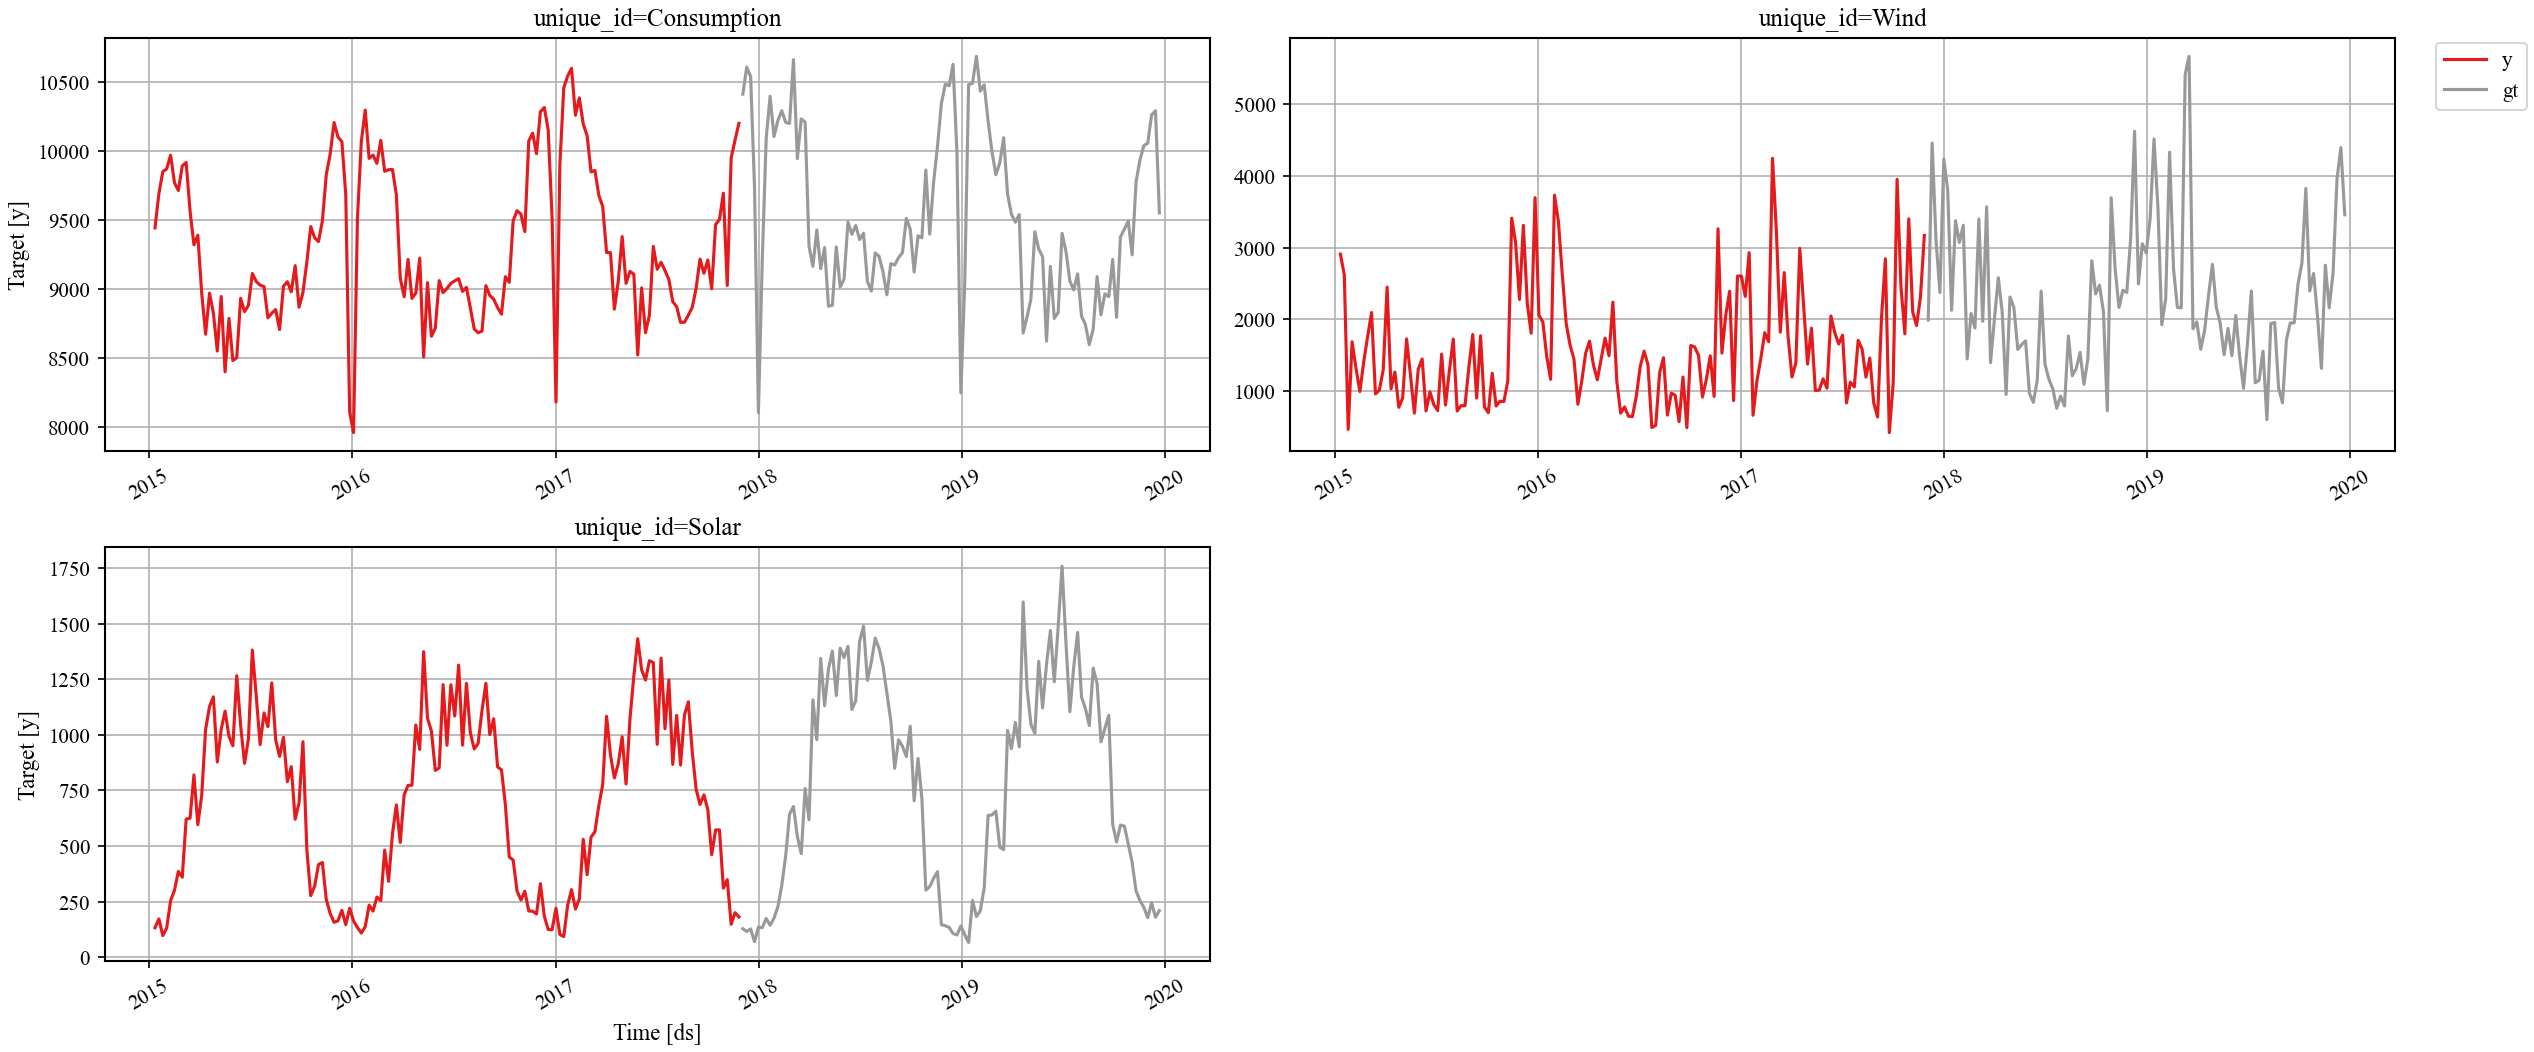

In [7]:
df= pd.read_csv(
    "OPDS_DE_EDA.csv",
    parse_dates=["time"],
    index_col="time"
)
df.head(1)
ts = ['Consumption','Wind',	'Solar']
exog_cols = ['temperature','radiation_direct_horizontal']
y = df.resample('W').agg({
    'Consumption': 'sum',
    'Wind': 'sum',
    'Solar': 'sum',
    'temperature': 'mean',
    'radiation_direct_horizontal': 'mean'
}).ffill().bfill() + 1e-8

y = y.iloc[1:-2]



ts = ['Consumption', 'Wind', 'Solar']
base_cols = ['unique_id', 'ds', 'y']

date_index = y.index
panel_list = [pd.DataFrame({'ds':date_index , 'y': y[t].values, 'unique_id': t}) for t in ts]
panel_df = pd.concat(panel_list, ignore_index=True)
panel_df = panel_df[base_cols] #порядок колонок
panel_df.sample(5)

FREQ = y.index.freq


SEASON = 52

FH = int(0.42 * y.shape[0])

df_test  = panel_df[base_cols].groupby("unique_id").tail(FH)
df_train = panel_df[base_cols].drop(df_test.index).reset_index(drop=True)

plot_series(df_train, df_test.rename(columns={"y": "gt"}),  palette='Set1')

In [8]:
metric_map = {
    'mase': partial(mase, seasonality=SEASON),
    'rmse': rmse,
    'smape': smape
}
metrics = list(metric_map.values())
metric_names = list(metric_map.keys())

## Диагностика моделей временных рядов

### Методы диагностики моделей.
<!-- 1. Анализ метрик и сложности моделей
2. Анализ остатков моделей
3. Бектестинг и кросс-валидация моделей
4. Оценка интервального прогнозирования (разброс предсказания)
5. Анализ доверительности модели (надежность, устойчивость, интерпретируемость, конкретные ошибки и тд). -->


Существует как минимум четыре [источника неопределенности](https://nixtlaverse.nixtla.io/mlforecast/docs/tutorials/prediction_intervals_in_forecasting_models.html#importance-of-confidence-interval-prediction-in-time-series) при прогнозировании с помощью моделей временных рядов:
* Случайная составляющая ошибки (флуктуации);
* Ошибка оценки параметров (смещение);
* Ошибка связанная с выбором параметров модели на исторических данных (обобщающая способность, переобучение);
* Ошибка связанная с продолжением процесса генерирования исторических данных в будущем (воспроизводимость паттерном поведения ВР, дрифт данных).

<!-- - __Случайная составляющая ошибки (флуктуации)__ — это неустранимый шум, присущий самой природе данных. Даже при идеально подобранной модели будущие наблюдения будут отклоняться от прогноза из-за непредсказуемых внешних воздействий или внутренней стохастичности процесса.
- __Ошибка оценки параметров (смещение)__ — возникает потому, что параметры модели (например, коэффициенты регрессии или веса в дереве решений) оцениваются на конечной выборке. Эти оценки подвержены выборочной изменчивости: при другом наборе исторических данных они были бы иными, что привело бы к иному прогнозу.
- __Ошибка, связанная с выбором модели на исторических данных__ — отражает неопределённость в архитектуре или гиперпараметрах модели. Мы выбираем одну модель из множества возможных (ARIMA, XGBoost, Prophet и т.д.), но не знаем, действительно ли она наилучшим образом описывает истинный процесс. Эта неопределённость включает риски переобучения, недообучения и ограниченную обобщающую способность.
- __Ошибка, связанная с продолжением процесса генерирования данных в будущем (дрифт данных)__ — предполагает, что закономерности, наблюдаемые в прошлом, сохранятся в будущем. Однако в реальности могут произойти структурные изменения: смена режима работы системы, внешние шоки (экономические, климатические, технологические), изменение поведения пользователей. В таких случаях даже идеальная модель на исторических данных даёт смещённый прогноз. -->



При анализе моделей часто используются следующие практики:

- __Анализ метрик и сложности моделей__ <br>
Оценка качества прогноза с помощью количественных метрик (MAE, RMSE, MAPE) на тестовой выборке, а также учёт сложности модели через информационные критерии (AIC, BIC). Это позволяет найти баланс между точностью и переобучением.
- __Анализ остатков моделей__ <br>
Проверка свойств in-sample остатков: отсутствие автокорреляции (тест Льюнга–Бокса), стационарность, приближённая нормальность и отсутствие систематических паттернов. Хорошая модель должна оставлять «белый шум».
- __Бектестинг и кросс-валидация моделей__ <br>
Моделирование реальных условий прогнозирования с помощью пошагового сдвига окна обучения (rolling-origin evaluation). Позволяет оценить устойчивость модели во времени и избежать оптимизма, связанного с однократным разбиением на train/test.
- __Оценка интервального прогнозирования (разброс предсказания)__ <br>
Анализ прогнозных интервалов: проверка покрытия (coverage — доля истинных значений внутри интервала) и sharpness (средняя ширина интервала). Надёжная модель даёт узкие интервалы с заданным уровнем покрытия (например, 90%).
- __Анализ доверительности модели__ <br>
Комплексная оценка надёжности: устойчивость коэффициентов при изменении данных, интерпретируемость результатов (соответствие предметной области), анализ типичных ошибок (например, занижение пиков или реакция на экстремальные события). Это помогает понять, можно ли доверять модели в реальных условиях.

### Оценка остатков модели.

#### Визуализация остатков 

Важным аспектом анализа любых моделей (в том числе и ARIMA и ETS, Prophet  и других) является [анализ остатков предсказания моделей](https://otexts.com/fpppy/nbs/05-toolbox.html#sec-diagnostics) (т.н. невязок или innovations - “innovation residuals”). Которые могут быть вычеслены как:
$$ e = y_t - \hat y_t$$


<blockquote>
    
- Остатки (__residuals__) — это общее понятие - разница между реальными наблюдениями и тем, что предсказала модель на обучающих данных.
- Инновации/невязка (__innovations__) — это то же самое, что остатки, но в контексте временных рядов: они показывают «новую информацию», которую модель не смогла предсказать на каждом шаге времени.
  
</blockquote>


В случае идеального прогноза остатки модели должны представлять собой белый шум. Это значит что такие остатки не объяснимы. 

Расмотрим пример простого алгоритма и его остатков.

In [9]:
mean_method = [SeasonalExponentialSmoothingOptimized(SEASON),
               HoltWinters(season_length=SEASON, error_type="A", alias="HW_Add"),  ]

In [10]:
sf = StatsForecast(models=mean_method, freq=FREQ)
sf.forecast(h=FH, df=df_train, fitted=True)
fitted_values = sf.forecast_fitted_values()

model_names = [getattr(model, 'alias', type(model).__name__) for model in sf.models]
for col in model_names:
    fitted_values[f"resid_{col}"] = fitted_values["y"] - fitted_values[col].values

# fitted_values['unique_id'] = fitted_values.index
# fitted_values = fitted_values.reset_index(drop=True)

In [11]:
fitted_values

,unique_id,ds,y,SeasESOpt,HW_Add,resid_SeasESOpt,resid_HW_Add
0,Consumption,2015-01-11,9440.105,NaN,9417.628555,NaN,22.476445
1,Consumption,2015-01-18,9689.010,NaN,9742.056785,NaN,-53.046785
2,Consumption,2015-01-25,9847.035,NaN,9932.161180,NaN,-85.126180
3,Consumption,2015-02-01,9867.317,NaN,9932.620053,NaN,-65.303053
4,Consumption,2015-02-08,9966.415,NaN,9999.321875,NaN,-32.906875
...,...,...,...,...,...,...,...
448,Wind,2017-10-29,3400.181,1163.087,1154.043985,2237.094,2246.137015
449,Wind,2017-11-05,2105.870,1493.067,1471.662119,612.803,634.207881
450,Wind,2017-11-12,1914.513,926.767,2945.874899,987.746,-1031.361899
451,Wind,2017-11-19,2309.436,3261.415,3090.470827,-951.979,-781.034827


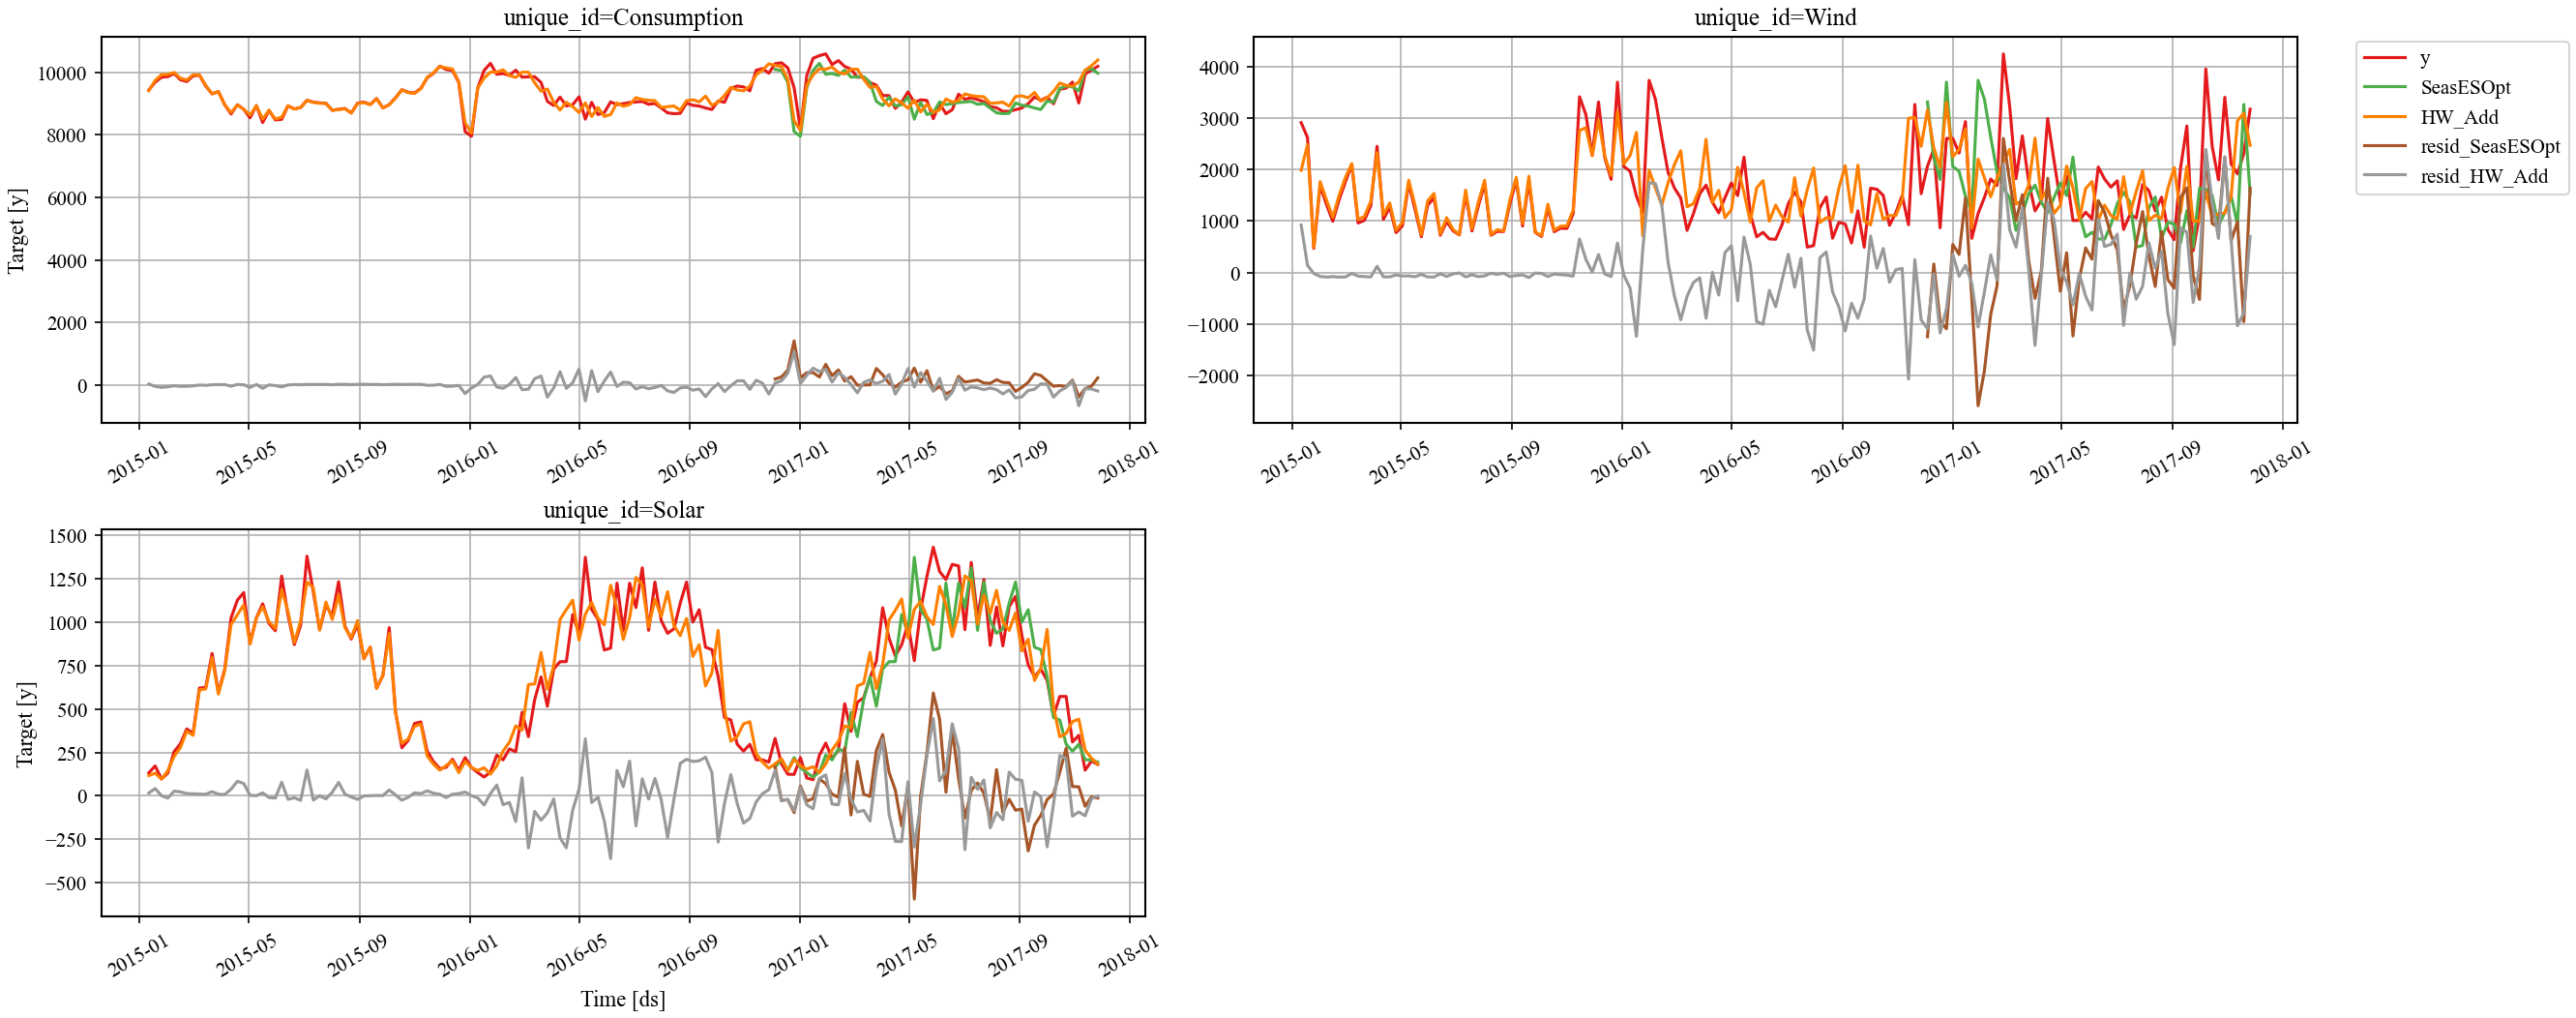

In [12]:
plot_series(df = df_train,forecasts_df = fitted_values.drop(columns = 'y'), palette='Set1')

Видно, что каждой модели остаток значительно отличается от белого шума. Это означает, что остаток информативен (содержит информацию, не описанную моделью).


#### Диагностика остатков

На самом деле диагонстика остатков часто строится [по известному алгоритму](https://otexts.com/fpppy/nbs/05-toolbox.html#example-forecasting-google-daily-closing-stock-prices).

Для каждого ВР построим
1. __Остатки во времени__ (график в левом верхнем углу).
   - График показывает наличие тренда и сезонности в остатках, а также гетеросекдостичность разброса (шумов).
   - В название также показен результат теста __KPSS__, показывающий нестационарность данных по отклонениям от уровня (если p-value > 0.05 - гипотеза о стационарности).
2. __ACF__ (автокорреляционная функция) — график в правом верхнем углу.
   - Тут проверяется соотвествие остатков белому шуму и стационарность остатков. В иделае ACF должна иметь только нулевой лаг выше доверительного интервала.
   - В название графика  ACF также указается значение __теста  Льюнга–Бокса__. Если p-value теста Льюнга–Бокса > 0.05 (указано в заголовке) → автокорреляции нет (белый шум).
3. __Гистограмма остатков__ — график в левом нижнем углу.
   - Тут рассматривается на сколько гистограмма похоже на нормальное распределение, есть ли выбросы и тд.
   - Если есть сильный перекос → модель систематически завышает или занижает.
   - Если есть тяжелые хвосты - много выбросов.
   - Если распределение сильно отличается от нормального - модель неадекватна.
   - В заголовке указано значение Breusch–Pagan теста p-value.
   - Если BP p-value< 0.05 Отвергаем H₀ → гетероскедастичность присутствует.
4. __Q-Q plot__ (квантиль-квантильный график) — график в правом нижнем углу
   - График показывает сравнение модели и нормального распределения. Известны Q-Q plot для некоторых типичных видов распределний.
   - Например, точки изгибаются вверх/вниз → тяжёлые хвосты или перекос.
   - В название указано  p-value теста Jarque–Bera. Если p-value > 0.05 нормальность не отвергается (p-value < 0.05 → остатки не нормальны).

__Примеры выводов__:
- Если все 4 графика «хорошие» - модель адекватна, остатки похожи на белый шум.
- Если ACF чистый, но остальное плохо - модель динамику ловит, но, например, плохо калибрована.
- Если ACF плохой - модель недообучена — нужно улучшать спецификацию (больше лагов, сезонность и т.д.).


In [13]:
def plot_model_diagnostics(df_resid, resid_col="resid", title_suffix=""):
    uid = df_resid['unique_id'].iloc[0]
    resid = df_resid[resid_col].fillna(0)
    # if len(resid) < 10:
    #     print(f"Пропущено: {uid} — недостаточно данных")
    #     return
    
    T = len(resid)
    lags = min(2 * SEASON, T // 5) if SEASON and SEASON > 1 else min(10, T // 5)
    lags = max(lags, 1)
    
    # Тесты
    lb_pval = acorr_ljungbox(resid, lags=lags, return_df=True)['lb_pvalue'].iloc[-1]
    jb_stat, jb_pval = stats.jarque_bera(resid)
    exog = sm.add_constant(range(len(resid)))
    _, bp_pval, _, _ = het_breuschpagan(resid, exog)
    
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        try:
            kpss_stat, kpss_pval, _, _ = kpss(resid, regression='c', nlags='auto')
        except Exception:
            kpss_pval = np.nan

    fig, axes = plt.subplots(2, 2, figsize=(9, 6))
    fig.suptitle(f'Диагностика остатков: {uid} {title_suffix}', fontsize=12)

    # [0,0] — Остатки + KPSS
    kpss_txt = f"Residuals (KPSS p={kpss_pval:.3f})" if not np.isnan(kpss_pval) else "Residuals"
    axes[0, 0].plot(df_resid['ds'], df_resid[resid_col], linewidth=0.8)
    axes[0, 0].set_title(kpss_txt)
    axes[0, 0].set_ylabel('Остатки')
    axes[0, 0].grid(True, linestyle='--', alpha=0.5)

    # [0,1] — ACF + Ljung-Box
    plot_acf(resid, ax=axes[0, 1], zero=False, auto_ylims=True)
    axes[0, 1].set_title(f'ACF (Ljung-Box p={lb_pval:.3f})')

    # [1,0] — Гистограмма + Breusch-Pagan
    axes[1, 0].hist(resid, bins=15, edgecolor='k', alpha=0.7)
    axes[1, 0].set_xlabel('Остатки')
    axes[1, 0].set_ylabel('Частота')
    axes[1, 0].set_title(f"Histogram (BP p={bp_pval:.3f})")

    # [1,1] — Q-Q + Jarque-Bera
    stats.probplot(resid, dist="norm", plot=axes[1, 1])
    axes[1, 1].set_title(f'Q-Q (JB p={jb_pval:.3f})')

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

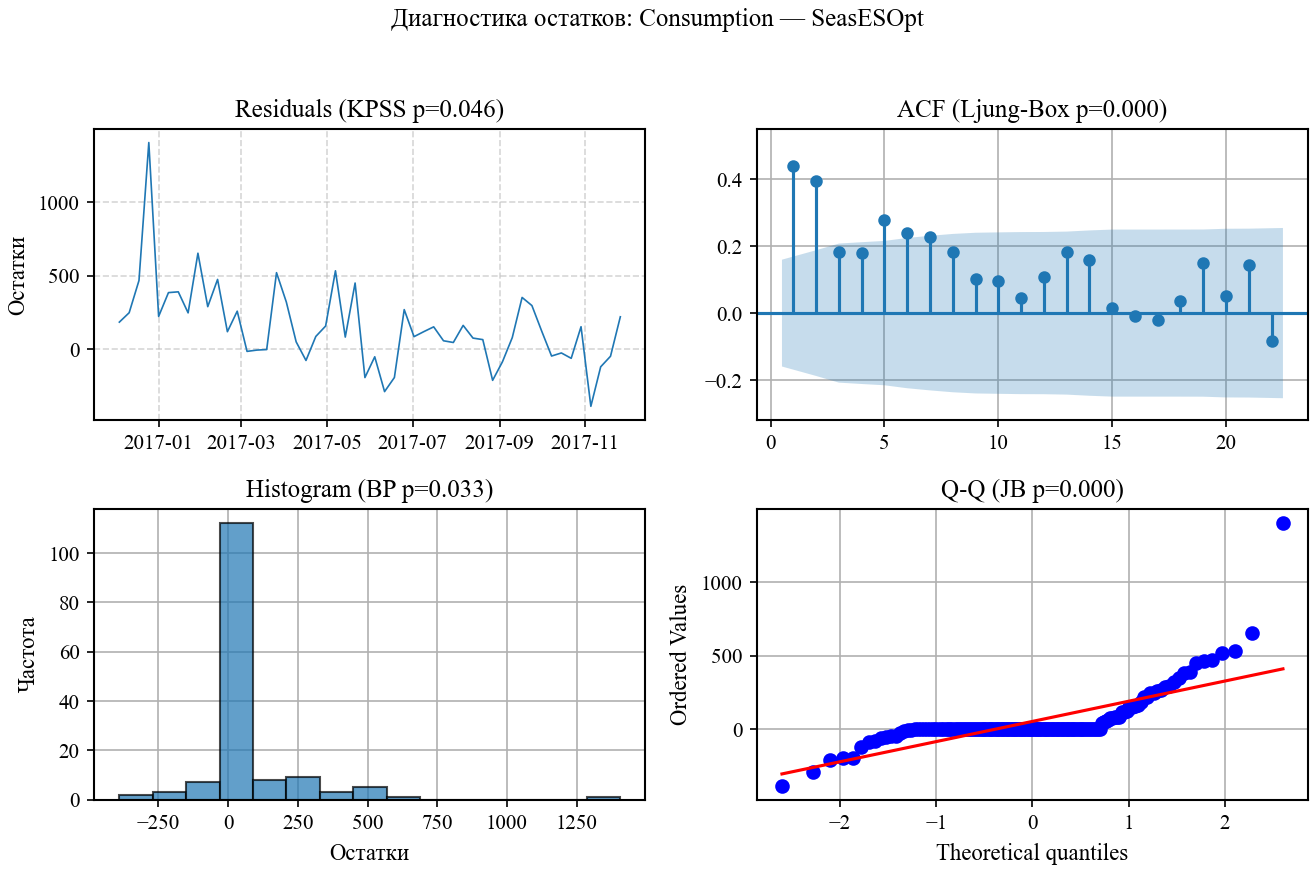

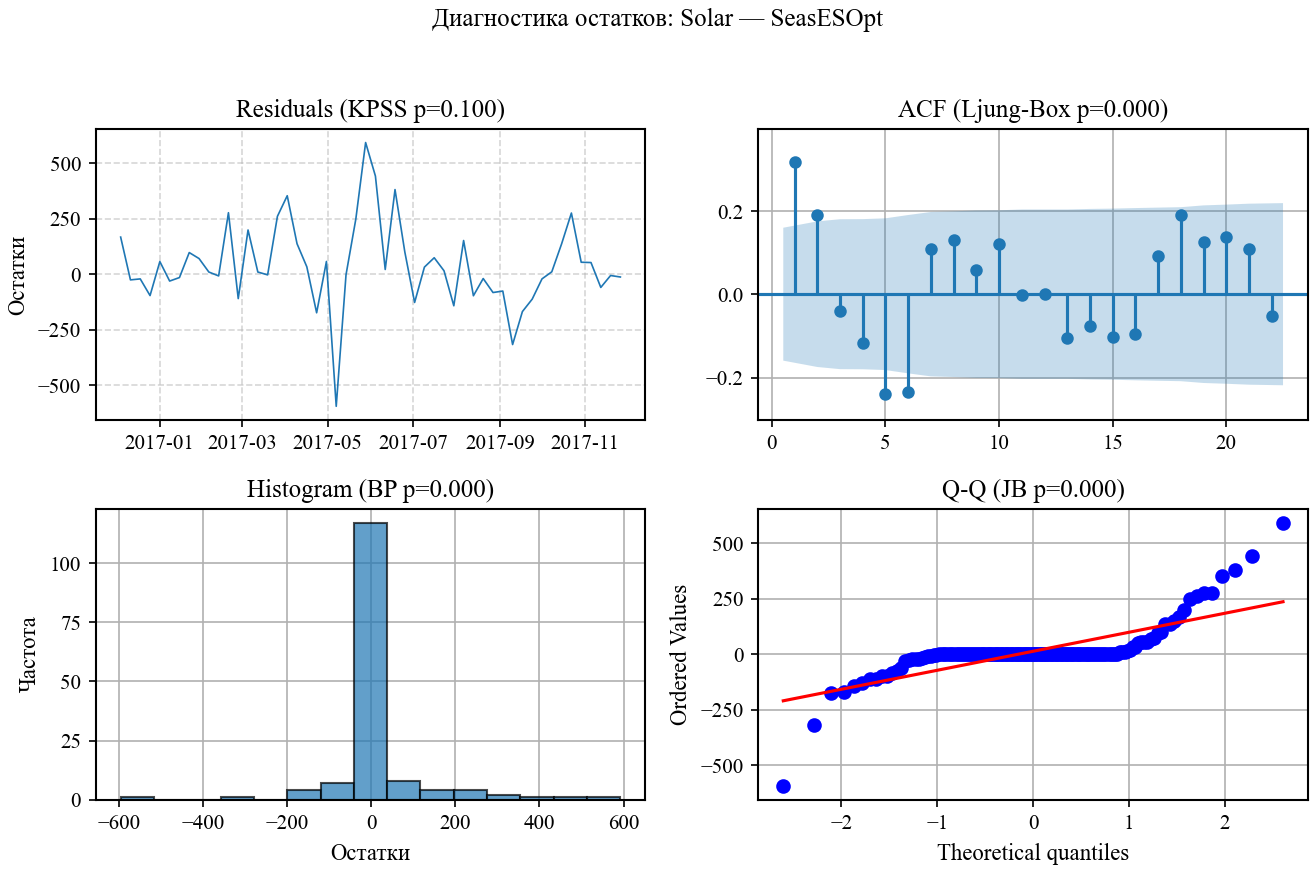

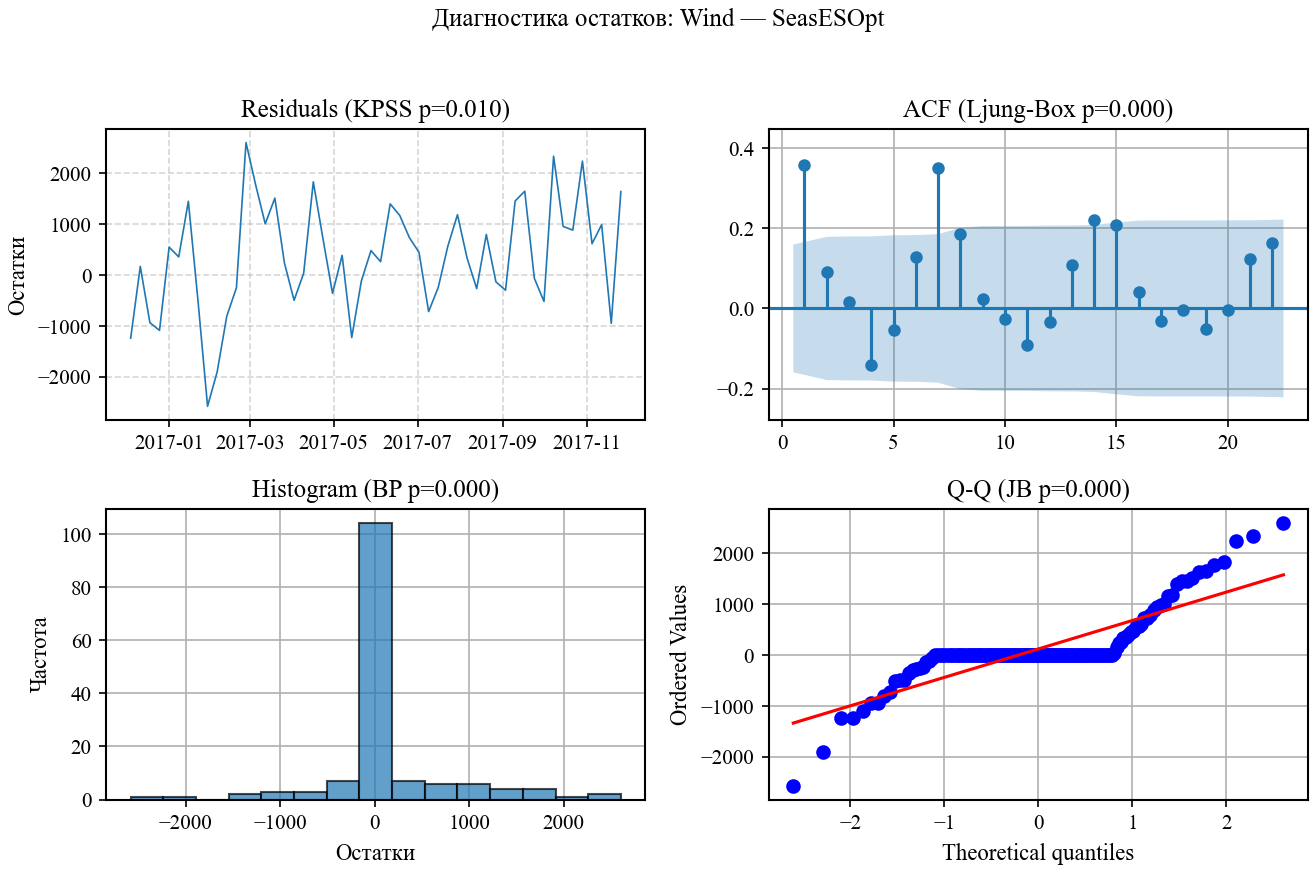

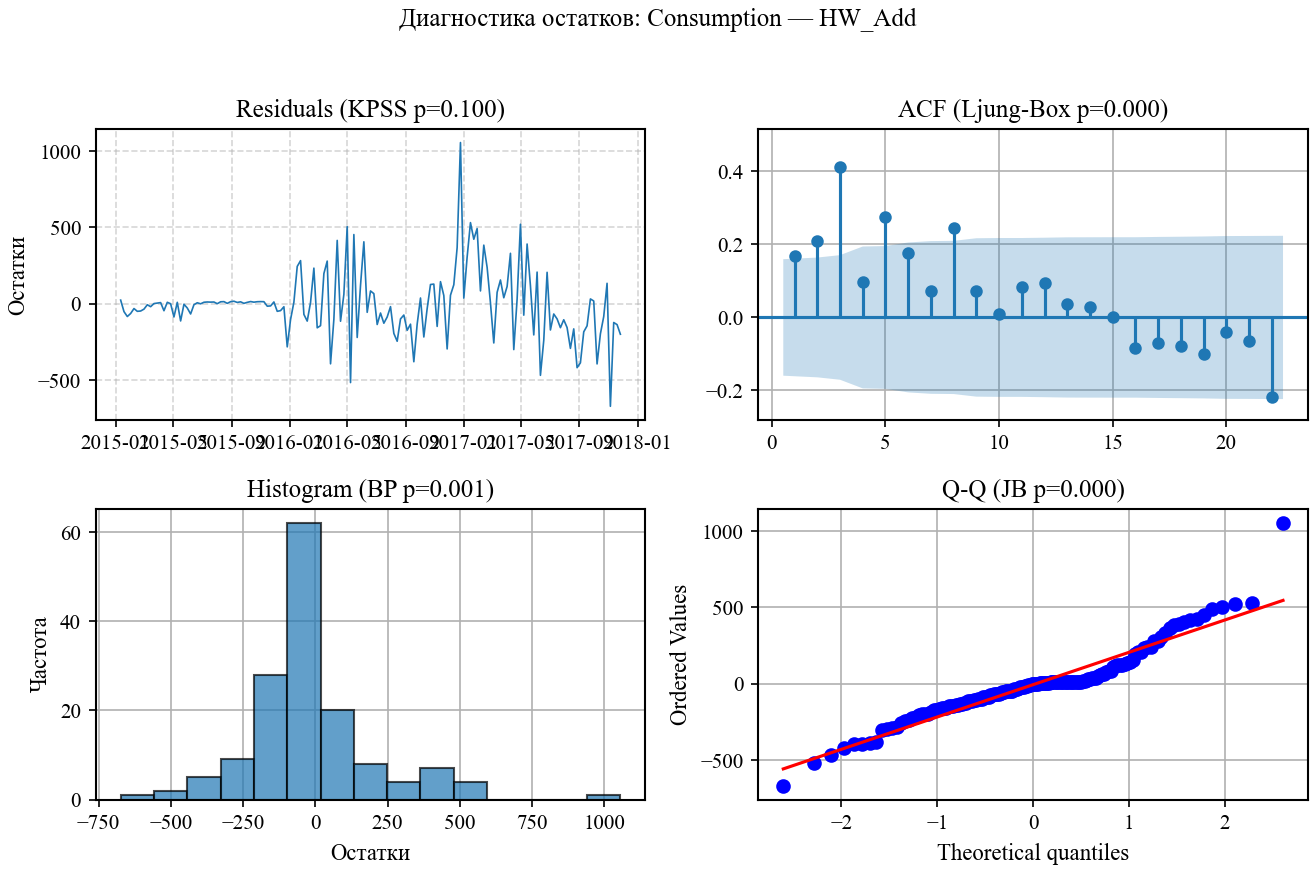

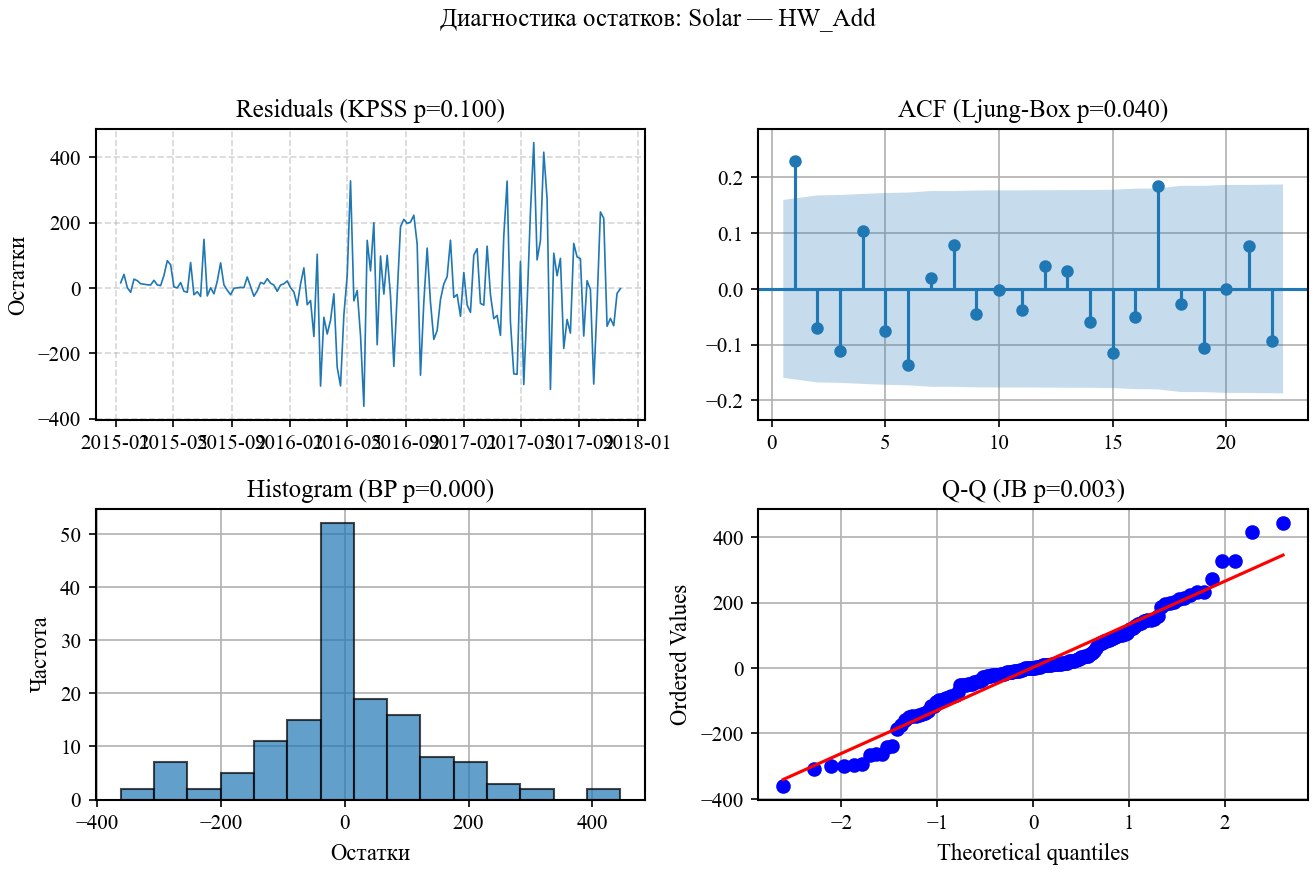

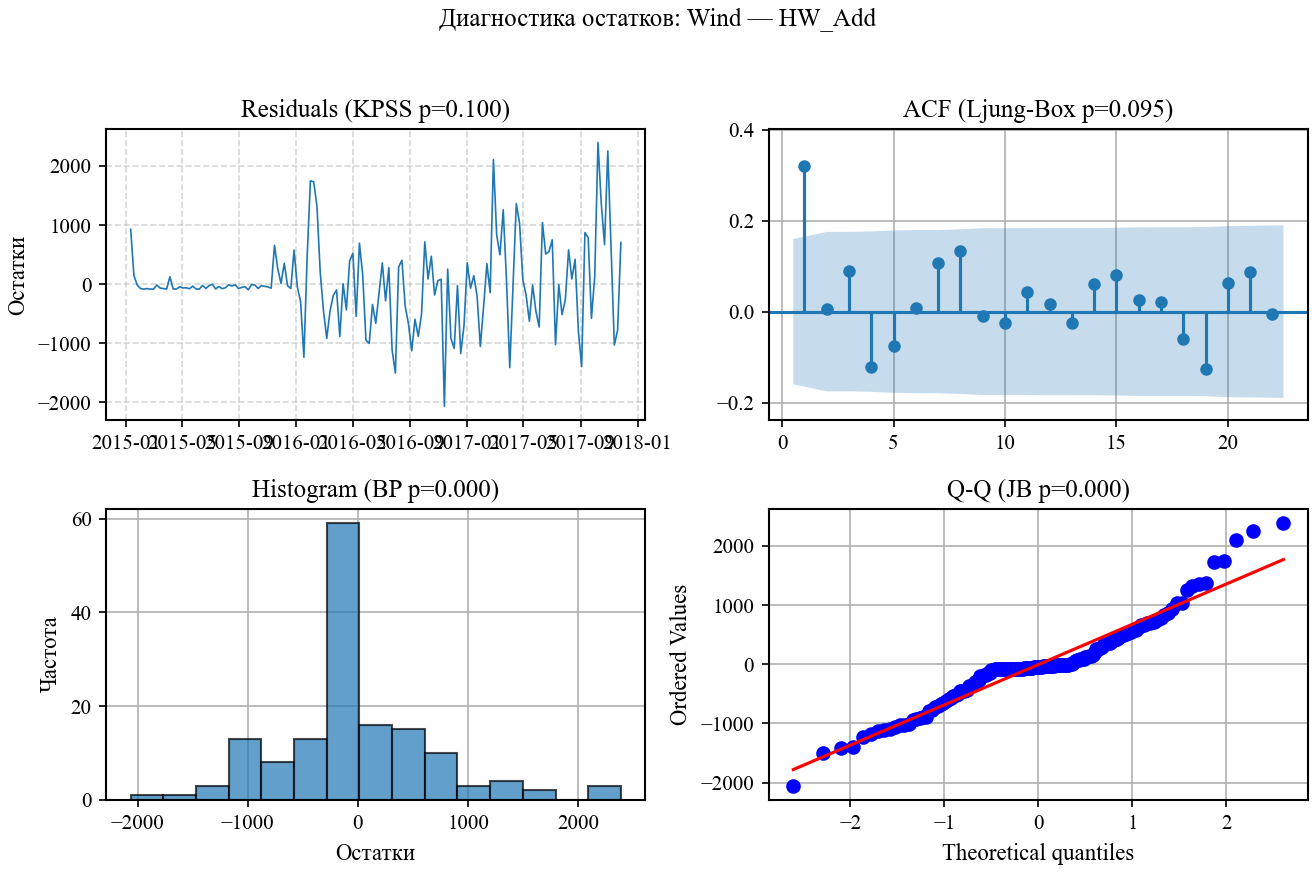

In [14]:
resid_cols = [col for col in fitted_values.columns if col.startswith('resid_')]
for resid_col in resid_cols:
    for uid in  fitted_values['unique_id'].unique():
        subset = fitted_values[(fitted_values['unique_id'] == uid)]
        plot_model_diagnostics(subset, resid_col=resid_col, title_suffix=f"— {resid_col[6:]}")

#### Упражнение
1. Провести оценку для базовых моделей ARIMA, Prophet, ETS, сравните модели и выберите лучшую 

## Вали модели


### Walk-forward validation

#### ExpandingWindowSplitter

Ранее валидация моделей проводилась путем одноразового деления ВР на последовательные участки тренировки и валидации. Однако в силу присущей ВР нестационарности поведения такой подходя может привести к слишьком не точным (как правило слишьком оптимистичным) результатам. 
Самый простой способ  повышения надежности  валидации моделей ВР - мы можем  разделить  набор данных несколько раз по аналогии с методом `k-folds`. Однако, в соответствии с особенностями временных рядов - временной связанностью метод`k-folds` должен [не нарушать принцип казуальности](https://forecastegy.com/posts/time-series-cross-validation-python/). Другими словами [выборка валидации должна следовать за тренировочными данными](https://otexts.com/fpp3/tscv.html). __Такой подход также известен как [<tt>backtesting/ walk-forward validation</tt>](https://joaquinamatrodrigo.github.io/skforecast/0.8.1/user_guides/backtesting.html)__.

>Напомним, результат [кросс-валидации](https://www.statology.org/k-fold-cross-validation/) по нескольким блокам более валиден [(менее смещен)](https://machinelearningmastery.com/k-fold-cross-validation/), нежели валидация одной [отложенной выборкой](https://scikit-learn.org/stable/modules/cross_validation.html).

>__Backtesting (ретроспективное тестирование)__ и __walk-forward validation  (пошаговая валидация)__ часто используются как синонимы, но в строгом смысле они отражают разные варианты  одного и того же принципа.
>
>__Walk-forward validation__ -  процедура при которой: начальное обучающее окно фиксируется (например, первые 365 дней),
модель тестируется на следующем коротком интервале (например, 7 дней), затем обучающее окно расширяется (или сдвигается), включая данные, использованные для теста, процесс повторяется до конца выборки.
>
>__Backtesting__ не имеет конкретного алгоритма , но часто преполагает проверку точности модели на последовательности интервалов без дообучения - то есть имитация работы модели в реальной среде. Ближе всего к этому определению подходит стратегия, когда окон тренировки выбирается один раз,а тест осуществляется на наборе последовательных окон.

В случае временного ряда кросс валидация может быть выполнена в скользящем окне по данным  [<tt>rolling backtest evaluation</tt>](https://docs.aws.amazon.com/whitepapers/latest/time-series-forecasting-principles-with-amazon-forecast/step-4-evaluate-predictors.html#prediction-quantiles-and-accuracy-metrics).
> [Приемущественно метода](https://mydata.ch/backtesting-in-time-series-forecasting-for-maximum-performance/)  бектеста скользящим окном следующие:
>* позволяет  быть уверенным, что  прогнозы точны и последовательны в течение длительного периода времени.
>* может помочь  найти и исправить "плавоющие" ошибки в модели данных. То есть редкие, но достаточно регулярные ошибки (неучтенную информоацию), которые можно участь в модели.
>* может помочь выявить недостающие внешние факторы в данных, которые помогут модели делать более точные прогнозы.
<!-- ✅It allows you to ensure that your forecasts are accurate and consistent over a long period of time

✅It can help you to find and correct errors in your models.

✅It can help you to identify missing external factors in your data that would help the model make better forecasts -->

>Напомним, что в прогнозировании временных рядов под <tt>бэктестингом</tt> понимается процесс проверки модели прогноза на исторических данных. Этот метод предполагает пошаговое движение назад во времени, чтобы оценить, насколько хорошо показала бы себя модель, если бы она использовалась для прогнозирования в этот период времени.

С технической точки зрения идея тут [заключается следующем](https://joaquinamatrodrigo.github.io/skforecast/0.11.0/user_guides/backtesting.html). Задается некторая ширина окна временного ряда. Заданное окно скользит по временному ряду с начального положения, например, таким образом, что все данные перед ним являются тренировочными, а после тестовыми. Могут быть и [другие стратегии](https://www.sktime.net/en/stable/examples/forecasting/window_splitters.html), например, что только лишь выборка заданного размера перед окном является тренировочной. Такие стратегии называются `ExpandingWindowSplitter` и `SlidingWindowSplitter` соответственно.

Для использования данных стратегий рекомендуем задавать оконо списком чисел вместо дат. Попробуем для начала визуализировать `ExpandingWindowSplitter`

> Отметим что по своей идеалогии данная процедура аналогична тому, что модель бы тестировалась на поступающих данных в соответствующих рабочих режмах. При этом целью такого тестирования бы была оценка работоспособности модели. Другими словами тестирование гипотезы о необходимости сменить модель (например переобучить). Такая процедура называется [<tt>walk-forward validation</tt>](https://machinelearningmastery.com/backtest-machine-learning-models-time-series-forecasting/).

<!-- In time series forecasting, backtesting refers to the process of validating a predictive model using historical data. The technique involves moving backwards in time, step-by-step, to assess how well a model would have performed if it had been used to make predictions during that time period. -->

#### `cross_validation` nixtla

Используем метод [`cross_validation`](https://nixtlaverse.nixtla.io/mlforecast/docs/how-to-guides/cross_validation.html) для обучения и оценки моделей. В данном случае это будет аналог `ExtendedWindowCV` рассмотренного ранее. Здадим следующие парамерты:
* `df`: Получает обучающие данные 
* `h`: Горизонт прогнозирования 
* `n_windows`: Количество слайдов, которые мы хотим спрогнозировать.
* `step_size`: шаг между окнами
* `refit=True`: Для каждого окна прогноз будет обновлен заново.

<!-- Также можно задать имена столбцов временного ряда: 
+ `id_col`:Столбец, идентифицирующий каждый ВР (по умолчанию уникальный_ид) 
+ `time_col`: Столбец, идентифицирующий каждый временной шаг, его значения могут быть временными метками или целыми числами (По умолчанию `ds`) 
+ `target_col`:Столбец, содержащий целевой ВР (По умолчанию `y`) -->

Отметим что в полеченных результатах будут показаны:
* `cutoff`: последняя временная метка для каждого из `n_windows`.
* `models`: набор столбцов для моделей

> Напомним, что `ExtendedWindowCV` может быть [отображен как](https://nixtlaverse.nixtla.io/mlforecast/docs/how-to-guides/cross_validation.html):
<img src="https://raw.githubusercontent.com/Nixtla/statsforecast/main/nbs/imgs/ChainedWindows.gif" width="500px">

In [15]:
models = [
    SeasonalExponentialSmoothingOptimized(SEASON),
    HoltWinters(season_length=SEASON, error_type="A", alias="HW_Add")
]
model_names = [getattr(m, 'alias', type(m).__name__) for m in models]

In [16]:
sf = StatsForecast(models=models, freq=FREQ) 

cv_df = sf.cross_validation(
    df=panel_df,
    h=FH//2,
    n_windows=4,
    step_size=FH//2, 
    # refit=True,
)

# cv_df['unique_id'] = cv_df.index
# cv_df = cv_df.reset_index(drop=True)

cv_df.head()

,unique_id,ds,cutoff,y,SeasESOpt,HW_Add
0,Consumption,2015-11-08,2015-11-01,9491.391,NaN,9421.084742
1,Consumption,2015-11-15,2015-11-01,9826.524,NaN,9459.113070
2,Consumption,2015-11-22,2015-11-01,9976.205,NaN,9489.535733
3,Consumption,2015-11-29,2015-11-01,10203.088,NaN,9513.873863
4,Consumption,2015-12-06,2015-11-01,10097.922,NaN,9533.344367


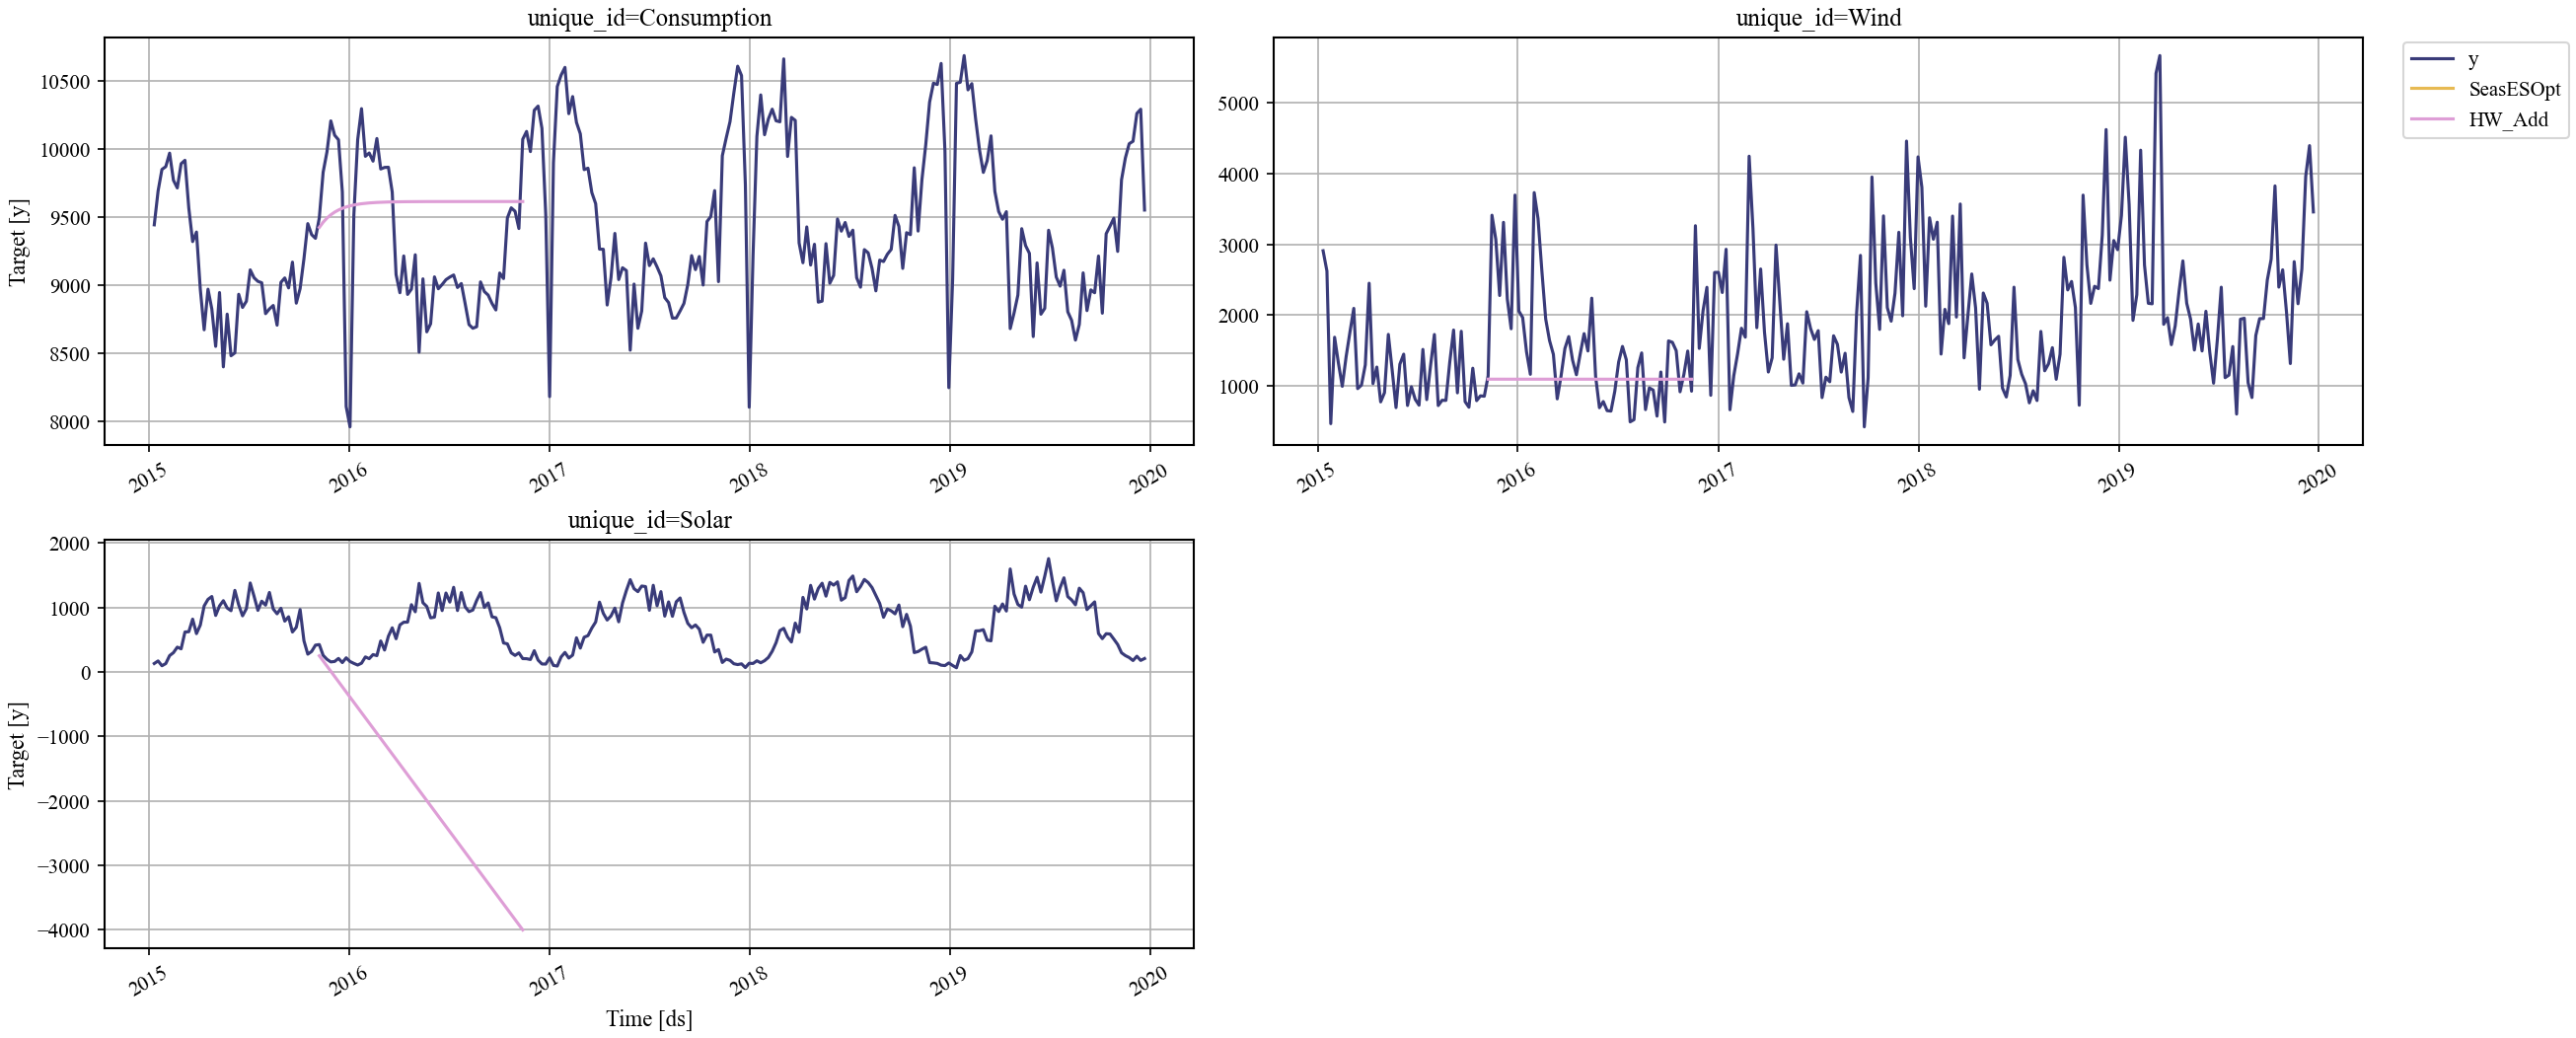

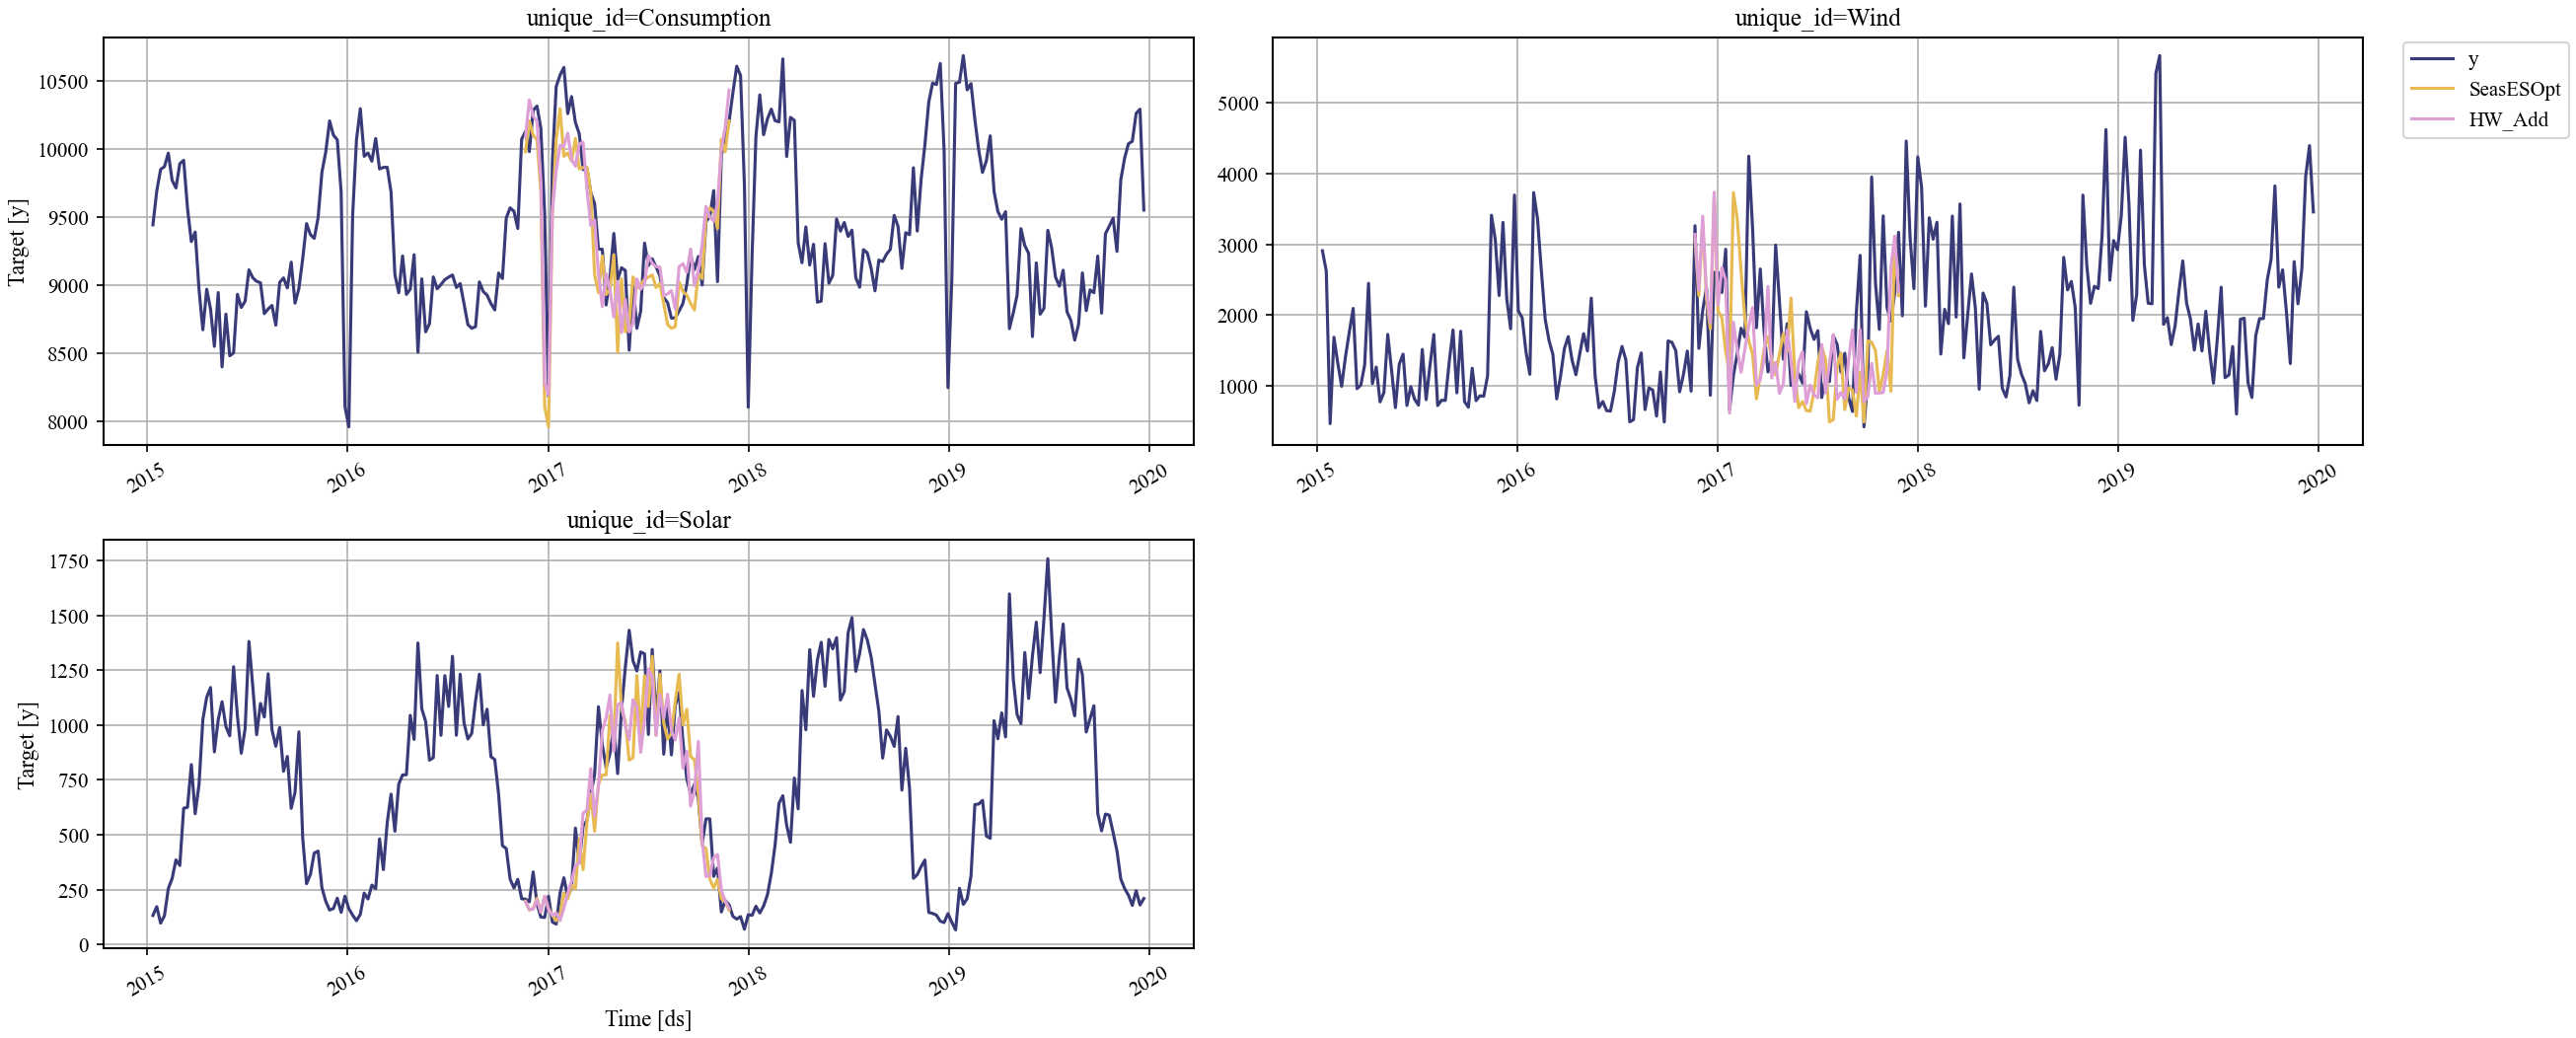

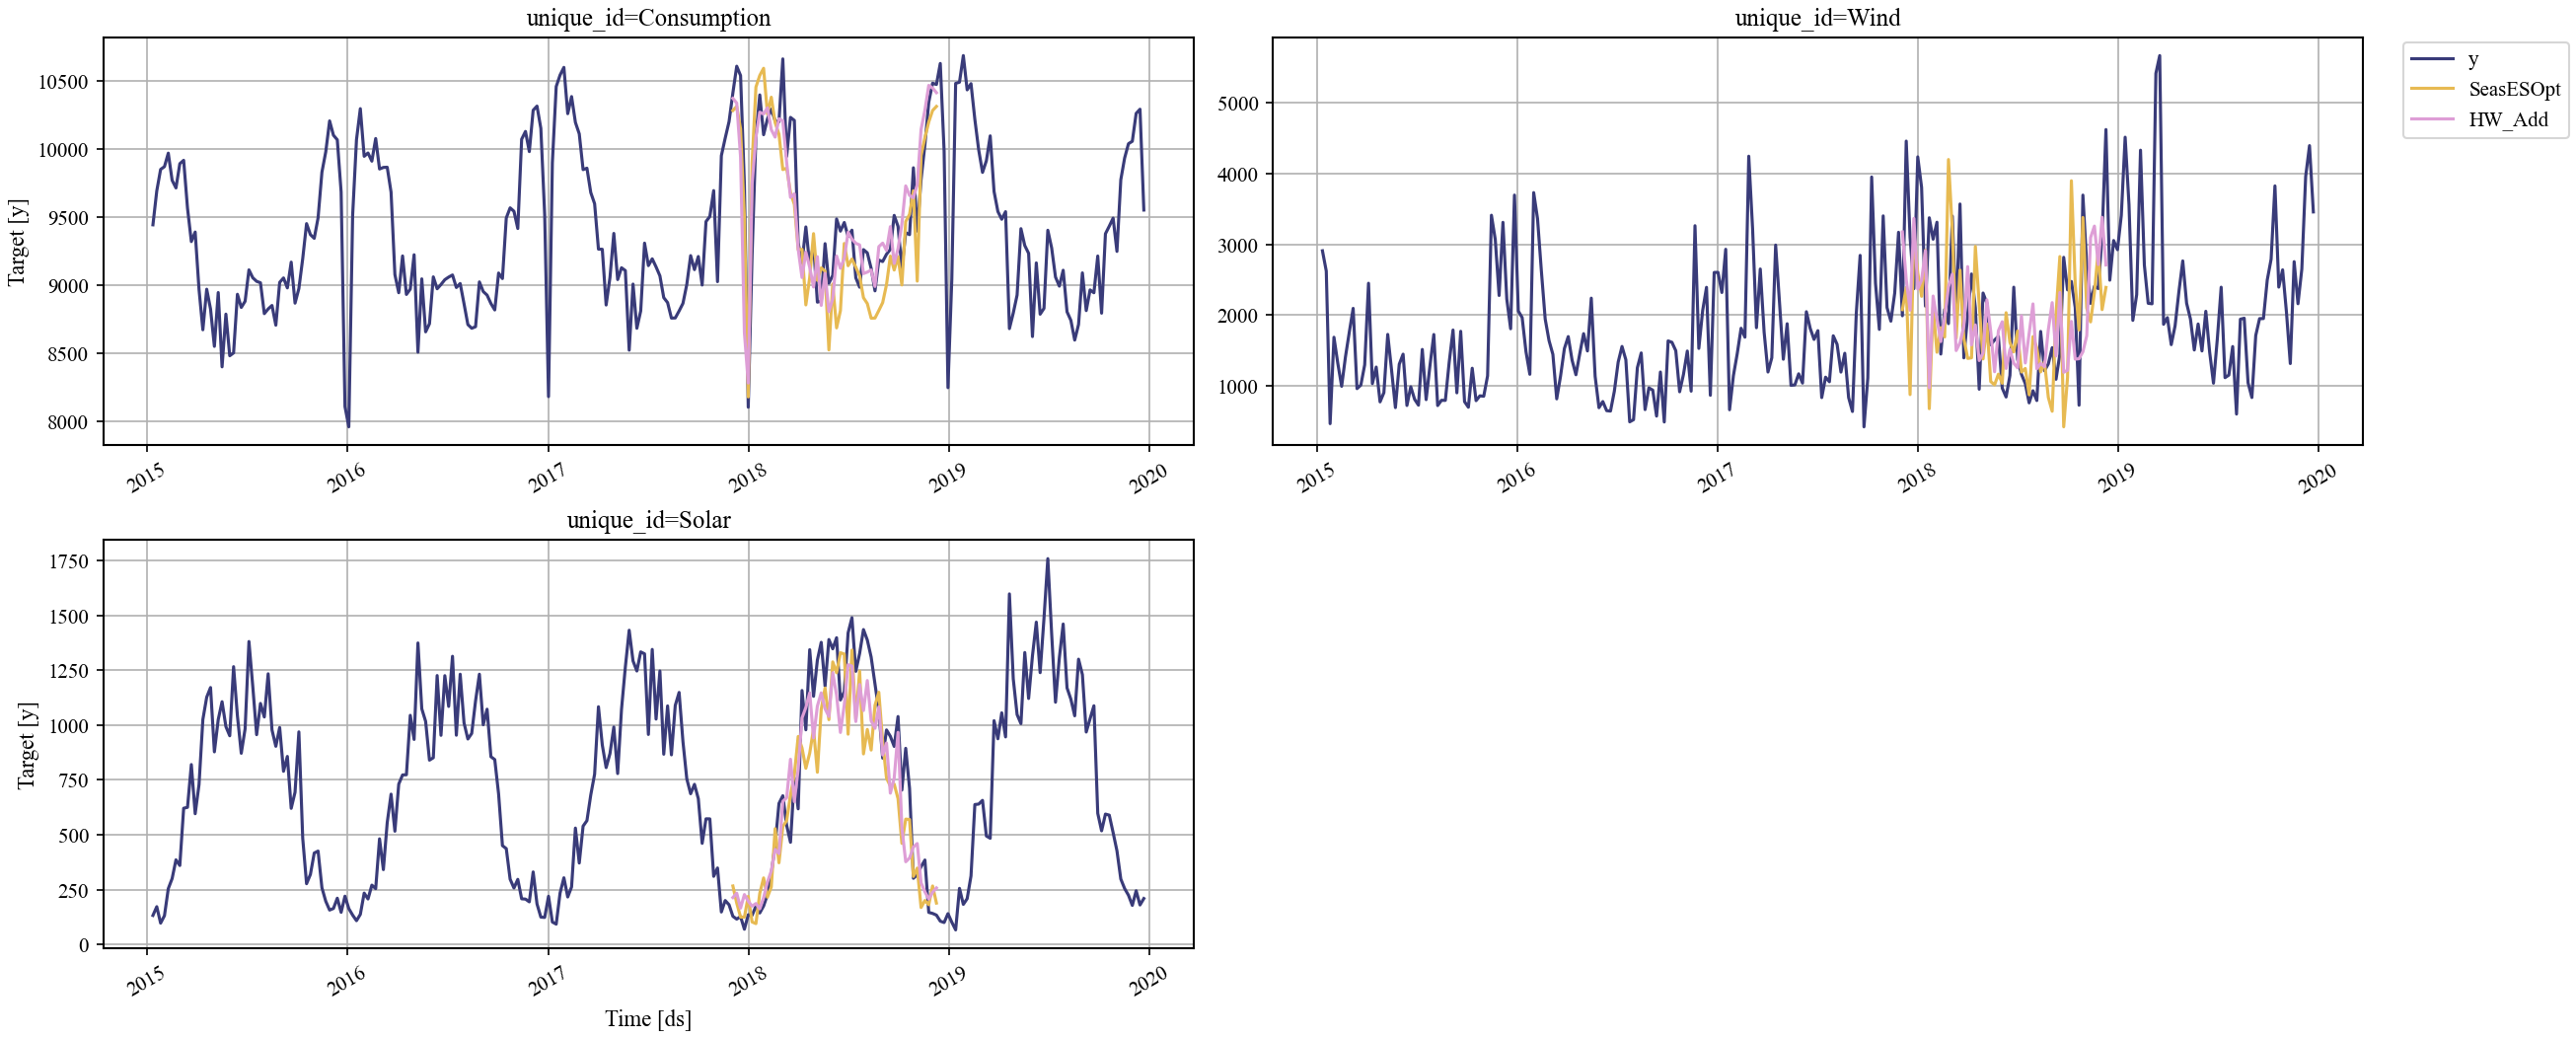

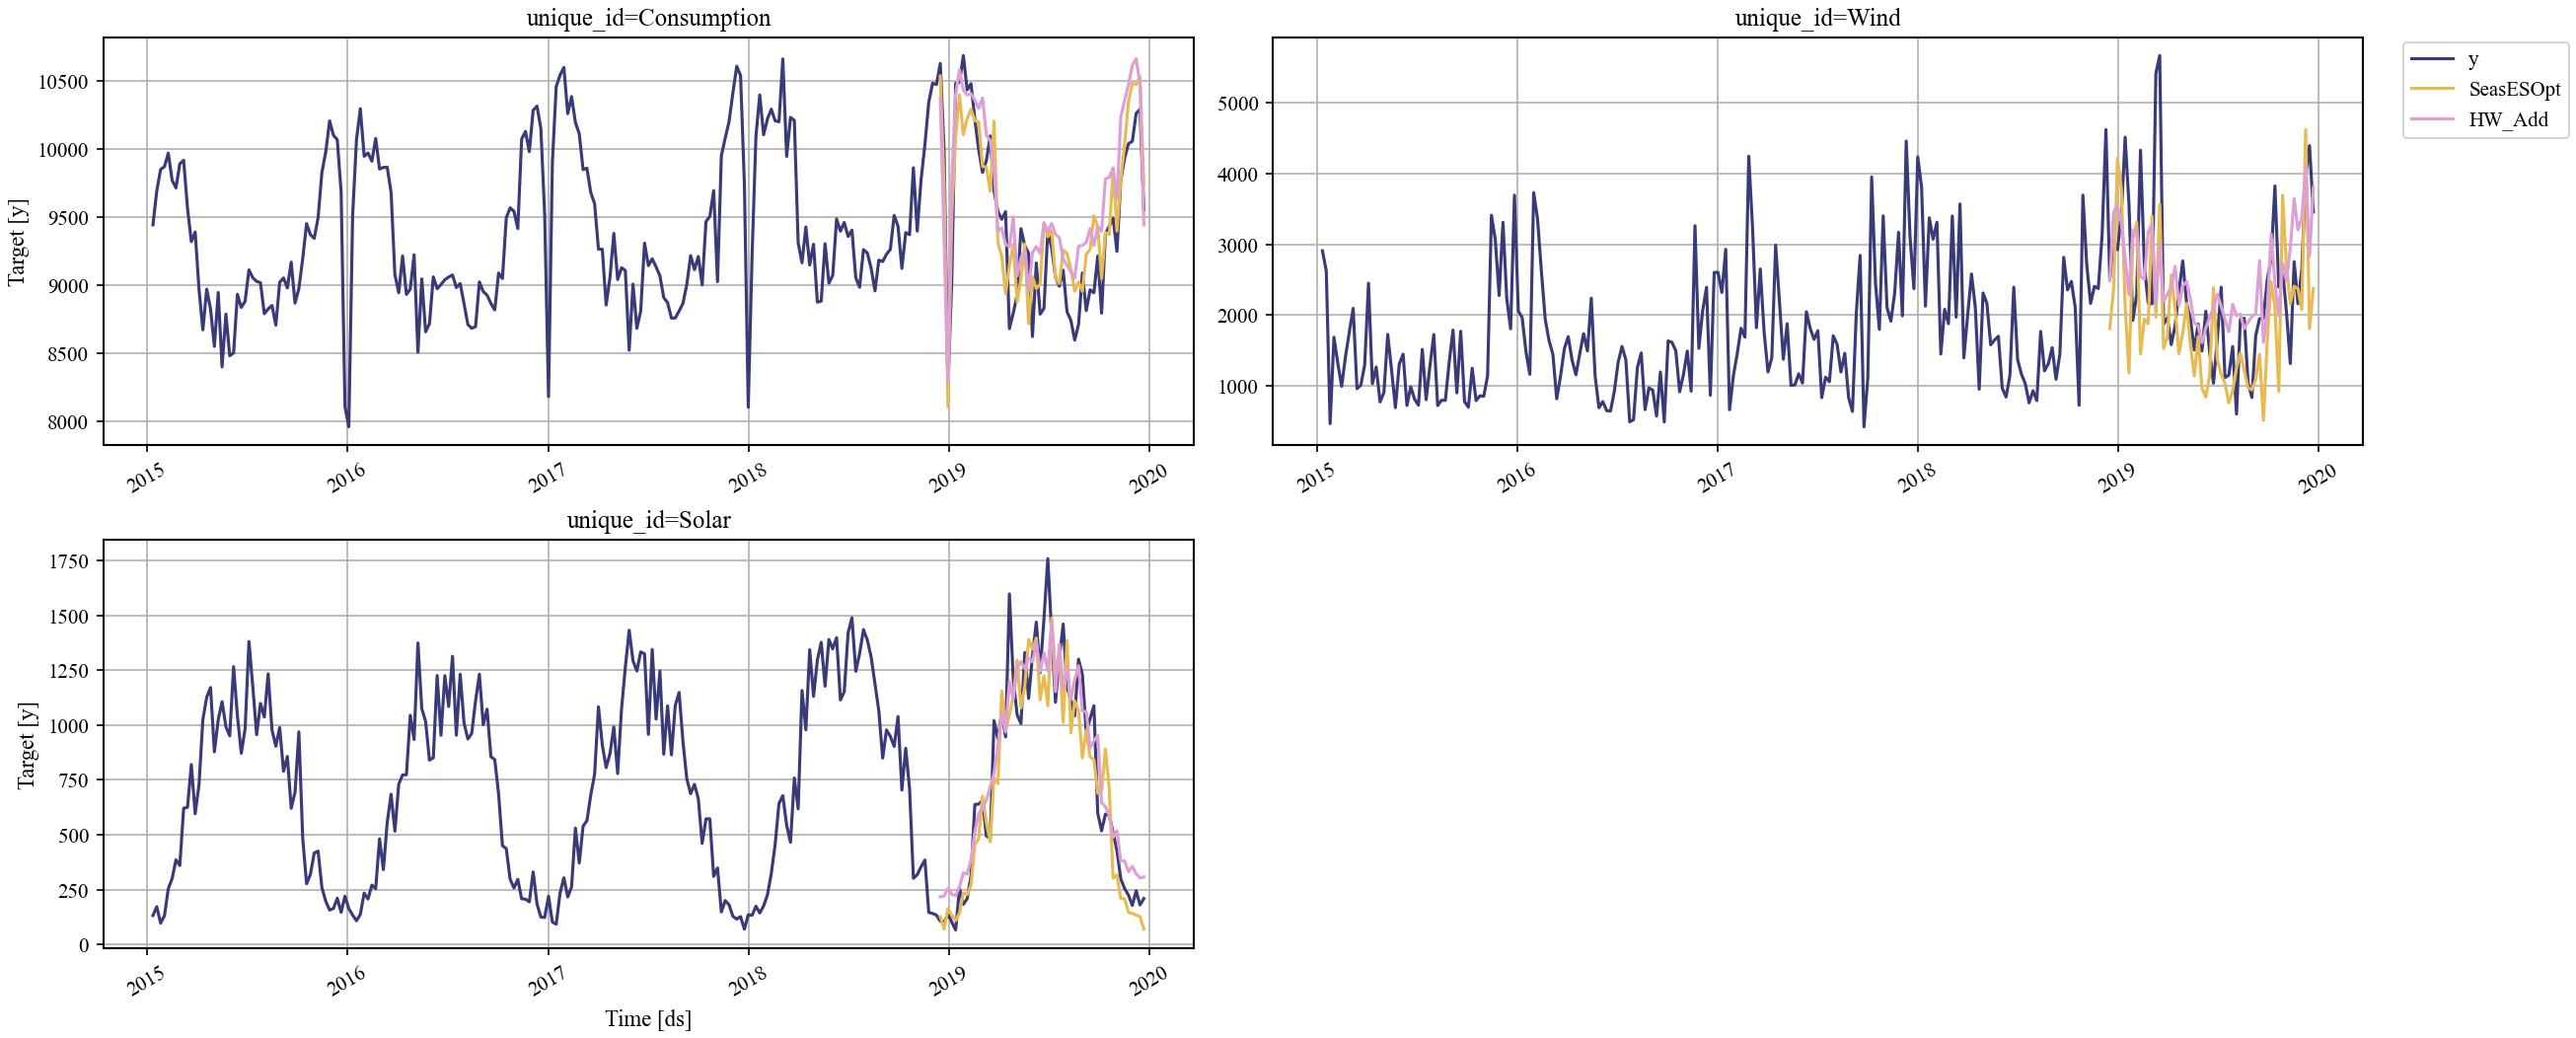

In [17]:
# cv_df.rename(columns = {'y' : 'actual'}, inplace = True) # rename actual values

cutoff = cv_df['cutoff'].unique()

for k in range(len(cutoff)):
    cv = cv_df[cv_df['cutoff'] == cutoff[k]]
    display(StatsForecast.plot(panel_df, cv.loc[:, cv.columns != 'cutoff'].drop(columns = 'y')))

Проведем оценку средей точности для обоих методов.

In [18]:
def evaluate_cv(crossvalidation_df, metrics, model_names, target_col='y',level=None):
    evaluations = []
    for c in crossvalidation_df['cutoff'].unique():
        df_cv = crossvalidation_df.query('cutoff == @c')
        evaluation = evaluate(
            df=df_cv,
            metrics=metrics,
    models=model_names,
        level=level,
            target_col=target_col
        )
        # УДАЛЯЕМ unique_id СРАЗУ — чтобы не мешался
        evaluation = evaluation.drop(columns=['unique_id'], errors='ignore')
        evaluations.append(evaluation)
    
    # Теперь все колонки — числовые
    evaluations = pd.concat(evaluations, ignore_index=True)
    evaluations = evaluations.groupby('metric').mean()
    return evaluations.style.background_gradient(cmap='RdYlGn_r', axis=1)

# 5. Запуск
result = evaluate_cv(
    crossvalidation_df=cv_df,
    metrics=[smape, mae, rmse],  # или любые другие из statsforecast.utils
    model_names=model_names
)

result

,SeasESOpt,HW_Add
metric,,
mae,424.178376,601.507337
rmse,546.015989,745.921824
smape,0.090337,0.181911


In [21]:
import seaborn as sns

In [28]:
evaluation_df = evaluate(cv_df.drop(columns='cutoff'), metrics=[mse, mae, smape])
by_metric = evaluation_df.groupby('metric').mean(numeric_only=True)

,unique_id,metric,model,error
0,Consumption,mse,SeasESOpt,1.001300e+05
1,Solar,mse,SeasESOpt,4.155694e+04
2,Wind,mse,SeasESOpt,1.252134e+06
3,Consumption,mae,SeasESOpt,2.437085e+02
4,Solar,mae,SeasESOpt,1.476436e+02
5,Wind,mae,SeasESOpt,8.811831e+02
6,Consumption,smape,SeasESOpt,9.704410e-03
7,Solar,smape,SeasESOpt,9.272194e-02
8,Wind,smape,SeasESOpt,1.685859e-01
9,Consumption,mse,HW_Add,1.831238e+05


In [29]:
evaluation_df_long = pd.melt(evaluation_df, id_vars=['unique_id', 'metric'], var_name='model', value_name='smape')

sns.violinplot(evaluation_df_long.query('metric=="smape"'), x='error', y='model');

ValueError: Could not interpret value `error` for `x`. An entry with this name does not appear in `data`.

<Axes: xlabel='n', ylabel='best_model'>

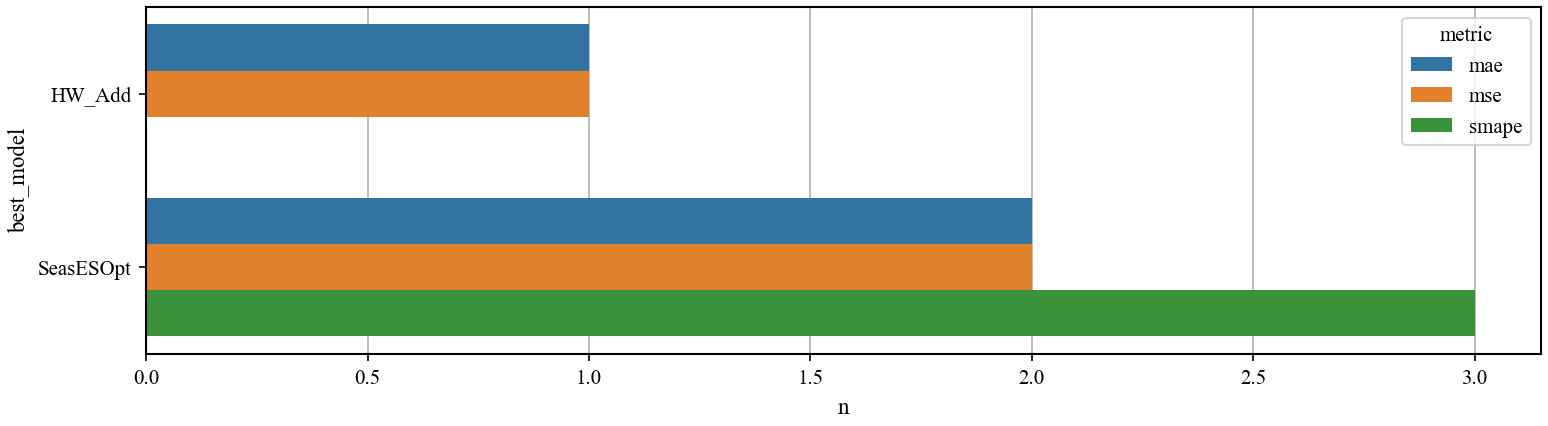

In [24]:
# Choose the best model for each time series, metric, and cross validation window
evaluation_df['best_model'] = evaluation_df.idxmin(axis=1, numeric_only=True)
# count how many times a model wins per metric and cross validation window
count_best_model = evaluation_df.groupby(['metric', 'best_model']).size().rename('n').to_frame().reset_index()
# plot results
sns.barplot(count_best_model, x='n', y='best_model', hue='metric')

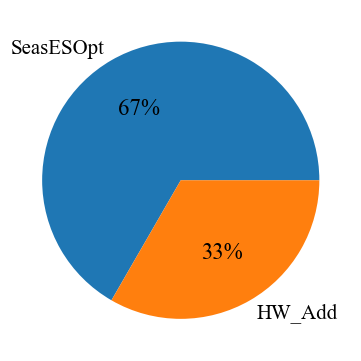

In [25]:
# For the mse, calculate how many times a model wins
eval_series_df = evaluation_df.query('metric == "mse"').groupby(['unique_id']).mean(numeric_only=True)
eval_series_df['best_model'] = eval_series_df.idxmin(axis=1)
counts_series = eval_series_df.value_counts('best_model')
plt.pie(counts_series, labels=counts_series.index, autopct='%.0f%%')
plt.show()

Попробуем визулизировать окона, которые мы получили

In [20]:
def plot_cv_windows(df, unique_id, cutoffs, h, title="CV Windows"):

    fig, ax = plt.subplots(figsize=(10, 2))
    # test_ends = cutoffs + pd.to_timedelta(h, unit=)
    for i, cutoff in enumerate(cutoffs):
        y_level = i + 1
        test_end = pd.to_datetime(cutoff) + pd.Timedelta(weeks=h)
        ax.plot([df['ds'].min(), cutoff], [y_level, y_level],  color='blue', linewidth=2)
        ax.plot([cutoff, test_end], [y_level, y_level],  color='red', linestyle='--', linewidth=2)
        ax.scatter([cutoff], [y_level], color='black', s=20)
        ax.scatter([test_end], [y_level], color='black', s=20)
    ax.set_yticks(range(1, len(cutoffs) + 1))
    ax.set_yticklabels([f"Окно {i+1}" for i in range(len(cutoffs))])
    ax.set_title(title)
    ax.grid(True, axis='x', linestyle='--', alpha=0.5)
    plt.tight_layout();     plt.show()

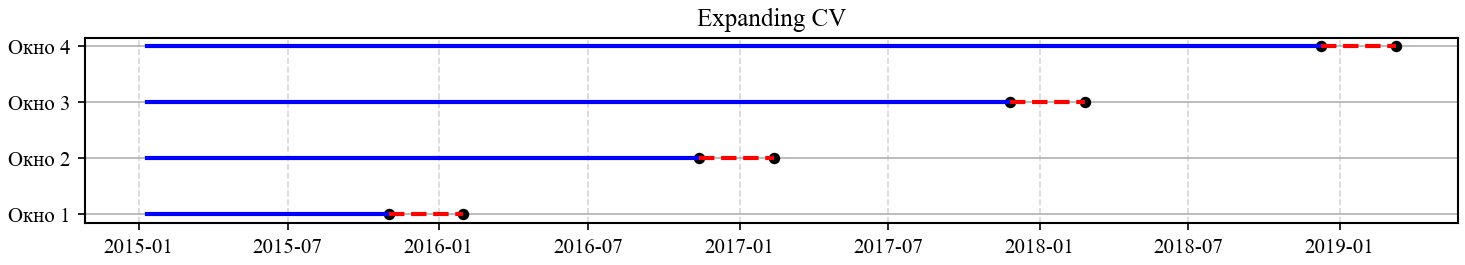

In [21]:
plot_cv_windows(panel_df, 'Consumption', cutoff, h=13, title="Expanding CV")

Мы рассмотрели стратеги CV  с раширяющимся окном. В целом стратегии спилата окон [могут быть и другими]( https://joaquinamatrodrigo.github.io/skforecast/0.11.0/user_guides/backtesting.html).

На практике также стратегия сплита должны выбираться так, чтобы [соответствовать задаче](https://dl.leima.is/time-series/timeseries-evaluation.forecasting/). Например, в ряде случаев окно валидации должно опережать окно теста так, чтобы мы могли симулировать процесс в котором накопление данных значительно медленней появления новых данных. Или же например, в случае моделей глубокого обучения окно должно всегда быть фиксированного размера. Также  в некоторых случая - длинных ВР, отдельны интерес может представлять бектест для отдельных паттернов. В этом случае полезным будет использование нескольких стратегий спилат окна.


Отметим также, что при помощи процедуры `backtest` может быть построена процедура автоматизированногог сравнения моделей предсказания [`benchmarking`](https://github.com/sktime/sktime/blob/main/examples/04_benchmarking_v2.ipynb).

Отметим также, что на практике [выбор метрики](https://unit8co.github.io/darts/generated_api/darts.metrics.metrics.html#) или [метрик](https://auto.gluon.ai/stable/tutorials/timeseries/forecasting-metrics.html) для сравнения ВР это не тривиальный вопрос. Метрики могут быть разделены [на несколько классов](https://dl.leima.is/time-series/timeseries-metrics.forecasting/) при этом каждая из [метрик](https://otexts.com/fpp3/accuracy.html) будует иметь свою [интерпретацию](https://www.mdsi.tum.de/fileadmin/w00cet/di-lab/pdf/Amazon_SS2022_Final_Report.pdf). 

>Также отметим, что в ряде случаев верной оценкой точности на прогнозе было бы использование т.н. [__динамического прогноза__](https://timeweb.cloud/tutorials/python/prognozirovanie-vremennyh-ryadov-python-3#dinamicheskij-prognoz). Т.е. такого, когда следующие значения предсказанной величины строятся на результатах предсказания ее предыдущих значений а не на исходных тестовых данных. В противовес этому тестирование на выборке исходных данных может быть названо [__статическим прогнозом__](https://timeweb.cloud/tutorials/python/prognozirovanie-vremennyh-ryadov-python-3#staticheskij-prognoz).





## Построение вероятностных прогнозов моделей

### Покрытие интервала predict_interval

<!-- Как уже было замечено вероятностное прогназирование часто используется для двух процедур:
* [процедура `backtest`](https://joaquinamatrodrigo.github.io/skforecast/0.8.1/user_guides/backtesting.html) в качестве допонительной меры отбора моделей и настройки их параметров.
* [допонительные метрики](https://auto.gluon.ai/stable/tutorials/timeseries/forecasting-metrics.html) оценки для будущих значений при настройки моделей. В том числе как мера оценки [интервала разброса значений оценки](https://otexts.com/fpp3/prediction-intervals.html). Такие метрики могут помочь и дополнить процедуру evaluation. Каждая из метрик будет иметь [свою интерпретацию](https://otexts.com/fpp3/distaccuracy.html). -->

Большая часть моделей (см. [документацию тут](https://nixtlaverse.nixtla.io/statsforecast/src/core/models_intro.html)) позволяют оценивать как точечное значение, так и строить интервальный прогноз. То есть прогнозировать величину заданного доверительного интервала (например 90%) [означает оценку интервала значений](https://nixtlaverse.nixtla.io/statsforecast/docs/tutorials/uncertaintyintervals.html) в котором окажется действительная величина окажется относительно предсказаной с вероятностью 90%). 

Такое значение другими словами показывает неопрделенногость предсказания.

> Важно поримать что оценка неопределенности предсказания как правило шире чем доверительный интервал. Доверительный интервал оценивается по текущим значениям выборки, в то время как неопрделенногость предсказания дает оценку разброса в будущем.



<!-- <blockquote>
    
Формальный вид прогноза (эндогенный, одна временная метка прогноза):
* Пусть $y(t_1), \dots, y(t_n)$ - это наблюдения в фиксированные моменты времени $t_1, \dots, t_n$.
(мы рассматриваем $y$ как $\mathbb{R}^n$-значную случайную величину).
* Пусть $y'$ - это (истинное) значение, которое будет наблюдаться в будущий момент времени $\tau$.
(мы рассматриваем $y'$ как $\mathbb{R}$-значную случайную величину) -->

Более формально можно выделить несколько видов вероятностного прогноза:

* __"точечный прогноз"__ - это предсказание/оценка условного ожидания $E[y'|y]$, где $y'$ - истинный результат. Интуиция: "из множества повторений/разных попыток предсказания - результат значение средним арифметическим значением".

* __"дисперсионный прогноз"__ (`predict_var(fh=None, X=None, cov=False)`) - это предсказание/оценка условного ожидания дисперсии $Var[y'|y]$. Интуиция: "из множества повторений - это значение является средним квадратичным расстоянием от наблюдения до идеального точечного прогноза".

* __"квантильный прогноз"__(`predict_quantiles(fh=None, X=None, alpha=[0.05, 0.95])`), в точке квантиля $\alpha \in (0,1)$ - это предсказание/оценка $\alpha$-квантиля $y'|y$, т.е. $F^{-1}_{y'|y}(\alpha)$, где $F^{-1}$  это (обобщенная) обратная `CDF` = квантильная функция случайной величины $y'|y$. Интуиция: "Из множества повторений вероятность появления данного будет равна или меньше  значения $\alpha$".
 
* __"Интервальный прогноз"__ или __"интервал предсказания"__ (`predict_interval(fh=None, X=None, coverage=0.90)`) с (симметричным) охватом $c \in (0,1)$ - это пара прогноз/оценка с нижней границей $a$ и верхней границей $b$, такая, что $P(\alpha \le y' \ge b|y)=c$ и $P(y'>b|y)=P(y<a|y)=(1-c)/2$. Интуиция: "Из множества повторений результат будет содержаться в интервале $[a,b]$  с вероятностью $c$. Причем вероятность того, что будут результаты выше равна вероятности того, что  будут результаты ниже".

* __"прогноз распределения"__ или __"полный вероятностный прогноз"__ (`predict_proba(fh=None, X=None, marginal=True)`)- это предсказание/оценка распределения $y'|y$ например, "это нормальное распределение со средним 42 и дисперсией 1". Интуиция: исчерпывающее описание механизма порождения множества повторений.

<!-- Примечания:
* _нижняя/верхняя часть интервальных прогнозов_ - это квантильные прогнозы в точках квантилей $0,5 - c/2$ и $0,5 + c/2$ (при условии, что распределения прогнозов абсолютно непрерывны).
* все остальные прогнозы могут быть получены из полного вероятностного прогноза; полный вероятностный прогноз может быть получен из всех квантильных или всех интервальных прогнозов.
* не существует точной зависимости между другими типами прогнозов (точечный или дисперсионный vs квантильный)
* в частности, точечный прогноз не обязательно должен быть медианным прогнозом aka 0,5-квантильным прогнозом. Это может быть 
$\alpha$-quantile для любого $\alpha$! -->
<!-- 
Частая путаница в литературе и пакетах python: * охват 'c' vs квантиль '\alpha' * охват 'c' vs значимость 'p = 1-c' * квантиль нижней границы интервала, 'p/2', vs 'p' * интервальные прогнозы vs связанные, но существенно разные понятия: доверительный интервал для прогнозируемого среднего; байесовский апостериор или интервал доверия для прогнозируемого среднего * все прогнозы выше могут быть байесовскими, путаница: "апостериоры разные" или "должны оцениваться по-разному". -->



<!-- Formal view (endogeneous, one forecast time stamp):

Let $y(t_1), \dots, y(t_n)$ be observations at fixed time stamps $t_1, \dots, t_n$.

(we consider $y$ as an $\mathbb{R}^n$-valued random variable)

Let $y'$ be a (true) value, which will be observed at a future time stamp $\tau$.

(we consider $y'$ as an $\mathbb{R}$-valued random variable)

More formal details & intuition:
* a “point forecast” is a prediction/estimate of the conditional expectation $E[y'|y]$ where $y'$ is a true result.
. Intuition: “out of many repetitions/differnt attempts to forecast, this value is the arithmetic average of all observations”.
* a “variance forecast” ('predict_var(fh=None, X=None, cov=False)')  is a prediction/estimate of the conditional expectation $Var[y'|y]$ 
. Intuition: “out of many repetitions/worlds, this value is the average squared distance of the observation to the perfect point forecast”.
* a “quantile forecast”, at quantile point  $\alpha \in (0,1)$ is a prediction/estimate of the 
$\alpha$-quantile of $y'|y$, i.e., of $F^{-1}_{y'|y}(\alpha)$, where $F^{-1}$
 is the (generalized) inverse cdf = quantile function of the random variable $y'|y$. 
 Intuition: “out of many repetitions/worlds, a fraction of exactly 
 will have equal or smaller than this value.”
* an “interval forecast” or “predictive interval” with (symmetric) coverage $c \in (0,1)$ is a prediction/estimate pair of lower bound $a$ and upper bound 
$b$ such that $P(\alpha \le y' \ge b|y)=c$
and $P(y'>b|y)=P(y<a|y)=(1-c)/2$. Intuition: “out of many repetitions/worlds, a fraction of exactly $c$
will be contained in the interval $[a,b]$, and being above is equally likely as being below”.
* a “distribution forecast” or “full probabilistic forecast” is a prediction/estimate of the distribution of $y'|y$
, e.g., “it’s a normal distribution with mean 42 and variance 1”. Intuition: exhaustive description of the generating mechanism of many repetitions/worlds.

Notes:

* lower/upper of interval forecasts are quantile forecasts at quantile points  $0.5 - c/2$
 and $0.5 + c/2$
 (as long as forecast distributions are absolutely continuous).
* all other forecasts can be obtained from a full probabilistic forecasts; a full probabilistic forecast can be obtained from all quantile forecasts or all interval forecasts.
* there is no exact relation between the other types of forecasts (point or variance vs quantile)
* in particular, point forecast does not need to be median forecast aka 0.5-quantile forecast. Can be 
$\alpha$-quantile for any $\alpha$!

Frequent confusion in literature & python packages: * coverage 'c' vs quantile '\alpha' * coverage 'c' vs significance 'p = 1-c' * quantile of lower interval bound, 'p/2', vs 'p' * interval forecasts vs related, but substantially different concepts: confidence interval on predictive mean; Bayesian posterior or credibility interval of the predictive mean * all forecasts above can be Bayesian, confusion: “posteriors are different” or “have to be evaluted differently”

 -->



Отметим еще раз важность прогнозирования интервалов предсказания [(доверительных интервалов) во временных рядах](https://nixtlaverse.nixtla.io/mlforecast/docs/tutorials/prediction_intervals_in_forecasting_models.html#importance-of-confidence-interval-prediction-in-time-series):
* __Оценка неопределенности__: Доверительный интервал обеспечивает меру неопределенности, связанной с прогнозами временных рядов. Он позволяет количественно оценить изменчивость и диапазон разборса возможных будущих значений, что очень важно для принятия обоснованных решений.
* __Оценка точности__: Имея доверительный интервал, можно оценить надежность прогнозов. Если интервал узкий, это говорит о том, что прогноз более точный и надежный. С другой стороны, если интервал широкий, это указывает на большую неопределенность и меньшую точность прогноза.
* __Управление рисками__: Доверительный интервал помогает в управлении рисками, предоставляя информацию о возможных сценариях будущего. Он позволяет определить диапазоны, в которых могут находиться реальные значения, и принимать решения на основе этих возможных сценариев.
* __Эффективная коммуникация__: Доверительный интервал - полезный инструмент для четкой и точной передачи прогнозов. Он позволяет донести до заинтересованных сторон изменчивость и неопределенность, связанную с прогнозами, избегая неправильной или слишком оптимистичной интерпретации результатов.

Поэтому прогнозирование доверительных интервалов во временных рядах необходимо для понимания и управления неопределенностью, оценки точности прогнозов и принятия обоснованных решений на основе возможных сценариев будущего.

<!-- >Большинство моделей временных рядов генерируют прогнозы, которые следуют нормальному распределению, что подразумевает, что мы предполагаем, что возможные будущие значения следуют нормальному распределению. Однако, реальное распределение не всегда такое. -->



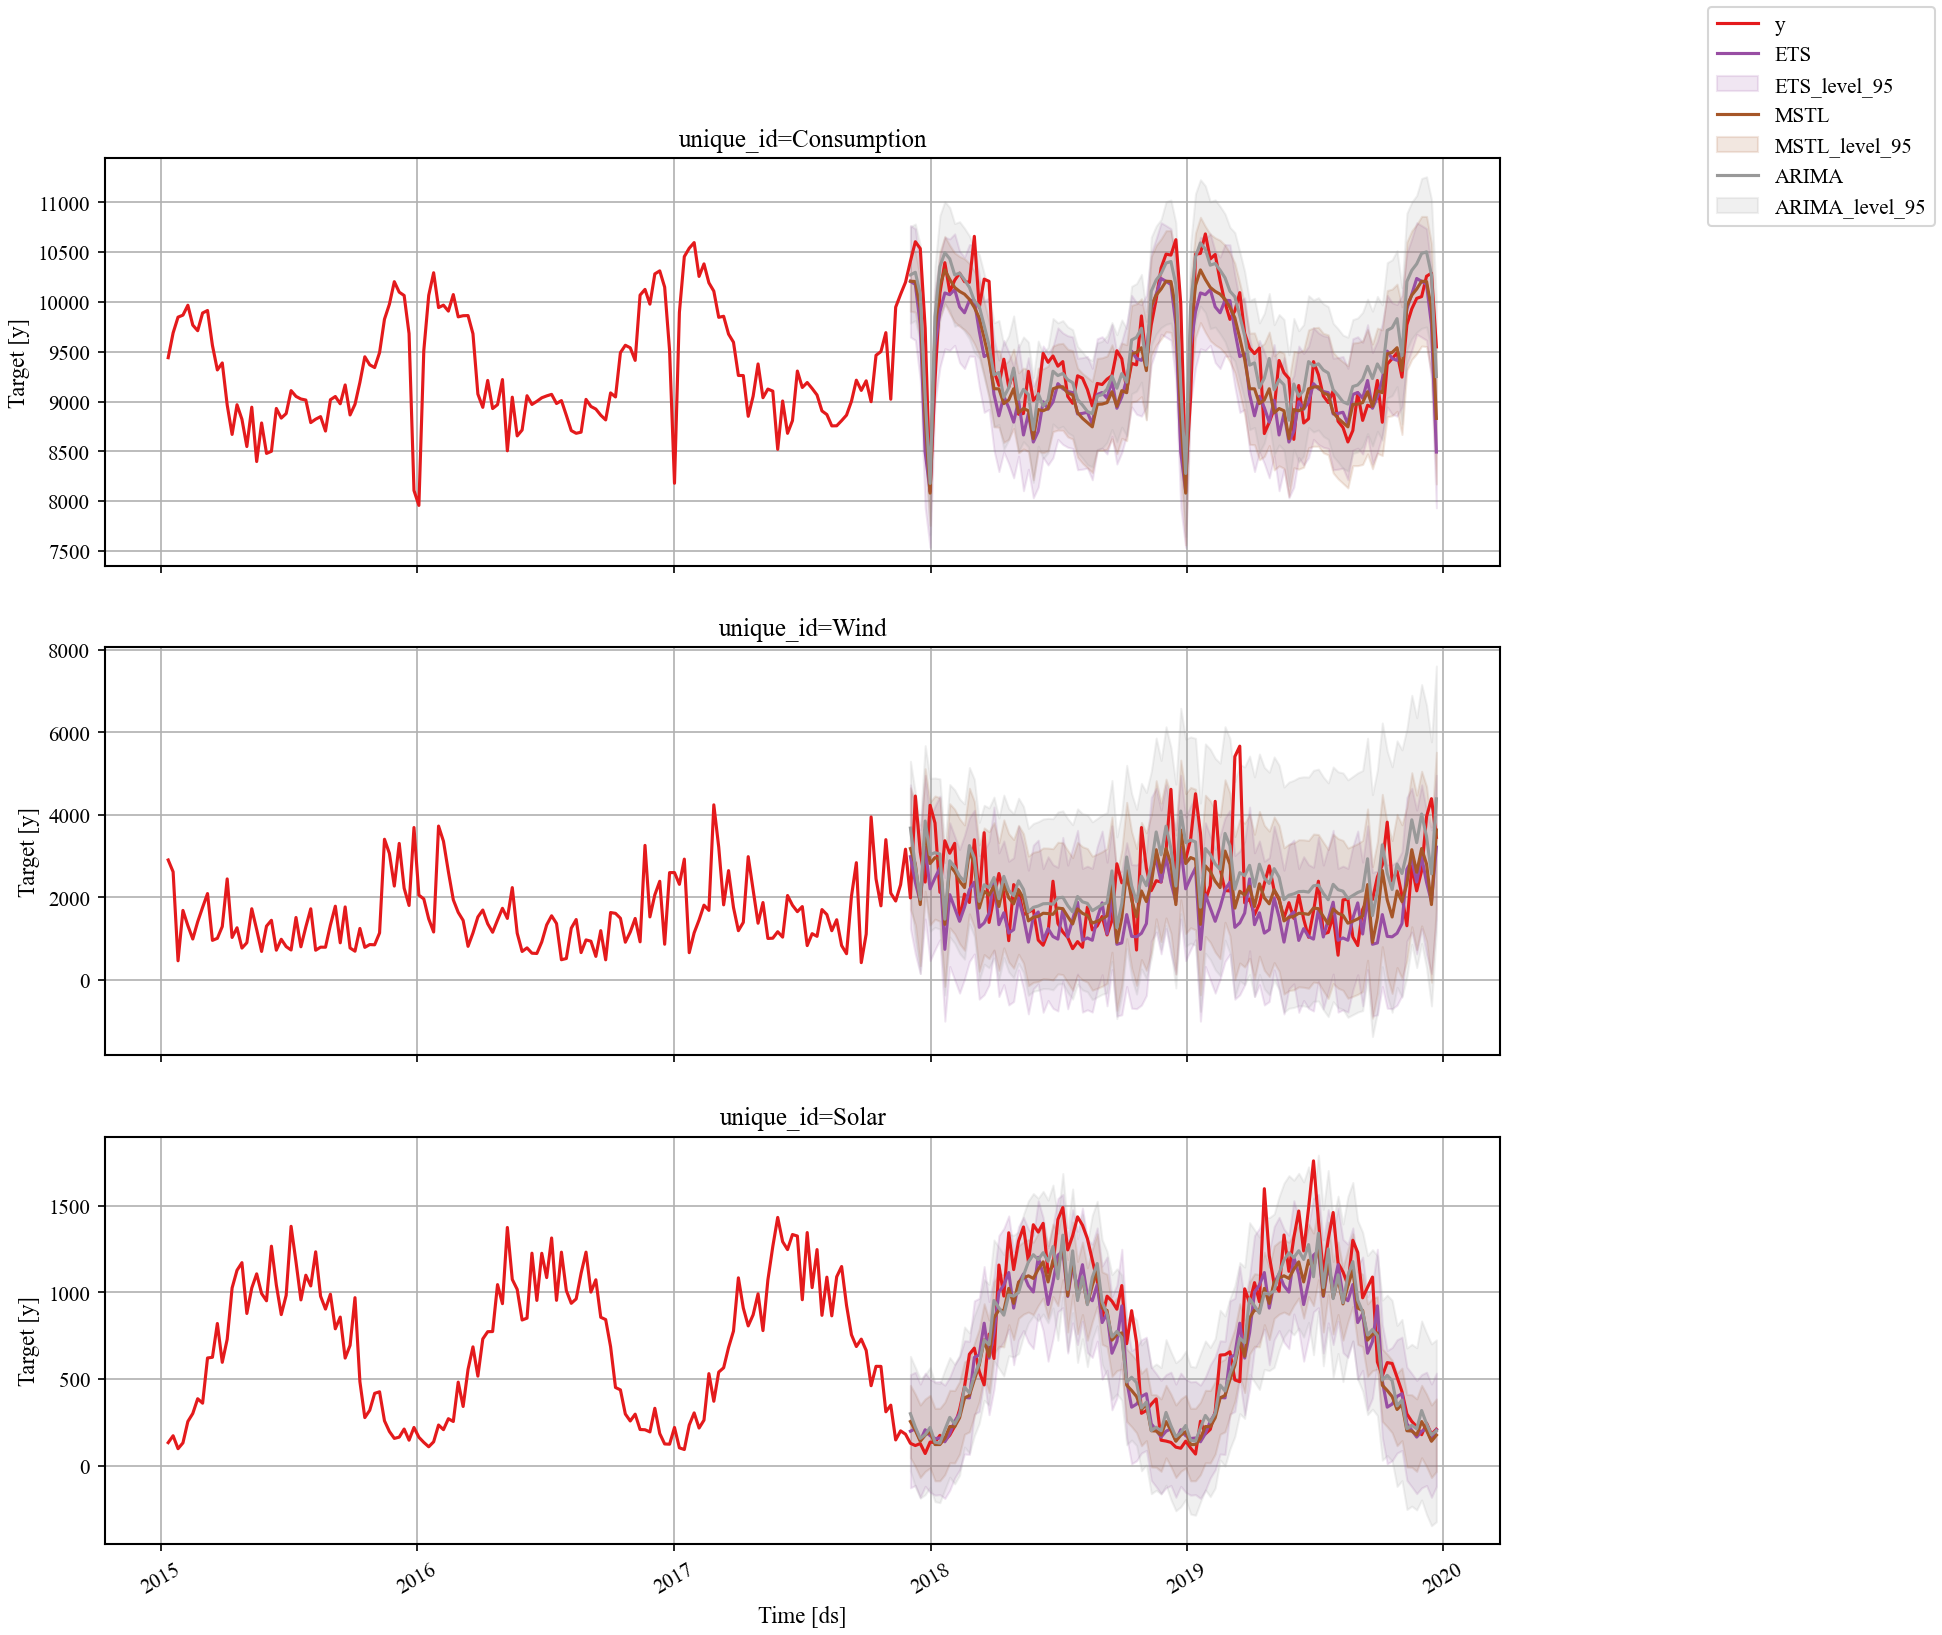

In [23]:
models = [
    AutoETS(season_length=SEASON, model='ZZA', damped = False, alias='ETS'),
    MSTL(season_length=SEASON, ),
    # TBATS(SEASON, use_trend = True, use_damped_trend = True),
    ARIMA(order=(3, 1, 1),
                season_length = SEASON,
                seasonal_order = (0, 1, 1,)  )
    
]

LEVELS = [0.25, 0.5, 75, 90, 95]


sf = StatsForecast(
    models=models,
    freq=FREQ,
)

fcst_sf = sf.forecast(df=df_train, h=FH, level=LEVELS)
eval_sf = df_test.merge(fcst_sf, on=['unique_id', 'ds'])

alias = [x for x in fcst_sf.columns if not x in base_cols]

n_rows = eval_sf['unique_id'].nunique()
fig, ax = plt.subplots(n_rows, 1, figsize=(12, 4*n_rows), sharex=True)

plot_series(
    df_train,
    forecasts_df = eval_sf,
    level=LEVELS[-1:],
    ax=ax,
    palette='Set1',
)

#### Упражение
1. Проверить визуально, как будет меняться разброс в зависимости от параметров модели.
2. провести визуализацию интервалов insample

### Оценка вероятностных метрик

#### Оценка метрик на квантилях
При оценках квантилей возникает вопрос о том, как 
- использовать значения  квантилей для сравнения моделей предсказания между собой (где ширина интервала предсказания меньше),
- как выбрать модель, правильно [предсказывающую квантиль](https://arxiv.org/pdf/2211.02989.pdf)).

>В отличие от точечных прогнозов (MAE, RMSE), квантильный прогноз намеренно смещён.
>
>Например, 0.9-квантиль не должен быть близок к среднему значению — он должен быть выше большинства наблюдений.


Для оценки качества квантильных прогнозов используют  [квантильную функцию потерь](https://github.com/aryan-jadon/Regression-Loss-Functions-in-Time-Series-Forecasting-PyTorch) ([quantiles loss](https://www.lokad.com/quantile-regression-time-series-definition/) - `quantil loss` (также функция называется Pinball loss).

Для значения квантиля $\alpha \in (0,1) $ мера [<tt>quantil loss</tt>](https://www.lokad.com/pinball-loss-function-definition/)  

$$L_{\alpha}(\widehat{y}_{\alpha}, y) := \begin{cases} \alpha \cdot \Theta (y - \widehat{y}_{\alpha})\text{, if } y\ge \widehat{y}_{\alpha} \\ (1-\alpha) \cdot \Theta (\widehat{y}_{\alpha} - y) \text{, otherwise }\end{cases}$$

или

$$L_{\alpha}(\widehat{y}_{\alpha}, y) := \alpha \cdot \Theta (y - \widehat{y}_{\alpha}) + (1-\alpha) \cdot \Theta (\widehat{y}_{\alpha} - y)$$

где 
- $\Theta (x) := \begin{cases}1 \text{, if } x\ge 0 \\ 0 \text{, otherwise }\end{cases}$ - функция Хевисайда.
- $y$ — наблюдаемое значение,
- $\hat{y}_{\alpha}$  — прогноз квантиля уровня $\alpha \in (0,1) $.
  
Вид  <tt>quantil loss</tt>       
<img src='https://mintcdn.com/nixtla/osl8VFUd2EwfaY-Y/utilsforecast/imgs/losses/q_loss.png?w=2500&fit=max&auto=format&n=osl8VFUd2EwfaY-Y&q=85&s=1e4bdbddd424fff2ff0eb53f0b491393' style="width:300px;">   
 
__Важно понимать__, что <tt>quantil loss</tt> - это не метрика, Абсолютные значения не так важны, как сравнение моделей!

__quantil loss__ штрафует асимметрично:
- если модель недооценила квантиль ($y>\hat{y}_{\alpha}$ ), штраф пропорционален ${\alpha}$;
- если модель переоценила квантиль ($y<\hat{y}_{\alpha}$ ), штраф пропорционален ${1-\alpha}$.
- Минимум математического ожидания pinball loss достигается на истинном ${\alpha}$ - квантиле распределения.
- меньший pinball loss - более точный квантильный прогноз.
- pinball loss косвенно отражает калибровку модели (если квантиль 0.9 часто оказывается ниже наблюдений - высокая потеря. 

Пример: для $\alpha=0.9$ модель сильно наказывается за недооценку, но слабо — за переоценку.<br>
Это ровно соответствует смыслу $90$-го квантиля:
истинное значение должно быть ниже прогноза примерно в $90\%$ случаев.


<!-- >Заметим, что оценка точности квантильного прогноза - сложная задача. Действительно, в отличие от классических прогнозов, где цель состоит в том, чтобы прогноз был как можно ближе к наблюдаемым значениям, в квантильных прогнозах ситуация смещена (намеренно). Поэтому наивное сравнение наблюдаемых и прогнозируемых значений не приносит эффекта. В тоже время функция потерь `quantil loss` возвращает значение, которое можно интерпретировать как [точность квантильной модели прогнозирования](https://www.lokad.com/pinball-loss-function-definition/). -->
<!-- >
>Функция `quantil loss` всегда положительна, и чем дальше от цели тем больше ее значение. Наклон функции  используется как параметр для отражения желаемого дисбаланса в квантильном прогнозе. Наиболее важный результат, связанный с функцией потерь , заключается в том, что чем меньше потери пинбола, тем точнее квантильный прогноз. В ряде случаев можно считать, что функция потерь является индекаторм отсуствия переобучения у модели. Кроме того функция может быть использовна непосредственно как метрика, позволяя сравнить несколько [моделей между собой](https://www.lokad.com/tv/2022/1/5/no1-at-the-sku-level-in-the-m5-forecasting-competition/).
>
> Отметим, что функция `pinball loss` не единственная метрика для сравнения [вероятностных прогнозов моделей](https://www.lokad.com/continuous-ranked-probability-score/), есть и лругие популярные решния, например [ранговый вероятностный скор (CSRP)](https://www.sktime.net/en/latest/api_reference/auto_generated/sktime.performance_metrics.forecasting.probabilistic.CRPS.html) -->
<!-- The function is always positive and the further away from the target 
, the larger the value of 
. The slope is used to reflect the desired imbalance in the quantile forecast.
The most important result associated with the pinball loss function is that the lower the pinball loss, the more accurate the quantile forecast. -->

<!-- Evaluating the accuracy of a quantile forecast is a subtle problem. Indeed, contrary to the classic forecasts where the goal is to have the forecast as close as possible from the observed values, the situation is biased (on purpose) when it comes to quantile forecasts. Hence the naive comparison observed vs forecasts is not satisfying. The pinball loss function returns a value that can be interpreted as the accuracy of a quantile forecasting model.https://www.lokad.com/pinball-loss-function-definition/ -->

In [237]:
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import quantile_loss

metrics_sf_models = evaluate(
    df=eval_sf,
    metrics=[quantile_loss],   # только quantile_loss
    train_df=df_train,          # можно, если нужно
    level=LEVELS[2:-1],               # ← StatsForecast сам понимает, что lo/hi = квантили
)

metrics_sf_models.pivot_table(
    index=['unique_id', 'metric'],
    values=['ETS', 'ARIMA']
)

ARIMA         ETS
unique_id   metric                                      
Consumption quantile_loss_q0.05    34.364328   33.995726
            quantile_loss_q0.125   62.140616   69.358265
            quantile_loss_q0.875   74.426537  100.095045
            quantile_loss_q0.95    38.521497   60.478036
Solar       quantile_loss_q0.05    25.920104   21.143822
            quantile_loss_q0.125   47.834694   42.129840
            quantile_loss_q0.875   52.350148   51.661213
            quantile_loss_q0.95    29.453208   27.951466
Wind        quantile_loss_q0.05   119.665826  102.427774
            quantile_loss_q0.125  225.740670  204.523771
            quantile_loss_q0.875  381.855090  312.785564
            quantile_loss_q0.95   194.272932  200.245176

Интерпретация:
чем меньше - тем лучше. На самом дел надо смотреть на заданный квантиль, но nixla считает сразу как само значение на квантиле $\alpha$, так и $1-\alpha$

- ETS лучше в нижних квантилях - лучше ловит провалы
- ARIMA лучше в верхних квантилях - лучше ловит пики



#### Сравнение качества покрытия интервалов
Аналогично изученному случаю с квантилям можно расчитать функцию потерь и для других типов вероятносного прогнозирования.



In [238]:
from utilsforecast.losses import coverage

# Оценка coverage для тех же уровней, что и quantile_loss
metrics_coverage = evaluate(
    df=eval_sf,
    metrics=[coverage],     # только coverage
    train_df=df_train,      # можно, если нужно для scaled metrics
    level=LEVELS[:],      # совпадает с уровнями интервалов
)

# Таблица pivot для наглядности
metrics_coverage.pivot_table(
    index=['unique_id', 'metric'],
    values=['ETS', 'ARIMA']
)

ARIMA       ETS
unique_id   metric                                
Consumption coverage_level0.25  0.009259  0.009259
            coverage_level0.5   0.018519  0.018519
            coverage_level75    0.833333  0.638889
            coverage_level90    0.898148  0.796296
            coverage_level95    0.953704  0.861111
Solar       coverage_level0.25  0.000000  0.000000
            coverage_level0.5   0.009259  0.000000
            coverage_level75    0.824074  0.648148
            coverage_level90    0.907407  0.796296
            coverage_level95    0.925926  0.851852
Wind        coverage_level0.25  0.000000  0.009259
            coverage_level0.5   0.000000  0.009259
            coverage_level75    0.824074  0.675926
            coverage_level90    0.935185  0.824074
            coverage_level95    0.990741  0.870370

Интерпретация: чем ближе значение к заданой величине покрытия - тем лучше.

Для обеих моделей:
Низкие квантиля (0.1–0.5): (coverage < ideal_coverage) - прогнозы завышены: фактические значения часто меньше квантильного прогноза, т.е. модель не даёт низкие значения, недооценивает риск маленьких событий.

Для верхних кванитилей:
- ARIMA: почти идеально, чуть выше номинала → слегка консервативная
- ETS: ниже номинала → интервалы слишком узкие, недооценка неопределённости (занижение прогноза)


 

#### Оценка распределний вероятностей

[CRPS (Continuous Ranked Probability Score)](https://dl.leima.is/time-series/timeseries-metrics.forecasting.crps/) — это метрика для вероятностных прогнозов, которая измеряет расхождение между прогнозным распределением и фактическим наблюдением.
Значения CRPS представляет собой оценку совместно дисперсии, смещения и покрытия квантилей.
 
 - Калибровка (coverage): CRPS снижается, если интервалы (квантили) соответствуют фактическим данным.
 - Sharpness (ширина распределения): слишком широкие интервалы увеличивают CRPS, потому что 
F расходится с индикатором.
- Bias (смещение): если прогноз систематически выше или ниже фактических значений, CRPS увеличивается.


<!-- Для каждого момента времени t проводится сравнение:

- Прогнозного распределения $F_t(y_t)$ (CDF – кумулятивная функция распределения).
- Фактического наблюдения $y_t$.
 -->
[CRPS определяется как](https://www.lokad.com/continuous-ranked-probability-score/):

$$ {CRPS(F_t, y_t) = \int_{-\infty}^{\infty}\Big(F_t(y)- {\mathbf 1}(y_t\le y)\Big)^2dy} $$

где 
- ${F(y)=\mathbf{P}\left[y \leq y_t\right]}$ – кумулятивная функция распределения (CDF)
- Фактического наблюдения $y_t$ для каждого момента времени t.
- ${\mathbf 1}(y_t\le z)$ - индекаторная функция Хевисайда (ступенька), принимающая значение 1 если аргумент выше 0 или 0 в ином случае.

CRPS обобщает среднюю абсолютную ошибку (MAE). Фактически,  (она сводится к MAE, если прогноз является детерминированным). 

На пракитке ${CRPS(F_t, y_t) = \sum_{k=0}^x F(y_k)^2 + \sum_{x+1}^{n} (F(y_k) - 1)^2} $ <br>
или 
 CRPS  может быть вычислен как *множественный квантильный прогноз* $\widehat{\bf y}:=\widehat{y}_1, \dots, \widehat{y}_k$ для квантилей ${\bf \alpha} = \alpha_1,\dots, \alpha_k$ 
$$CRPS \approx\frac{1}{k}\sum_{i=1}^k L_{\alpha_i}(\widehat{y}_i, y)$$

То есть CRPS — это  усреднённое значение quantil loss по всем квантилям& CRPS измеряет, насколько прогнозное распределение совпадает с истинным значением.
Если прогноз идеален → CRPS = 0

В Nixtla  используется версия CRPS с нормализацией (scaled_crps). Нормализация выполняется относительно значения MAE наивного прогноза. Нормализация позволяет позволяет сравнивать значения метрики для разных ВР. 

In [239]:
from utilsforecast.losses import scaled_crps

# Оценка распределения для моделей
metrics_distribution = evaluate(
    df=eval_sf,
    metrics=[scaled_crps],
    train_df=df_train,    # для нормировки CRPS
    level=LEVELS[:],      # указываем уровни интервалов
)

# Pivot для наглядности
metrics_distribution.pivot_table(
    index=['unique_id', 'metric'],
    values=['ETS', 'ARIMA']
)

,,ARIMA,ETS
unique_id,metric,,
Consumption,scaled_crps,0.015814,0.019630
Solar,scaled_crps,0.130458,0.129665
Wind,scaled_crps,0.316793,0.243093


Из результатов следует, что ARMA лучше восстонавливает распределение чем ETS для Consumption. Для Solar примерно одинаков, тогда как для Wind ETS работает лучше

#### Кросс-валидация с CRPS

In [241]:
sf = StatsForecast(models=models, freq=FREQ) 

cv_df = sf.cross_validation(
    df=panel_df,
    h=FH//2,
    n_windows=4,
step_size=FH//8,
    level=LEVELS,
    refit=True,
)

cv_df.head(1)

,unique_id,ds,cutoff,y,ETS,ETS-lo-95,ETS-lo-90,ETS-lo-75,ETS-lo-0.5,ETS-lo-0.25,...,ARIMA-lo-95,ARIMA-lo-90,ARIMA-lo-75,ARIMA-lo-0.5,ARIMA-lo-0.25,ARIMA-hi-0.25,ARIMA-hi-0.5,ARIMA-hi-75,ARIMA-hi-90,ARIMA-hi-95
0,Consumption,2018-03-18,2018-03-11,10228.846,9825.637737,9351.103775,9427.396282,9547.122492,9824.120505,9824.879125,...,9291.201512,9378.583755,9515.713142,9832.975066,9833.843957,9835.581723,9836.450614,10153.712538,10290.841925,10378.224168
1,Consumption,2018-03-25,2018-03-11,10206.606,9508.324861,9033.786526,9110.079737,9229.807050,9506.807615,9507.566242,...,9212.857557,9300.964687,9439.231643,9759.125441,9760.001540,9761.753722,9762.629821,10082.523619,10220.790575,10308.897705
2,Consumption,2018-04-01,2018-03-11,9307.472,9265.050568,8790.506863,8866.800937,8986.529605,9263.533305,9264.291940,...,8794.282097,8883.572241,9023.695706,9347.884715,9348.772578,9350.548286,9351.436148,9675.625158,9815.748623,9905.038767
3,Consumption,2018-04-08,2018-03-11,9161.737,9380.977225,8906.427051,8982.722164,9102.452465,9379.459941,9380.218586,...,8786.661492,8877.423303,9019.856262,9349.388508,9350.291004,9352.095979,9352.998475,9682.530721,9824.963681,9915.725492
4,Consumption,2018-04-15,2018-03-11,9424.780,9073.689651,8599.131807,8675.428153,8795.160389,9072.172343,9072.931001,...,8367.375321,8458.466618,8601.416642,8932.145166,8933.050938,8934.862465,8935.768238,9266.496762,9409.446786,9500.538083


In [246]:
result = evaluate_cv(
    crossvalidation_df=cv_df,
    metrics=[smape, mae, rmse, scaled_crps],  # или любые другие из statsforecast.utils
    level = LEVELS,
    model_names=['ETS', 'ARIMA']
)
result

,cutoff,ETS,ARIMA
metric,,,
mae,2018-07-25 12:00:00,395.842150,422.717080
rmse,2018-07-25 12:00:00,519.633482,548.824137
scaled_crps,2018-07-25 12:00:00,0.114342,0.118779
smape,2018-07-25 12:00:00,0.102610,0.111291


#### Упражнение
1.  Провести визуализацию окон для кросс-валидации
2.  Провести сравнительный анализ еще 3 алгоритмов предсказания ВР, добавив также метрики покрытия интервалов.

### Калибровка интервалов

Калибровка квантилей — это коррекция прогнозных интервалов, чтобы они лучше соответствовали реальному покрытию (например, 95% интервал должен ловить 95% точек).

В задачах прикладного анализа ВР при использовании вероятностных прогнозов возникает проблема калибровки вероятности: даже если модель выдаёт квантили, они не обязательно соответствуют заявленному уровню покрытия (например, 90% интервал может ловить только 70% точек). Калиброванная модель гарантирует, что при регулярных условиях работы эмпирическое покрытие совпадает с номинальным.

Для калибровки применяются несколько подходов:

- Bootstrap-based calibration (беггинг) — коррекция квантилей на основе остатков модели в тренировочной выборке
- Conformal Prediction — построение интервалов по валидационной (калибровочной) подвыборке ( метод имеет теоретическую гарантию даже на конечной выборки);

В Nixtla реализован метод Conformal Prediction. Отметим, что метод процедуро-независимый, то есть с его помощью может быть выполнена оценка интервалов для почти любых алгоритмов. 

Метод ConformalIntervals [работает следующим образом](https://nixtlaverse.nixtla.io/statsforecast/docs/tutorials/conformalprediction.html#how-conformal-prediction-works)


1. **Обучение модели**  
Модель (например, Naive, SeasonalNaive, ETS) обучается на тренировочных данных.

2. **Вычисление остатков и сбор распределения ошибок**  
На калибровочной подвыборке для каждого шага прогнозирования вычисляются остатки:  
$$e_t = y_t - \hat{y}_t  $$

3. Абсолютные значения остатков формируют распределение $Q$, отражающее фактическую вариативность модели.

4. **Построение калиброванных интервалов**  
Для нового прогноза интервал строится по верхней квантиле распределения остатков:  
$$PI_t = [\hat{y}_t - Q_{1-\alpha} (e_t), \hat{y}_t + Q_{\alpha} (e_t)]$$

Таким образом интервалы адаптируются к фактической ошибке модели, даже если модель недооценивает или переоценивает дисперсию


Метод оценивает конформные ошибки по нескольким скользящим окнам, чтобы интервалы учитывали локальные изменения вариативности

**Особенности метода ConformalIntervals**  
- Работает с любой моделью  
- Учитывает локальные изменения дисперсии через n_windows  
- Не требует предположений о распределении остатков  
- Обеспечивает эмпирическое покрытие интервалов, близкое к заявленному уровню

Основной и самый важный недостаток - Конформная калибровка требует много данных и работает только при h ≤ длина_ряда // 3, поэтому ниже горизонт будет пересчитан. Также в силу небольшого набора данных не получится поработать с нашей моделью ARIMA

In [196]:
LEVELS = [90]

models = [
AutoETS(season_length=SEASON, model='ZZA',damped=True),                 
    SeasonalNaive(season_length=SEASON)    # сезонная наивная
]

model_names = [m.alias for m in models]
print(model_names)

['AutoETS', 'SeasonalNaive']


In [197]:
from statsforecast.utils import ConformalIntervals

# Безопасный горизонт для конформной калибровки
h = min(FH, df_train.groupby('unique_id').size().min() // 3)
if h < 1:
    raise ValueError("Данных слишком мало для конформных интервалов")

# Конформная калибровка (n_windows=2 обязательно)
pi = ConformalIntervals(h=h, n_windows=2)


sf = StatsForecast(models=models, freq=FREQ)
forecasts = sf.forecast(
    df=df_train,
    h=h,
    level=LEVELS,           # уровень PI
    prediction_intervals=pi
)

In [198]:
eval_sf_conf = df_test.merge(forecasts, on=['unique_id', 'ds'])

metrics = [coverage, scaled_crps]

metrics_eval = evaluate(
    df=eval_sf_conf,
    metrics=metrics,
    train_df=df_train,
    level=[90],
    id_col='unique_id',
    time_col='ds',
    target_col='y'
)

pivot_cov_crps = metrics_eval.pivot_table(
    index=['unique_id', 'metric'],
    values=model_names
)
pivot_cov_crps

AutoETS  SeasonalNaive
unique_id   metric                                   
Consumption coverage_level90  0.980000       0.520000
            scaled_crps       0.010114       0.014427
Solar       coverage_level90  0.840000       0.520000
            scaled_crps       0.059262       0.099060
Wind        coverage_level90  0.880000       0.560000
            scaled_crps       0.235892       0.174384

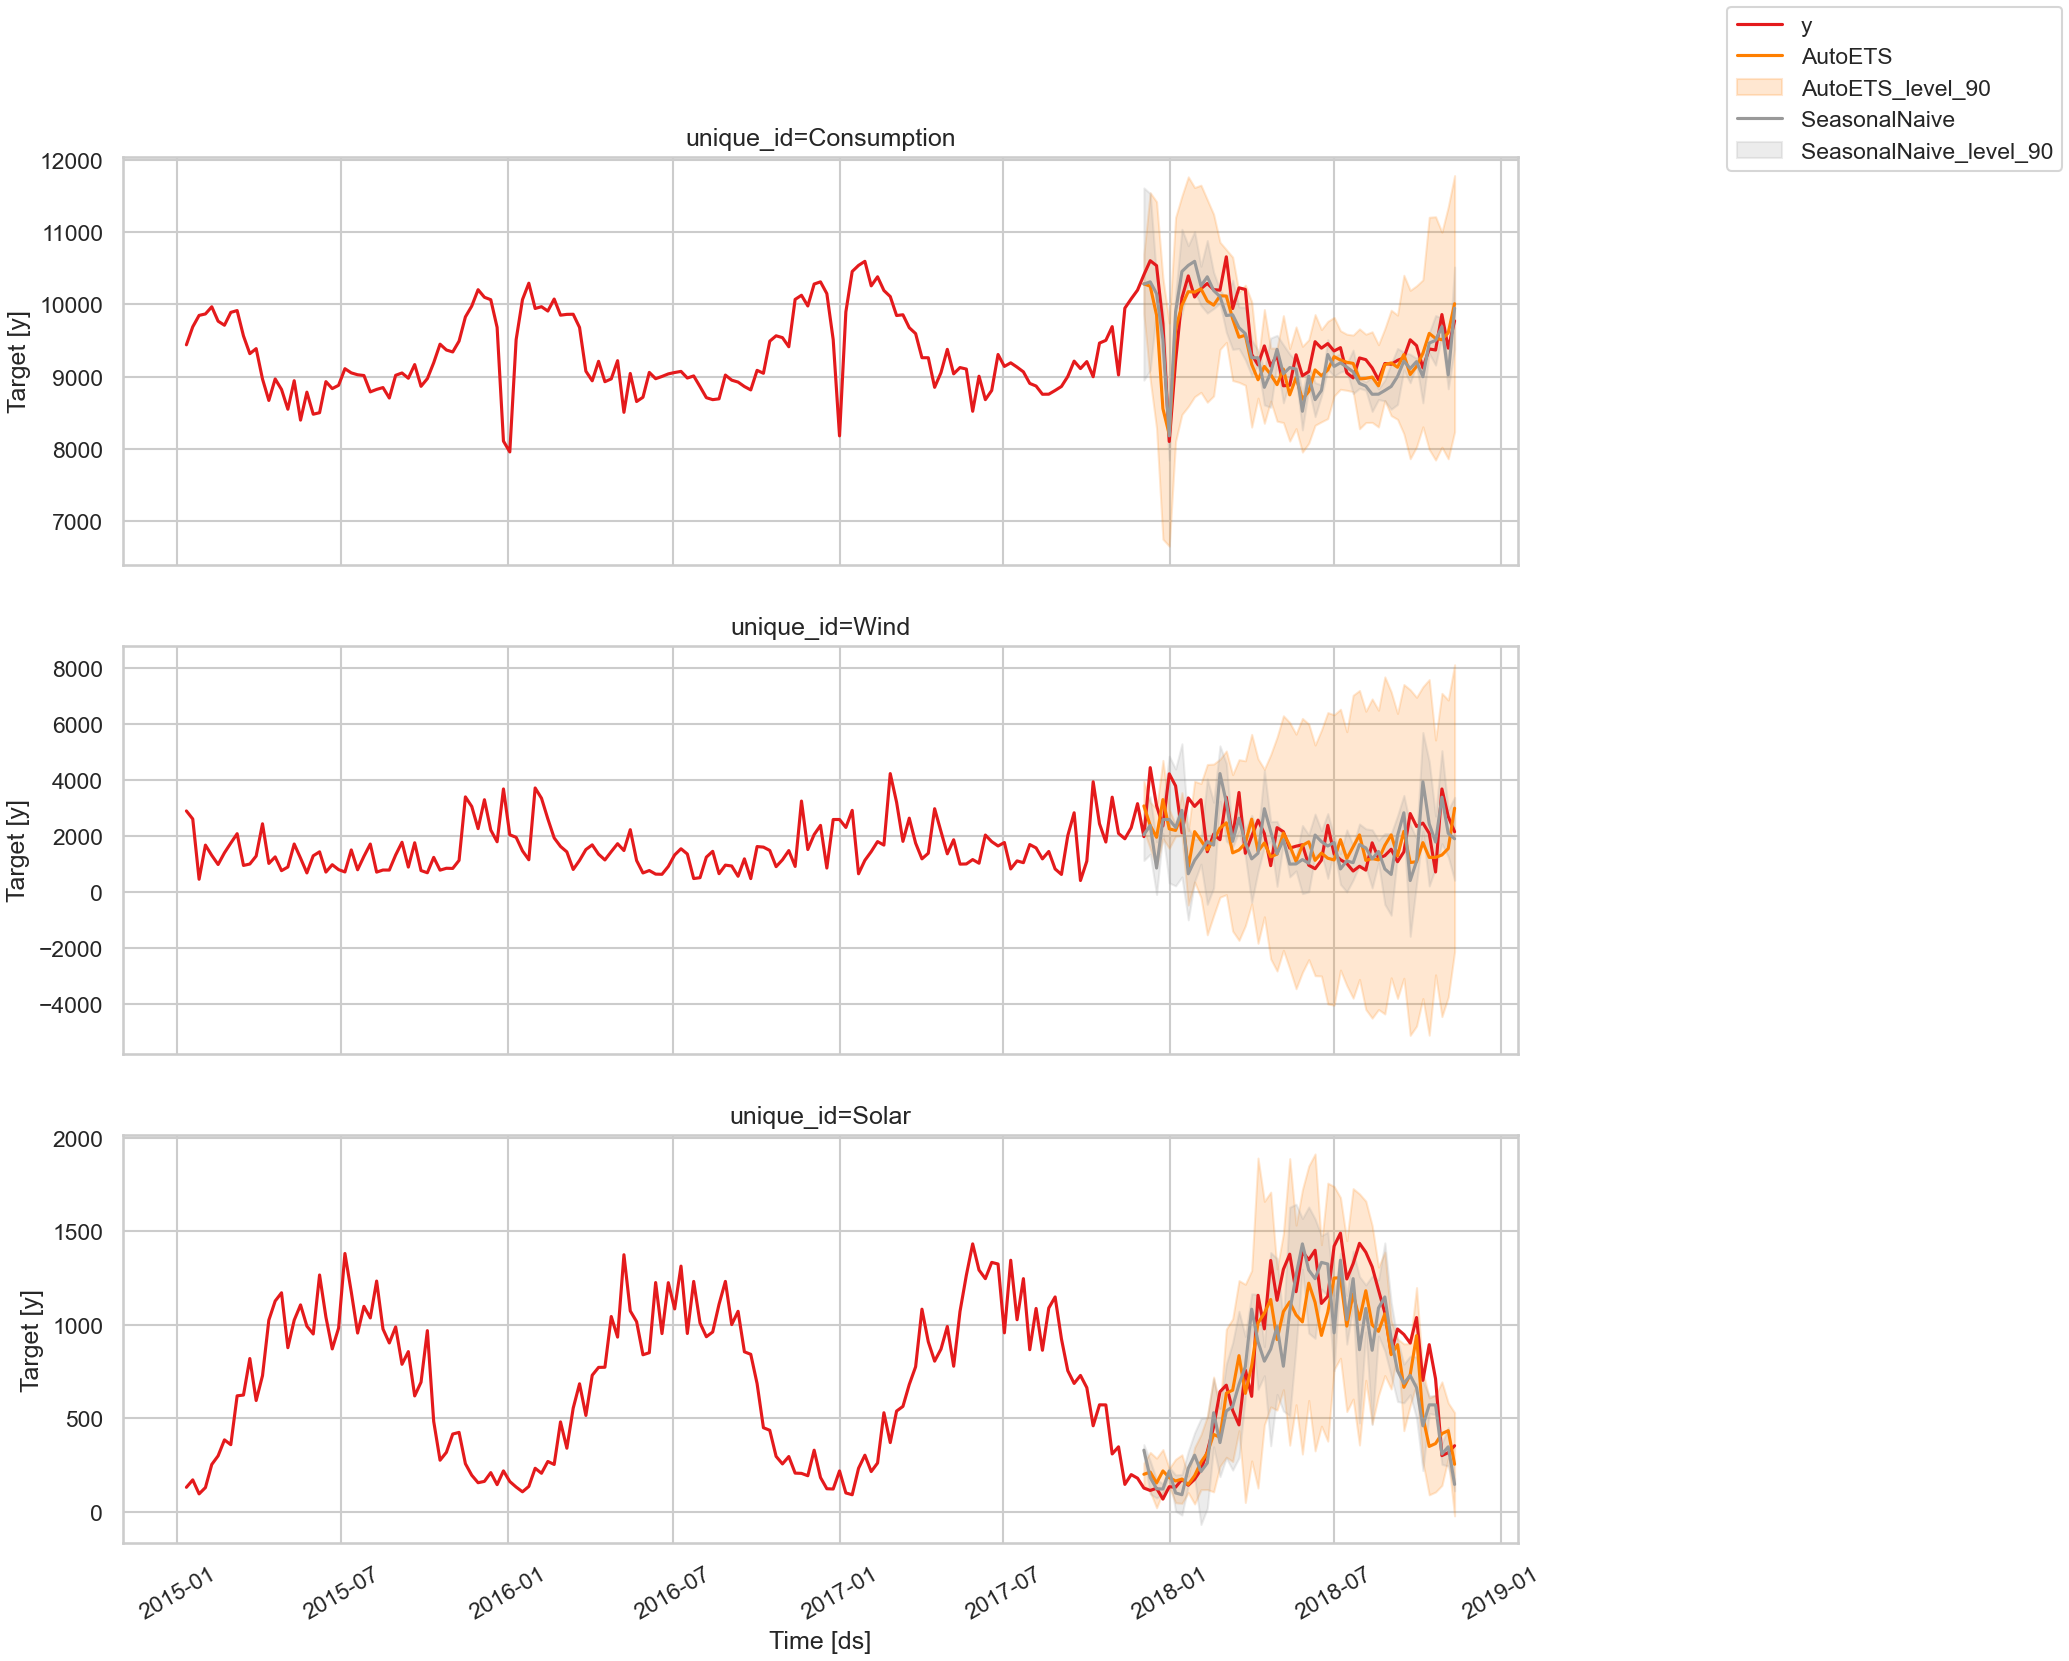

In [199]:
n_rows = eval_sf_conf['unique_id'].nunique()
fig, ax = plt.subplots(n_rows, 1, figsize=(12, 4*n_rows), sharex=True)
plot_series(
    df_train,
    forecasts_df=eval_sf_conf,
    level=[90],
    ax=ax,
    palette='Set1'
)

#### Расширение прогноза с расчитанными интервалами

Для экстраполяции расчитанных интервалов forecasts  примем предположение, что интервал растет прпорционально корню из шага прогноза

Теперь проведем экстраполяцию:
- строим еще один точечный прогноз forecasts_point 
- для значений меньше h добавляем в forecasts_point значения из forecasts
- расчитываем среднюю половину ширины интервала на калибровочном горизонте
   $$
   q = \frac{1}{h} \sum_{t=1}^{h} \frac{\text{hi}_t - \text{lo}_t}{2}
   $$
-  Масштабируем ширину интервала для будущих точек, предполагая, что **неопределённость растёт со временем как $\sqrt{t/h}$**:
  $$ \text{half\_width}_t = q \cdot \sqrt{\frac{t}{h}}, \quad t = h+1, \dots, FH$$
    где:  
   - $t$ — номер шага прогноза относительно конца калибровочного горизонта. Например, если $h=10$, то первый шаг за пределами калибровки $t=11$, следующий $t=12$ и т.д.  
   - $\sqrt{t/h}$ — стандартное предположение о росте дисперсии случайного блуждания: чем дальше прогноз, тем шире интервалы.

   - Экстраполированные интервалы добавляются к **точечному прогнозу**:

   $$
   \text{lo}_t = \hat{y}_t - \text{half\_width}_t, \quad
   \text{hi}_t = \hat{y}_t + \text{half\_width}_t
   $$

- Для $t \le h$ используются реальные конформные интервалы.  
- Для $t > h$ интервалы экстраполируются с учётом роста неопределенности.

На что обратить внимание:
- Средняя ширина ($q$) усреднена по калибровочному горизонту. Если ВР не стационарен или есть сильная сезонность, она может недооценивать или переоценивать будущую неопределённость.
- Можно вместо среднего брать квантили распределения половины ширины или постепенно скользящее усреднение, чтобы учесть тренды в волатильности.
- Масштабирование $\sqrt t$ предполагает, что ошибки независимы и одинаково распределены. Для сезонных или автокоррелированных временных рядов это будет только приблизительно.

In [200]:
# Создаём копию точечного прогноза
forecasts_full = forecasts_point.copy()

# Добавляем колонки интервалов (если их нет)
for model in model_names:
    lo_col = f"{model}-lo-90"
    hi_col = f"{model}-hi-90"
    if lo_col not in forecasts_full.columns:
        forecasts_full[lo_col] = np.nan
        forecasts_full[hi_col] = np.nan

# Обрабатываем каждый ряд отдельно
for uid in forecasts_full['unique_id'].unique():
    # Подмножества
    mask_full = forecasts_full['unique_id'] == uid
    mask_calib = forecasts['unique_id'] == uid
    
    # Длина калибровочного горизонта
    h_local = min(h, forecasts[mask_calib].shape[0])  # на случай разной длины
    
    for model in model_names:
        lo_col = f"{model}-lo-90"
        hi_col = f"{model}-hi-90"
        
        if lo_col not in forecasts.columns:
            continue
        
        # --- Часть 1: копируем калибровочные интервалы ---
        forecasts_full.loc[mask_full, model] = forecasts_point.loc[mask_full, model].values
        
        calib_vals_lo = forecasts.loc[mask_calib, lo_col].values[:h_local]
        calib_vals_hi = forecasts.loc[mask_calib, hi_col].values[:h_local]
        
        full_idx = forecasts_full.loc[mask_full].index[:h_local]
        forecasts_full.loc[full_idx, lo_col] = calib_vals_lo
        forecasts_full.loc[full_idx, hi_col] = calib_vals_hi
        
        # --- Часть 2: экстраполяция для t > h ---
        if FH > h_local:
            # Вариант 1: среднее
            # q = ((forecasts.loc[mask_calib, hi_col] - forecasts.loc[mask_calib, lo_col]) / 2).mean()
            
            # Вариант 2: квантиль
            # q = np.quantile((forecasts.loc[mask_calib, hi_col] - forecasts.loc[mask_calib, lo_col]) / 2, 0.9)
            
            # Вариант 3: скользящее среднее  
            widths = (forecasts.loc[mask_calib, hi_col] - forecasts.loc[mask_calib, lo_col]) / 2
            q = widths.rolling(window=3, min_periods=1).mean().iloc[-1]
            
            t_future = np.arange(h_local + 1, FH + 1)
            scaling = np.sqrt(t_future / h_local)
            half_width = q * scaling
            
            point_future = forecasts_full.loc[mask_full, model].iloc[h_local:].values
            idx_future = forecasts_full.loc[mask_full].index[h_local:]
            
            forecasts_full.loc[idx_future, lo_col] = point_future - half_width
            forecasts_full.loc[idx_future, hi_col] = point_future + half_width

In [201]:
eval_sf_conf = df_test.merge(forecasts_full, on=['unique_id', 'ds'])

metrics = [coverage, scaled_crps]

metrics_eval = evaluate(
    df=eval_sf_conf,
    metrics=metrics,
    train_df=df_train,
    level=[90],
    id_col='unique_id',
    time_col='ds',
    target_col='y'
)

pivot_cov_crps = metrics_eval.pivot_table(
    index=['unique_id', 'metric'],
    values=model_names
)
pivot_cov_crps

AutoETS  SeasonalNaive
unique_id   metric                                   
Consumption coverage_level90  0.990741       0.675926
            scaled_crps       0.016489       0.010799
Solar       coverage_level90  0.796296       0.500000
            scaled_crps       0.063541       0.114634
Wind        coverage_level90  0.944444       0.712963
            scaled_crps       0.259630       0.151035

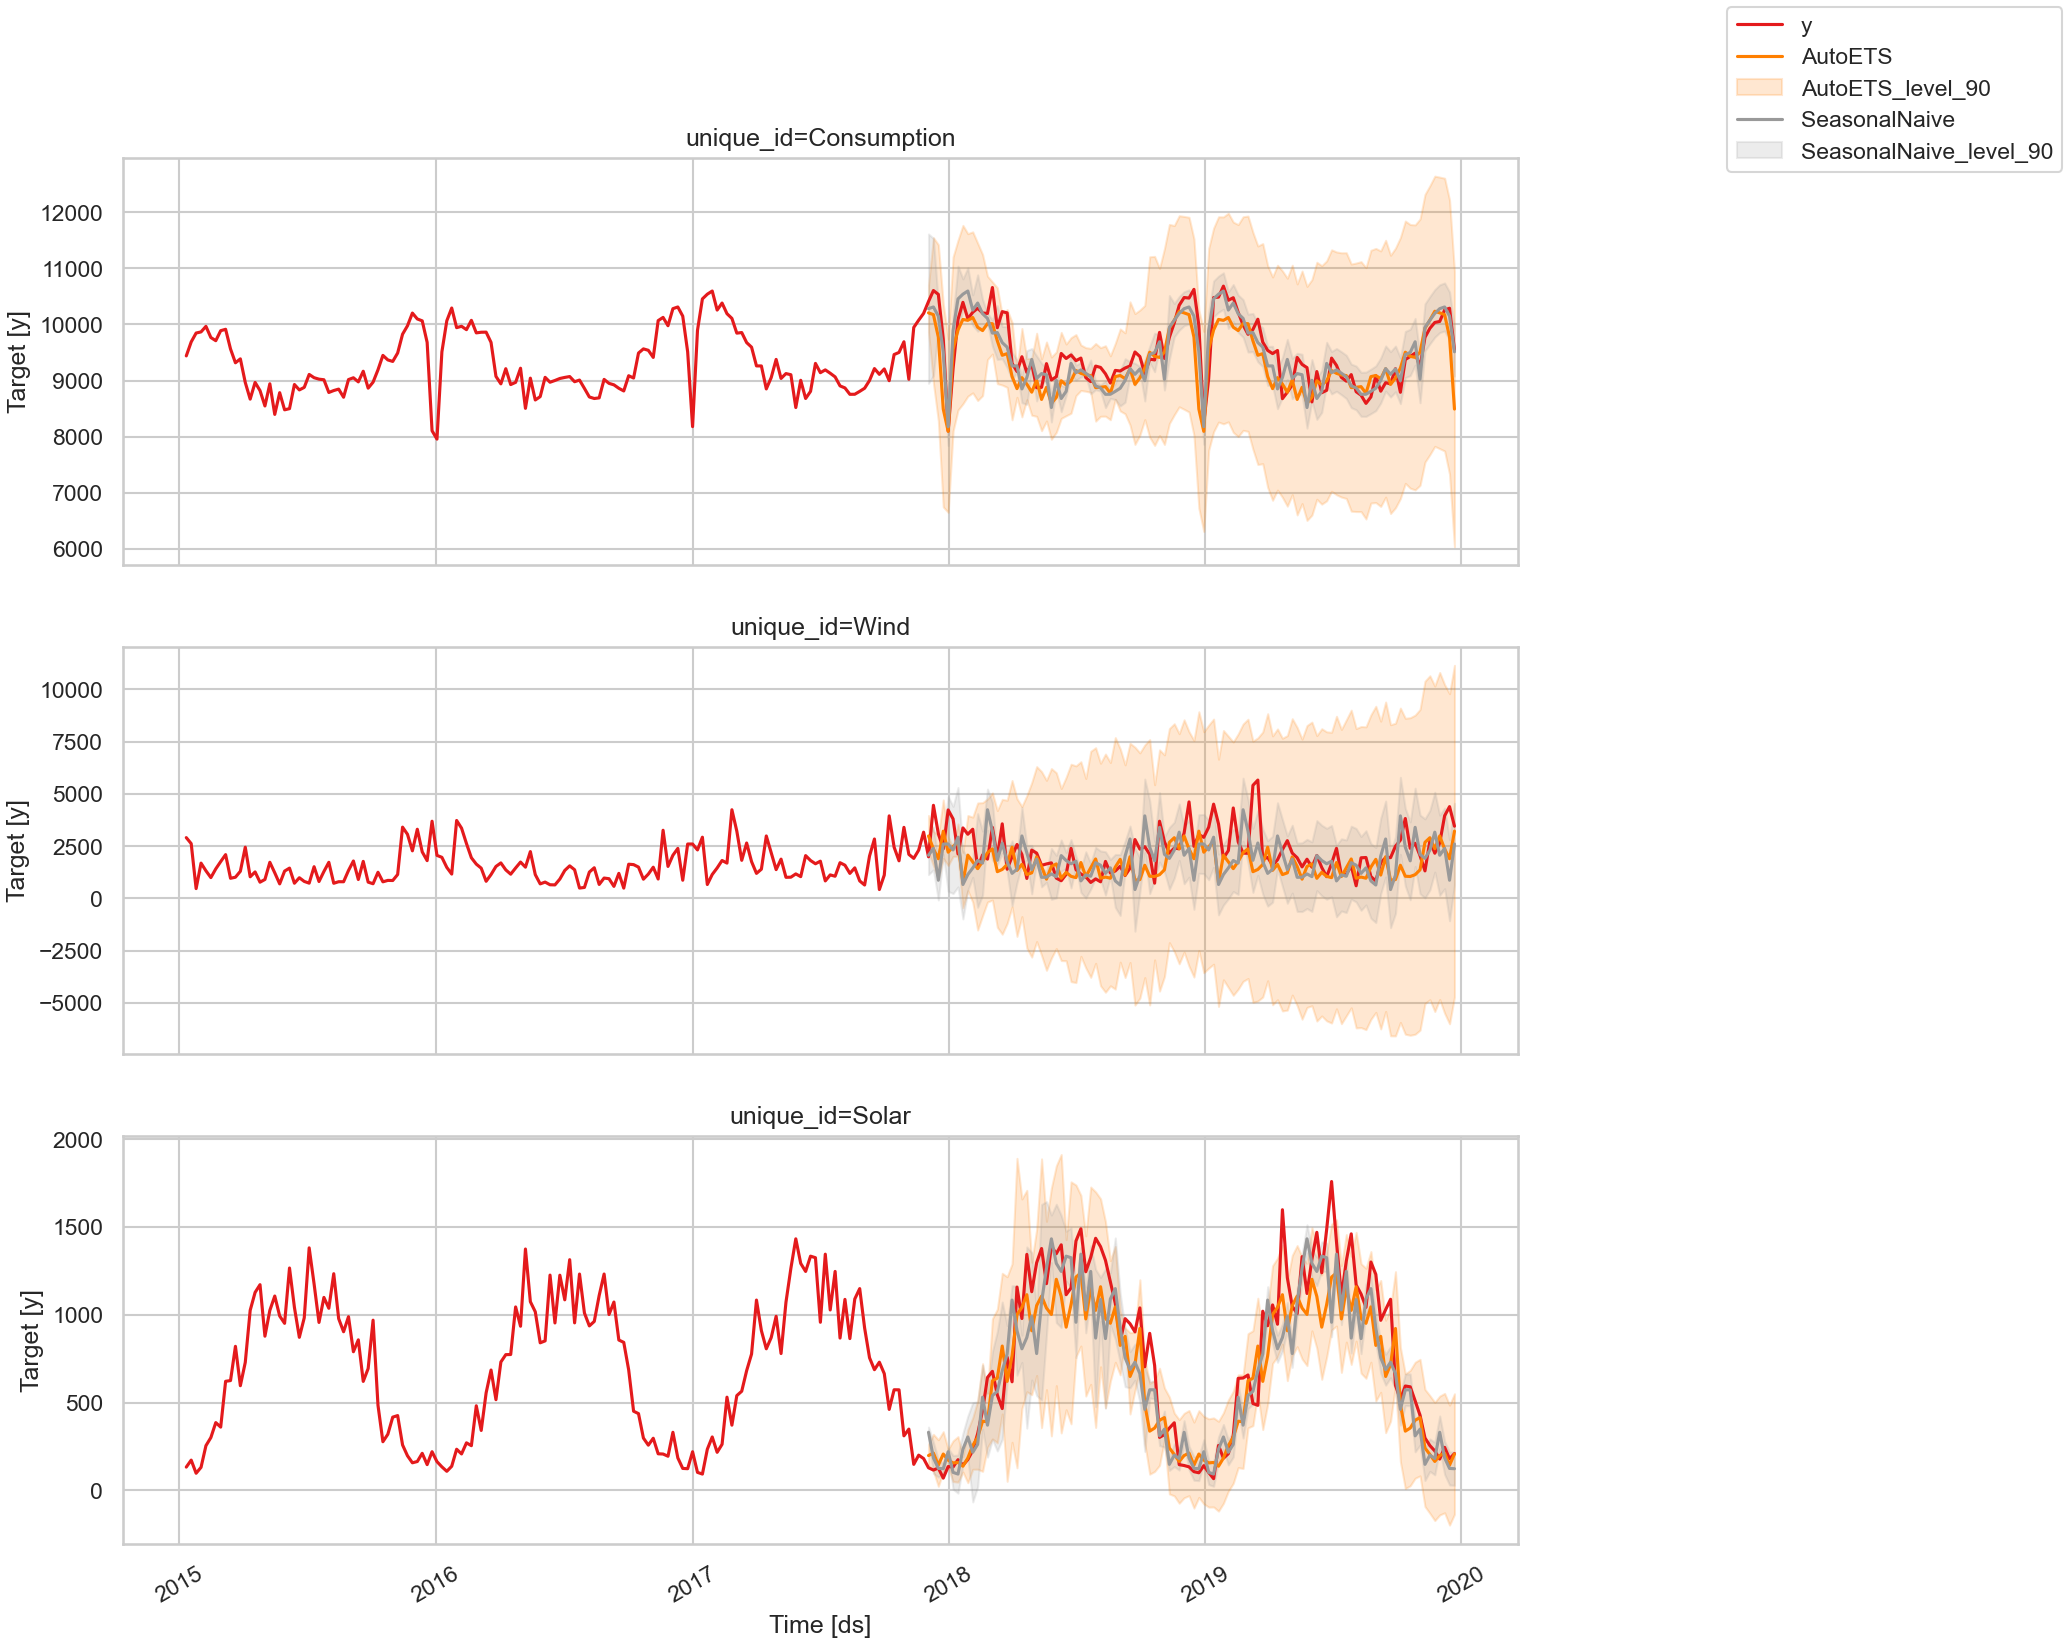

In [202]:
n_rows = eval_sf_conf['unique_id'].nunique()
fig, ax = plt.subplots(n_rows, 1, figsize=(12, 4*n_rows), sharex=True)
plot_series(
    df_train,
    forecasts_df=eval_sf_conf,
    level=[90],
    ax=ax,
    palette='Set1'
)

#### bootstrap-калибровка (беггинг)

Если распределние на калиборовном интервале не известно, можно сделать bootstrap-based калибровку (беггинг) для экстраполяции ВР:
- Берём калибровочный горизонт h.
- Генерируем N бутстрэп-выборок из остатков на этом горизонте.
- Для каждой выборки считаем верхнюю квантиль ошибки (или половину ширины интервала).
- Берём среднее/квантиль этих квантильных значений и используем для построения прогнозных интервалов на весь горизонт.

In [203]:
import numpy as np

N_BOOT = 100
ALPHA = 0.1  # для 90% интервала

# Создаём копию точечного прогноза
forecasts_full = forecasts_point.copy()

# Добавляем колонки интервалов (если их нет)
for model in model_names:
    lo_col = f"{model}-lo-90"
    hi_col = f"{model}-hi-90"
    if lo_col not in forecasts_full.columns:
        forecasts_full[lo_col] = np.nan
        forecasts_full[hi_col] = np.nan

# Обрабатываем каждый ряд отдельно
for uid in forecasts_full['unique_id'].unique():
    mask_full = forecasts_full['unique_id'] == uid
    mask_calib = forecasts['unique_id'] == uid
    
    h_local = min(h, forecasts[mask_calib].shape[0])
    
    for model in model_names:
        lo_col = f"{model}-lo-90"
        hi_col = f"{model}-hi-90"
        if lo_col not in forecasts.columns:
            continue
        
        # ---  конформные интервалы на t <= h ---
        forecasts_full.loc[mask_full, model] = forecasts_point.loc[mask_full, model].values
        forecasts_full.loc[forecasts_full.loc[mask_full].index[:h_local], lo_col] = forecasts.loc[mask_calib, lo_col].values[:h_local]
        forecasts_full.loc[forecasts_full.loc[mask_full].index[:h_local], hi_col] = forecasts.loc[mask_calib, hi_col].values[:h_local]
        
        # ---  бутстрэп для t > h ---
        if FH > h_local:
            widths = (forecasts.loc[mask_calib, hi_col] - forecasts.loc[mask_calib, lo_col]).values / 2
            boot_qs = []
            for _ in range(N_BOOT):
                sample = np.random.choice(widths, size=widths.shape[0], replace=True)
                boot_qs.append(np.quantile(sample, 1 - ALPHA))
            q_boot = np.mean(boot_qs)
            
            # Масштабирование с sqrt(t/h)
            t_future = np.arange(h_local + 1, FH + 1)
            scaling = np.sqrt(t_future / h_local)
            half_width = q_boot * scaling
            
            point_future = forecasts_full.loc[mask_full, model].iloc[h_local:].values
            idx_future = forecasts_full.loc[mask_full].index[h_local:]
            
            forecasts_full.loc[idx_future, lo_col] = point_future - half_width
            forecasts_full.loc[idx_future, hi_col] = point_future + half_width


In [204]:
eval_sf_conf = df_test.merge(forecasts_full, on=['unique_id', 'ds'])

metrics = [coverage, scaled_crps]

metrics_eval = evaluate(
    df=eval_sf_conf,
    metrics=metrics,
    train_df=df_train,
    level=[90],
    id_col='unique_id',
    time_col='ds',
    target_col='y'
)

pivot_cov_crps = metrics_eval.pivot_table(
    index=['unique_id', 'metric'],
    values=['AutoETS', 'SeasonalNaive']
)
pivot_cov_crps

AutoETS  SeasonalNaive
unique_id   metric                                   
Consumption coverage_level90  0.990741       0.750000
            scaled_crps       0.015983       0.010670
Solar       coverage_level90  0.925926       0.750000
            scaled_crps       0.085612       0.088977
Wind        coverage_level90  0.944444       0.740741
            scaled_crps       0.267145       0.147770

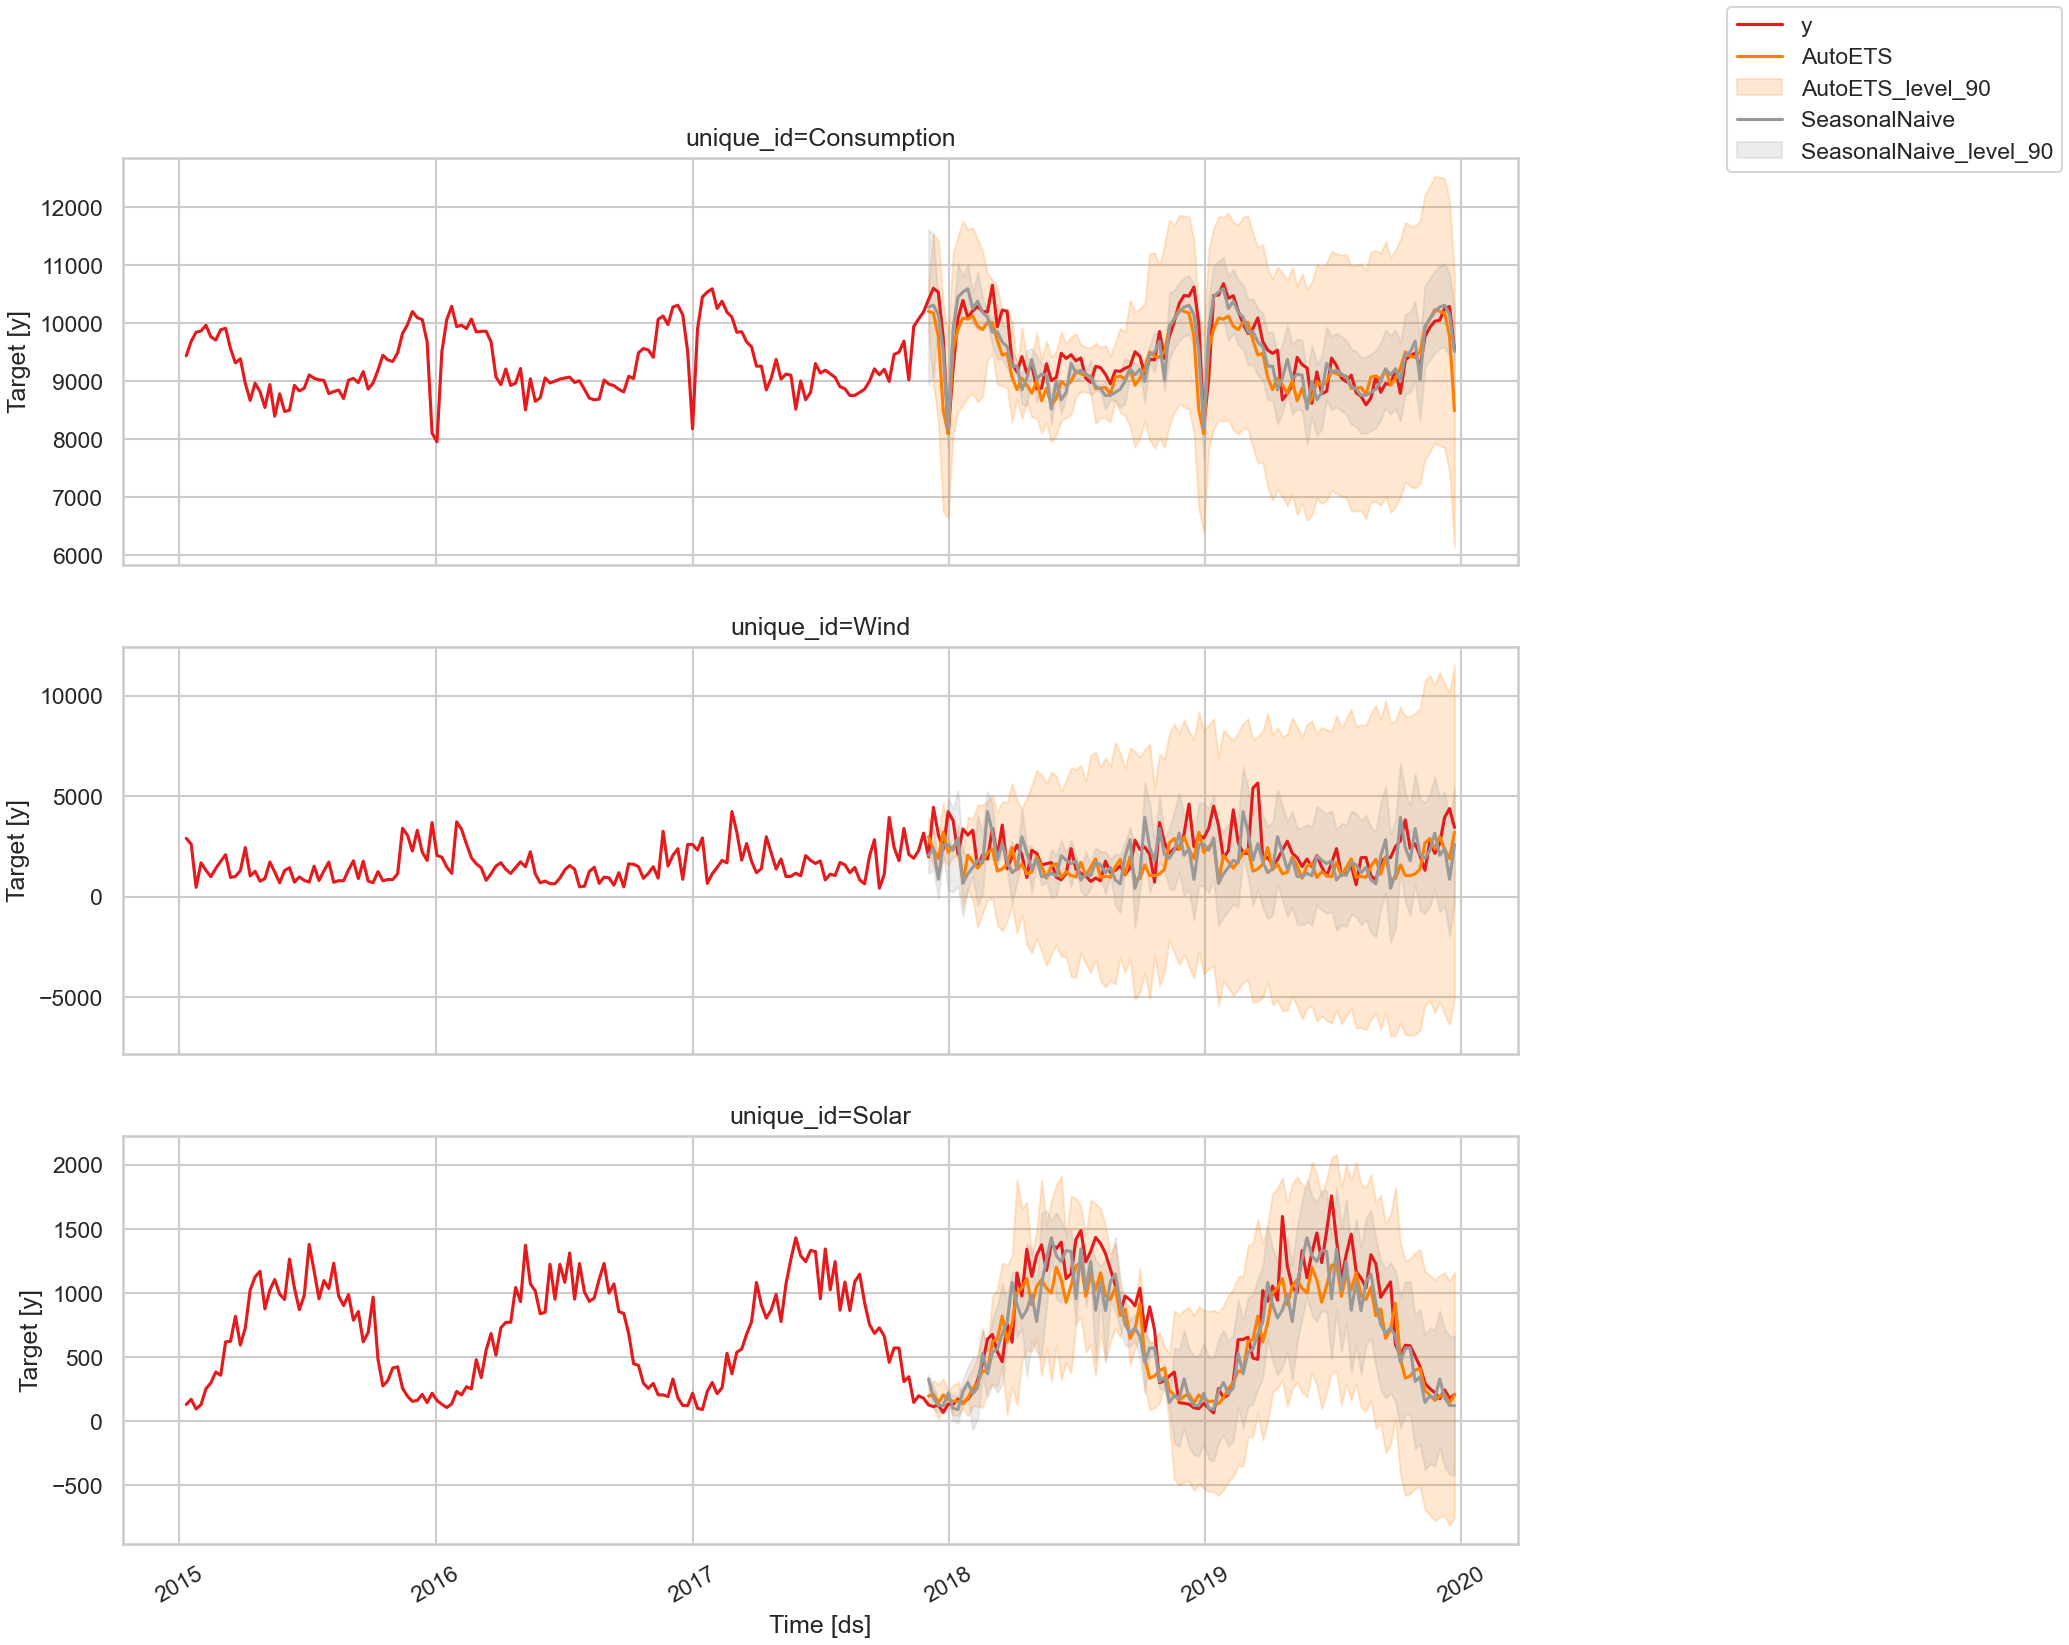

In [205]:
n_rows = eval_sf_conf['unique_id'].nunique()
fig, ax = plt.subplots(n_rows, 1, figsize=(12, 4*n_rows), sharex=True)
plot_series(
    df_train,
    forecasts_df=eval_sf_conf,
    level=[90],
    ax=ax,
    palette='Set1'
)

#### Упражнение:
1. Сравнить метрики предсказания ВР без калибровки и с калибровкой

### Калибровка вероятностного интервала
Для оценки интервальных прогнозов в соотвествующих моделях достаточно в прогнозе указать параметр уровня (например 50%) по которому необходимо значение. Однако, как уже было сказано, такие значения могут не точно покрывать реальные вероятности появления будущих значений. То есть фактическое покрытие (доля случаев, когда истинное значение попадает в интервал) может существенно отличаться от заявленного уровня. Например, номинальный 95%-ный интервал может покрывать реальные значения лишь в 70–85% случаев.


Для приведения уровней к реальным значениям используют ряд приемов, наиболее популярными из которых являются т.н. комформные интервалы и беггинг интервалов. 

Nixtla предоставляет инструментарий для комформной оценки интервалов. Важно отметить, что в некоторых версиях экосистемы вероятностный прогноз вообще не может быть выполнен без предварительной калибровки интервалов.

Комформная оценка интервалов строится путем калибровки значений на валидационной подвыборке (калибровочной подвыборке). Комформное преобрзование осуществляется следующим образодм:

1. Разбиение выборки на тренировочную и калибровочную подвыборки
2. Построение точечного прогноза на калибровочной подвыборке
3. Расчет невязки прогноза на калибровочной подвырбоке
4. Оценка разброса невязки по заданым уровням (квантилям)

В Nixtla [комформное преобразование выполнятся](https://nixtlaverse.nixtla.io/statsforecast/docs/tutorials/conformalprediction.html#how-conformal-prediction-works) со следующими модификациями:
1. Разбиение может происходить несколько раз путем скользящих окон.
2. Оценка неопределенности может быть асимитричной (отдельно оцениваются нижнии и отдельно верхнии квантили).


Отметим, что в отличии от иных методов оценки неопределенности, [комформное преобразование гарантирует, что предсказанный интервал покроет диапазон реальных значений при сохранении поведения модели](https://nixtlaverse.nixtla.io/statsforecast/docs/tutorials/conformalprediction.html#conformal-prediction-vs-traditional-methods).



In [30]:
from statsforecast.utils import ConformalIntervals
from statsforecast import StatsForecast


from statsforecast.models import (Naive, WindowAverage, HistoricAverage, 
                                    RandomWalkWithDrift, SeasonalWindowAverage, SeasonalNaive)

models=[
        AutoETS(season_length=SEASON),
        SeasonalWindowAverage(season_length=SEASON, window_size=SEASON),
        SeasonalNaive(season_length=SEASON)
]



sf = StatsForecast(
    models=models,
    freq=FREQ,
)

In [31]:
min_len = df_train.groupby('unique_id').size().min()   
n_windows = 2
h_calib = min(FH, min_len // 3)  # максимум 36
level=[75, 90, 95]
prediction_intervals = ConformalIntervals(h=h_calib, n_windows=n_windows)

forecasts = sf.forecast(
    df=df_train,
    h=h_calib, 
    level=level,
    prediction_intervals=prediction_intervals
)

In [32]:
eval = df_test.merge(forecasts, on=['unique_id', 'ds'])

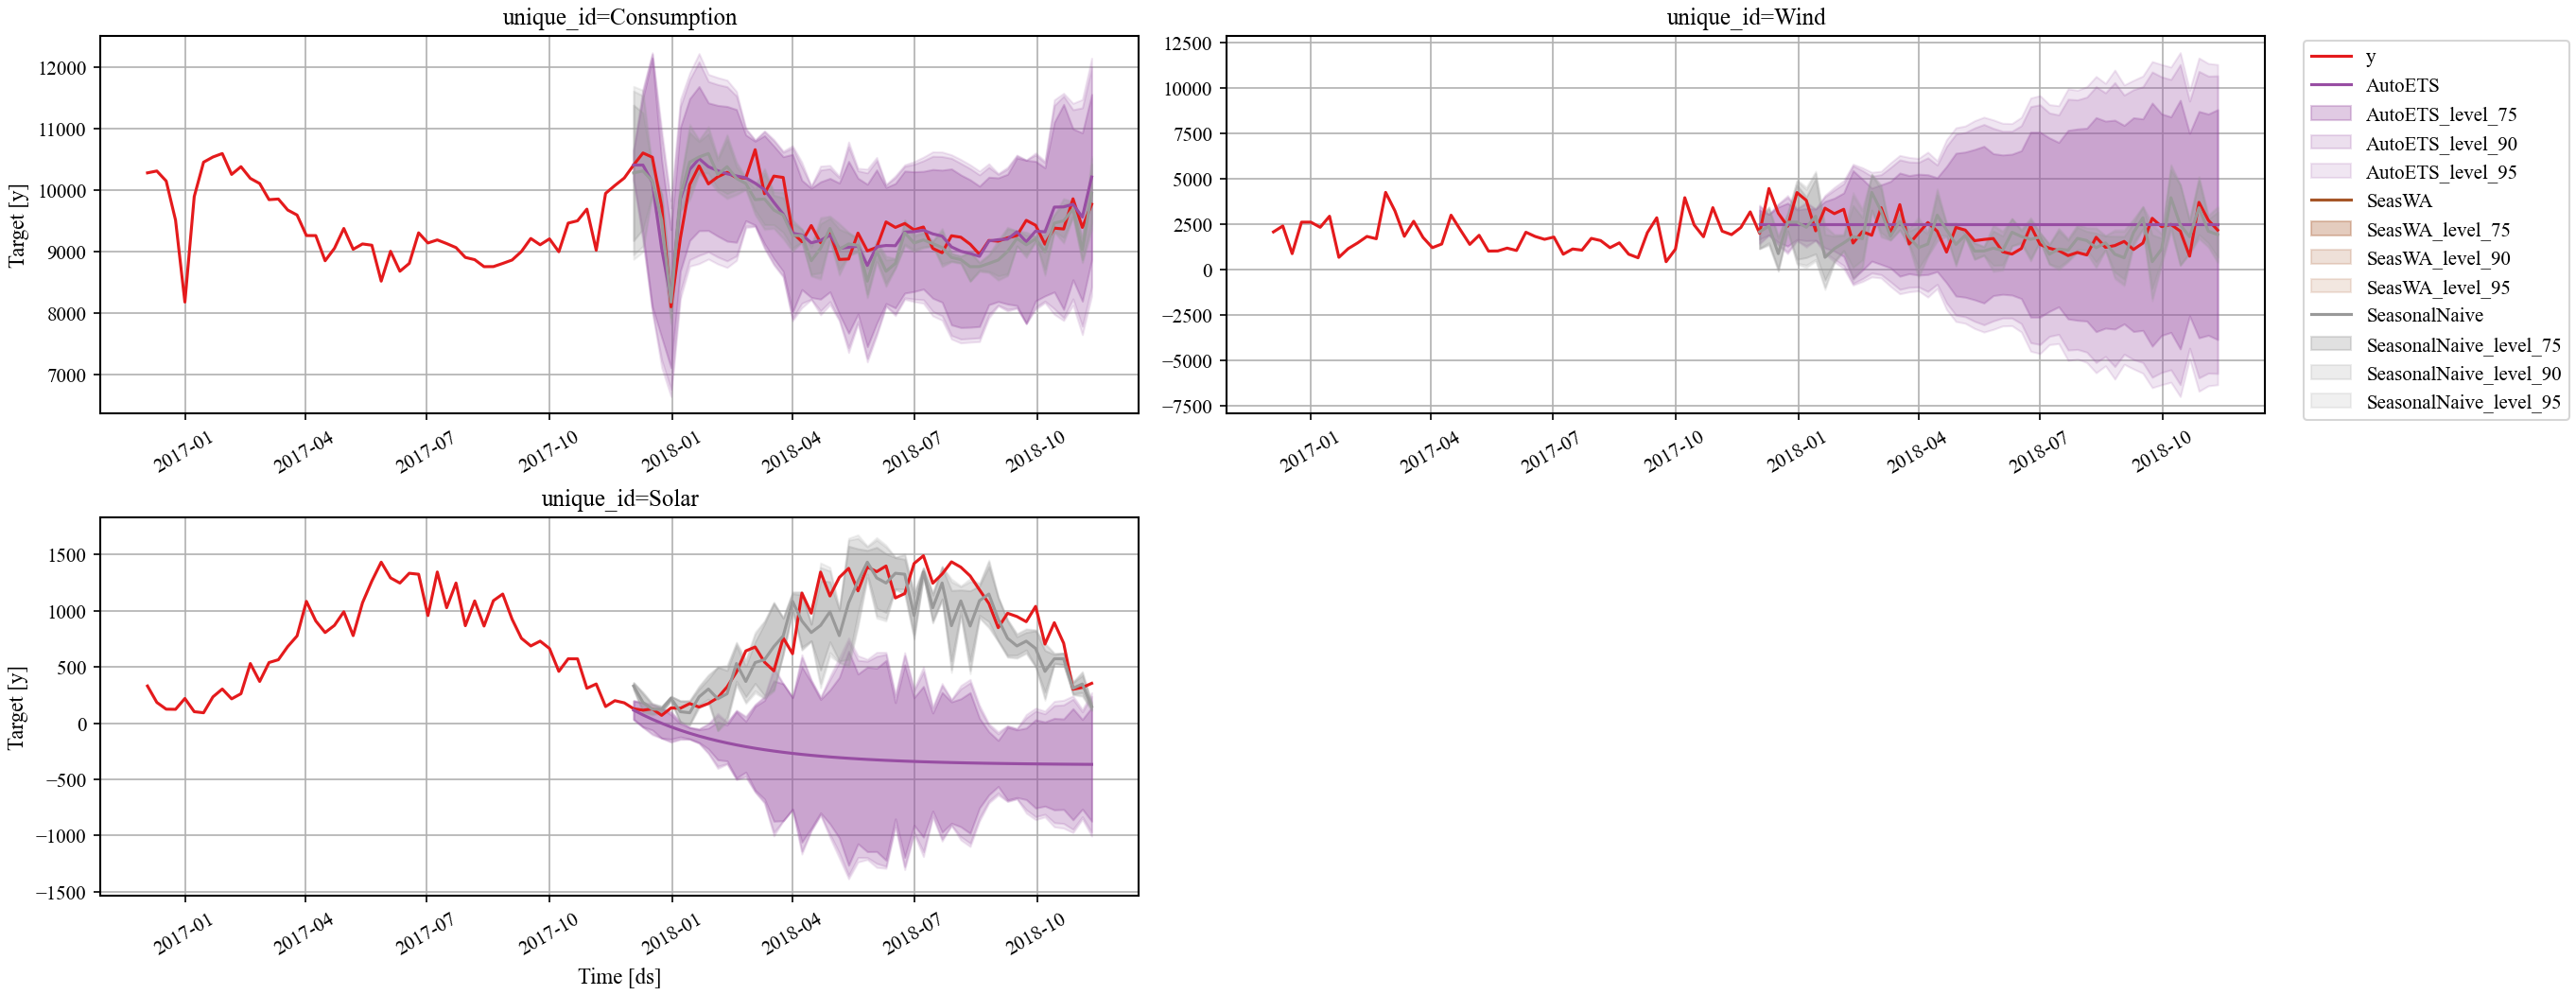

In [33]:
plot_series(df_train, 
            eval,
            max_insample_length=SEASON, 
            level=level,
            palette='Set1')

In [34]:
 
# sf_temp = StatsForecast(models=models, 
#                         freq=FREQ)
# pi_temp = ConformalIntervals(h=h_calib, n_windows=n_windows)
# fcst_temp = sf_temp.forecast(df=df_train, 
#                              h=h_calib, 
#                              level=level, 
#                              prediction_intervals=pi_temp)


# sf_point = StatsForecast(models=models, 
#                          freq=FREQ)
# point_fcst = sf_point.forecast(df=df_train, 
#                                h=FH)

# # Шаг 3: Вручную добавить интервалы, масштабируя по sqrt
# # (пример для одного уровня, например 90%)
# alpha = 1 - level[-1]
# q = np.quantile(conformity_scores, 1 - alpha/2)  # из fcst_temp

# # Масштабируем: ширина ~ sqrt(h)
# scaling_factor = np.sqrt(np.arange(1, FH + 1) / h_calib)
# half_width = q * scaling_factor

# point_fcst[f'lo-90'] = point_fcst['YourModel'] - half_width
# point_fcst[f'hi-90'] = point_fcst['YourModel'] + half_width

 Как уже было замечено вероятностное прогназирование часто используется для двух процедур:
* [процедура `backtest`](https://joaquinamatrodrigo.github.io/skforecast/0.8.1/user_guides/backtesting.html) в качестве допонительной меры отбора моделей и настройки их параметров.
* [допонительные метрики](https://auto.gluon.ai/stable/tutorials/timeseries/forecasting-metrics.html) оценки для будущих значений при настройки моделей. В том числе как мера оценки [интервала разброса значений оценки](https://otexts.com/fpp3/prediction-intervals.html). Такие метрики могут помочь и дополнить процедуру evaluation. Каждая из метрик будет иметь [свою интерпретацию](https://otexts.com/fpp3/distaccuracy.html).

Технически существует [множество способов](https://cienciadedatos.net/documentos/py42-forecasting-prediction-intervals-machine-learning.html) оценки интервалов прогнозирования. Способы можно разделить на специфические для моделей (например оценка дисперсии предсказывается в процессе оценки коэффициентов [<tt>ARIMA</tt>](https://otexts.com/fpp2/arima-forecasting.html#prediction-intervals-3) или [для наивных предсказаний](https://otexts.com/fpp2/prediction-intervals.html#benchmark-methods)) и т.н. независимые от модели способы. Важно понимать что большинство способов требуют, чтобы остатки (ошибки) модели следовали [нормальному распределению](https://otexts.com/fpp3/prediction-intervals.html). 
Когда это свойство не предполагается, обычно используются несколько альтернатив: 
* Интервалы прогнозирования на основе бутстрепных остатков и [рекурсивно-многошагового прогноза](https://skforecast.org/0.5.0/user_guides/autoregresive-forecaster.html).
<img src="https://skforecast.org/0.5.0/img/diagram-recursive-mutistep-forecasting.png" alt="" style="width:500px;">
* Интервалы прогнозирования на основе квантильной регрессии и [прямого многошагового прогноза](https://skforecast.org/0.5.0/user_guides/direct-multi-step-forecasting.html).
<img src="https://skforecast.org/0.5.0/img/diagram-direct-multi-step-forecasting.png" alt="" style="width:500px;">
* Интервалы прогнозирование с использованием техники [bootstrap](https://skforecast.org/0.5.0/user_guides/prediction-intervals). При этом на каждой точке горизонта вычисляются значения нужных процентилей (квантилей).
<img src="https://skforecast.org/0.5.0/img/diagram-bootstrapping-prediction-intervals.png" style="width:500px;">
* С использованием квантильной регресии (оценка интервалов).
* Методы т.н. [конформного предсказация](https://algotrading101.com/learn/conformal-prediction-guide/). В методе предлагается задаться оценкой разрброса и определить число предсказаний, которые туда попадают.

>[Интересно также отметить](https://robjhyndman.com/hyndsight/narrow-pi/), что  почти все интервалы прогнозирования слишком узкие. Например, номинальные 95 %-ные интервалы могут обеспечивать охват только от 71 до 87 % возможных значений прогнозов. Это хорошо известное явление, которое возникает потому, что модель распределения не учитывают все источники неопределенности. В моделях прогнозирования существует как минимум четыре источника неопределенности:
> * случайный член ошибки
> * Оценки параметров
> * Выбор модели для исторических данных
> * Продолжение процесса генерирования исторических данных в будущем.
>
> При построении интервалов прогнозирования для моделей временных рядов обычно учитывается только первый из этих источников. Поэтому целесообразно использовать тестовые данные для проверки эмпирического покрытия интервала, а не полагаться только на ожидаемое значение.

<!-- Let us note that technuically there are multiple ways to estimate prediction intervals, most of which require that the residuals (errors) of the model follow a normal distribution. When this property cannot be assumed, two alternatives commonly used are 
* Prediction intervals based on bootstrapped residuals and [recursive-multi-step forecaster](https://skforecast.org/0.5.0/user_guides/autoregresive-forecaster.html).
* Prediction intervals based on quantile regression and [direct-multi-step forecaster](https://skforecast.org/0.5.0/user_guides/direct-multi-step-forecasting.html). https://cienciadedatos.net/documentos/py42-forecasting-prediction-intervals-machine-learning.html

Interesting to note that 
in real-world problems, almost all prediction intervals are too narrow. For example, nominal 95% intervals may only provide coverage between 71% and 87%. This is a well-known phenomenon and arises because they do not account for all sources of uncertainty. With forecasting models, there are at least four sources of uncertainty:
The random error term
The parameter estimates
The choice of model for the historical data
The continuation of the historical data generating process into the future
When producing prediction intervals for time series models, generally only the first of these sources is taken into account. Therefore, it is advisable to use test data to validate the empirical coverage of the interval and not only rely on the expected one.
https://robjhyndman.com/hyndsight/narrow-pi/-->

Одним из важных свойств вероятностного предсказания является возможность введения [дополнительных метрик](https://www.sktime.net/en/latest/examples/01b_forecasting_proba.html#overview---theory), позволяющих корректировать прогноз.

Мы ожидаем, что прогнозируемое `y` имеет форму, отличную от истинного `y`, поэтому метрики имеют вид

`metric(y_true: series, y_pred: proba_prediction) -> float`.

где `proba_prediction` - тип конкретного "типа вероятностного предсказания".

Помимо процедуры `backtesting` валидация моделей может быть проведена несколькими способами:
1. Путем оценки/исследования остатков модели для предсказания ей тренировочного/валидационного набора данных.
2. Путем оценки моделей при помощи информационных критериев. Этим методом можно пользоваться для параметрических методов. При этом используются мини-максные [информационные критерии](https://bookdown.org/mpfoley1973/time-series/regression.html), которые в том числе были рассмотрены в работе <tt>ARIMA</tt>. В общем случае критерии формулируются, например, как:
$$AIC = N \log\left(\frac{SSE}{N}\right) + 2(k + 2),$$
где $N$ - объем выборки, $SSE$ - сумма квадратов ошибок, $k$ - общее число параметров модели.
3. Путем оценки вероятностных метрик - то есть того в каком диапазоне значений модель допускает появления реальных значений.


Типичные реализации прогнозирования, которые мы рассматривали прежде [являются точечными](https://www.lokad.com/probabilistic-forecasting-definition/). То есть предсказывают одно значение для одного шага прогноза. Такое поведение модели явялется нормальным. Однако,  в ряде случаев помимо самого значения прогноза требуется знание каких то [статистческих характеристик прогноза](https://otexts.com/fpp3/prediction-intervals.html). В наиболее полном случае требуется знание распределения результатов прогноза для каждой точки. Такой прогноз [называется  вероятностным](https://www.lokad.com/tv/2022/3/2/probabilistic-forecasting-for-supply-chain/). 

Другими словами вероятностный прогноз содержит набор вероятностей, связанных со всеми возможными будущими исходами для каждой точки прогноза. В противовес этому точечный прогноз указывает на один конкретный исход в качестве "прогноза". 

Вероятностные прогнозы важны, когда неопределенность прогназирования значема и неустранима Факторы неопределнности прогноза почти всегда имеет место в сложных системах. Например, для цепочек поставок вероятностные прогнозы необходимы для принятия надежных решений в условиях неопределенности будущего. В частности, спрос и время выполнения заказа - два ключевых аспекта анализа цепочки поставок - лучше всего учитывать с помощью вероятностного прогнозирования. Вероятностная перспектива естественным образом способствует экономической приоритезации решений на основе их ожидаемой, но неопределенной отдачи. 

Важно отметить, что не все методы прогноза допускают вероятностное прогназирование. Более того для оценки точности вероятностного прогноза требуются специальные метрики, которые отличаются от детерминированных аналогов. А также для использования вероятностных прогнозов требуется специализированный инструментарий, отличающийся от детерминированных аналогов.

И так, [Вероятностное прогнозирование обобщает](https://www.lokad.com/probabilistic-forecasting-definition/) то, что известно о будущих событиях, или мнения о них. В отличие от прогнозов с одним значением (point forecast) (например, прогнозов о том, что максимальная температура в данном месте в данный день составит 23 градуса Цельсия или что результатом данного футбольного матча будет безголевая ничья), вероятностные прогнозы присваивают вероятность каждому из нескольких различных исходов, а полный набор вероятностей представляет собой вероятностный прогноз (Probabilistic Forecasting). Другими словами в таким прогнозе мы предсказываем интервал значений, ассоциирующийся с неопределенностью предсказания (prediction intervals, Интервал прогнозирования - это диапазон значений, которые прогноз может принимать с заданной вероятностью.
<!-- Probabilistic forecasting summarizes what is known about, or opinions about, future events. In contrast to single-valued forecasts (such as forecasting that the maximum temperature at a given site on a given day will be 23 degrees Celsius, or that the result in a given football match will be a no-score draw), probabilistic forecasts assign a probability to each of a number of different outcomes, and the complete set of probabilities represents a probability forecast. In other words, in such a prediction, we predict an interval of values associated with the prediction uncertainty 

 A prediction interval is a range of values that the forecast can take with a given probability.



В общем случае Результаты вероятностного прогнозирования [могут быть](https://www.sktime.net/en/latest/examples/01b_forecasting_proba.html): 
* интервалы - `predict_interval(fh=None, X=None, coverage=0.90)`
* квантили - `predict_quantiles(fh=None, X=None, alpha=[0.05, 0.95])`
* диспрсия - `predict_var(fh=None, X=None, cov=False)`
* распределение - `predict_proba(fh=None, X=None, marginal=True)`

Примечания:
* у разных прогнозистов разные возможности! Также метрики, оценка и настройка различаются по "типу прогноза".
* Вероятностный прогноз может меняться от типасоставных шагов Пример: бутстрап

Заметим, $95\%$-ный интервал прогноза должен содержать диапазон значений, включающий фактическое будущее значение с вероятностью $95\%$. Тогда Вероятностное прогнозирование нацелено на получение полного прогнозного распределения. Точечное прогнозирование, с другой стороны, обычно возвращает среднее значение, медиану или другую точечную меру указанного распределения. Однако в реальных сценариях лучше прогнозировать не только наиболее вероятный будущий результат, но и множество альтернативных исходов.


## Дополнительно про CV



In [209]:
def make_cv_splits(
    df, 
    h, 
    step_size, 
    train_window=None, 
    strategy='expanding',
    n_windows_per_train=1,
    test_step=None  # ← НОВЫЙ ПАРАМЕТР
):
    """
    Генерирует CV-окна.
    
    Новые параметры:
    - n_windows_per_train: сколько тестовых окон на каждую позицию обучения.
    - test_step: шаг между тестовыми окнами (в шагах временной шкалы).
                 Если None → равен h (тесты идут подряд без пропусков).
    """
    if test_step is None:
        test_step = h
    
    df = df.sort_values(['unique_id', 'ds'])
    all_splits = []
    
    for uid, group in df.groupby('unique_id'):
        dates = group['ds'].tolist()
        n = len(dates)
        
        if strategy == 'backtest':
            if train_window is None:
                raise ValueError("Для backtest нужен train_window")
            train_start_idx = 0
            train_end_idx = train_window - 1
            
            # Первая позиция теста
            base_test_start = train_end_idx + 1
            pos = base_test_start
            
            while pos + h - 1 < n:
                for w in range(n_windows_per_train):
                    test_start = pos + w * test_step
                    test_end = test_start + h - 1
                    if test_end >= n:
                        break
                    all_splits.append({
                        'unique_id': uid,
                        'train_start': dates[train_start_idx],
                        'train_end': dates[train_end_idx],
                        'test_start': dates[test_start],
                        'test_end': dates[test_end]
                    })
                # Сдвигаемся к следующей позиции обучения
                pos += step_size
                
        else:
            # expanding / sliding
            # Последняя возможная позиция cutoff'а
            last_possible = n - 1 - (n_windows_per_train - 1) * test_step - h
            if last_possible < 0:
                continue
                
            cutoff_positions = []
            pos = last_possible
            min_train_len = train_window if strategy == 'sliding' else 1
            
            while pos >= min_train_len - 1:
                cutoff_positions.append(pos)
                pos -= step_size
            cutoff_positions = sorted(cutoff_positions)
            
            for cutoff in cutoff_positions:
                if strategy == 'expanding':
                    train_start_idx = 0
                else:  # sliding
                    train_start_idx = max(0, cutoff - train_window + 1)
                
                for w in range(n_windows_per_train):
                    test_start = cutoff + 1 + w * test_step
                    test_end = test_start + h - 1
                    if test_end >= n:
                        break
                    all_splits.append({
                        'unique_id': uid,
                        'train_start': dates[train_start_idx],
                        'train_end': dates[cutoff],
                        'test_start': dates[test_start],
                        'test_end': dates[test_end]
                    })
    
    return pd.DataFrame(all_splits)

In [210]:
def plot_cv_splits(df, splits, unique_id, title="CV Splits"):
    """
    Визуализация CV-окон линиями.
    
    Параметры:
    - df: исходный DataFrame с ['ds', 'y']
    - splits: результат make_cv_splits
    - unique_id: строка
    - title: заголовок
    """
    series = df[df['unique_id'] == unique_id].sort_values('ds')
    windows = splits[splits['unique_id'] == unique_id]
    
    plt.figure(figsize=(10, 2 + len(windows) * 0.5))
    
    for i, (_, row) in enumerate(windows.iterrows()):
        y_level = i + 1
        
        # Обучение
        plt.plot([row['train_start'], row['train_end']], [y_level, y_level],
                 color='C0', linewidth=2, solid_capstyle='butt')
        # Тест
        plt.plot([row['test_start'], row['test_end']], [y_level, y_level],
                 color='C1', linestyle='--', linewidth=2, solid_capstyle='butt')
        # Граница
        plt.scatter([row['train_end']], [y_level], color='black', s=20, zorder=5)
    
    plt.yticks(range(1, len(windows) + 1), [f"Окно {i+1}" for i in range(len(windows))])
    plt.xlabel('Дата')
    plt.title(f"{title}: {unique_id}")
    plt.grid(True, axis='x', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

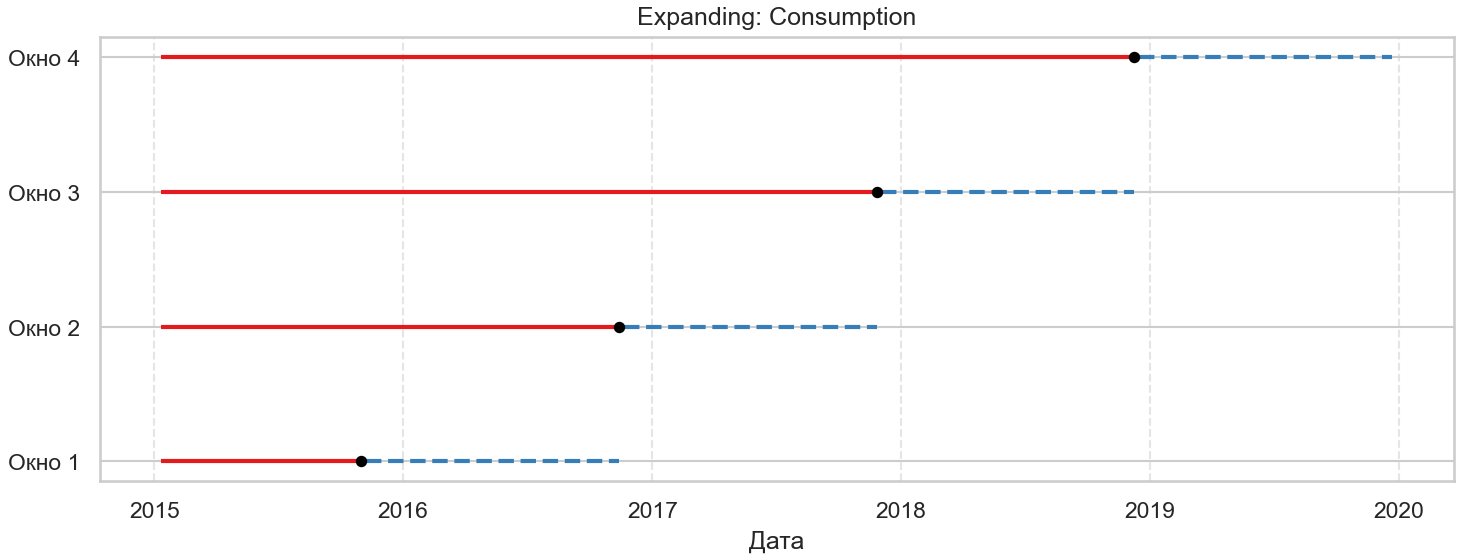

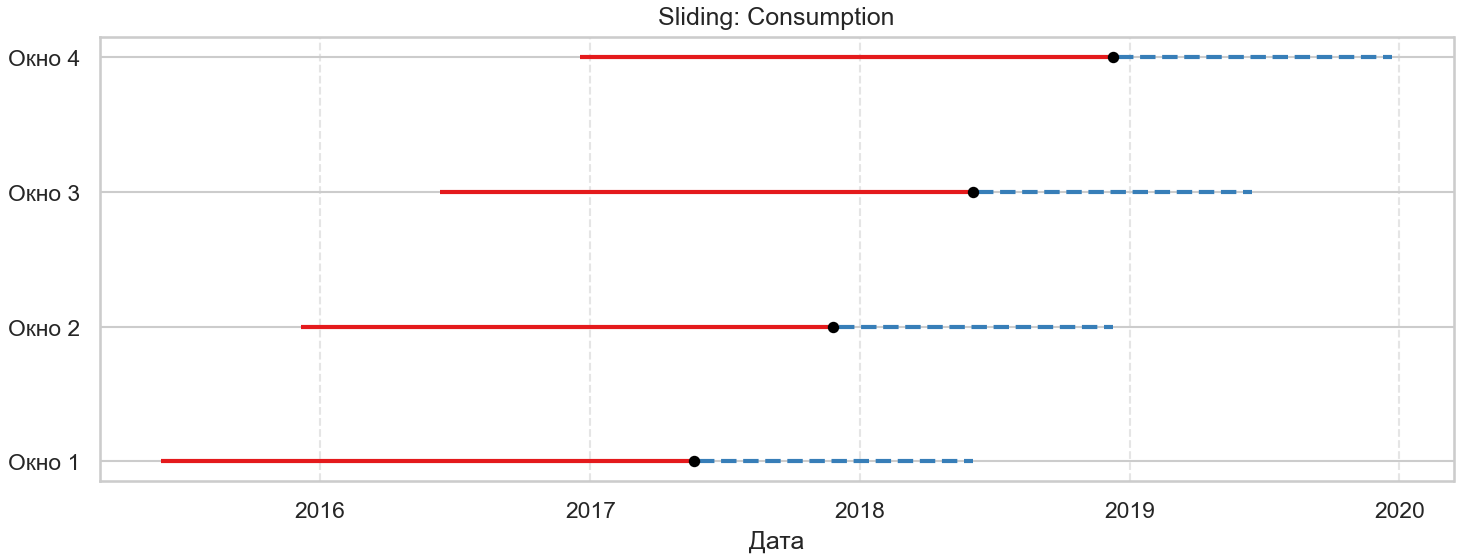

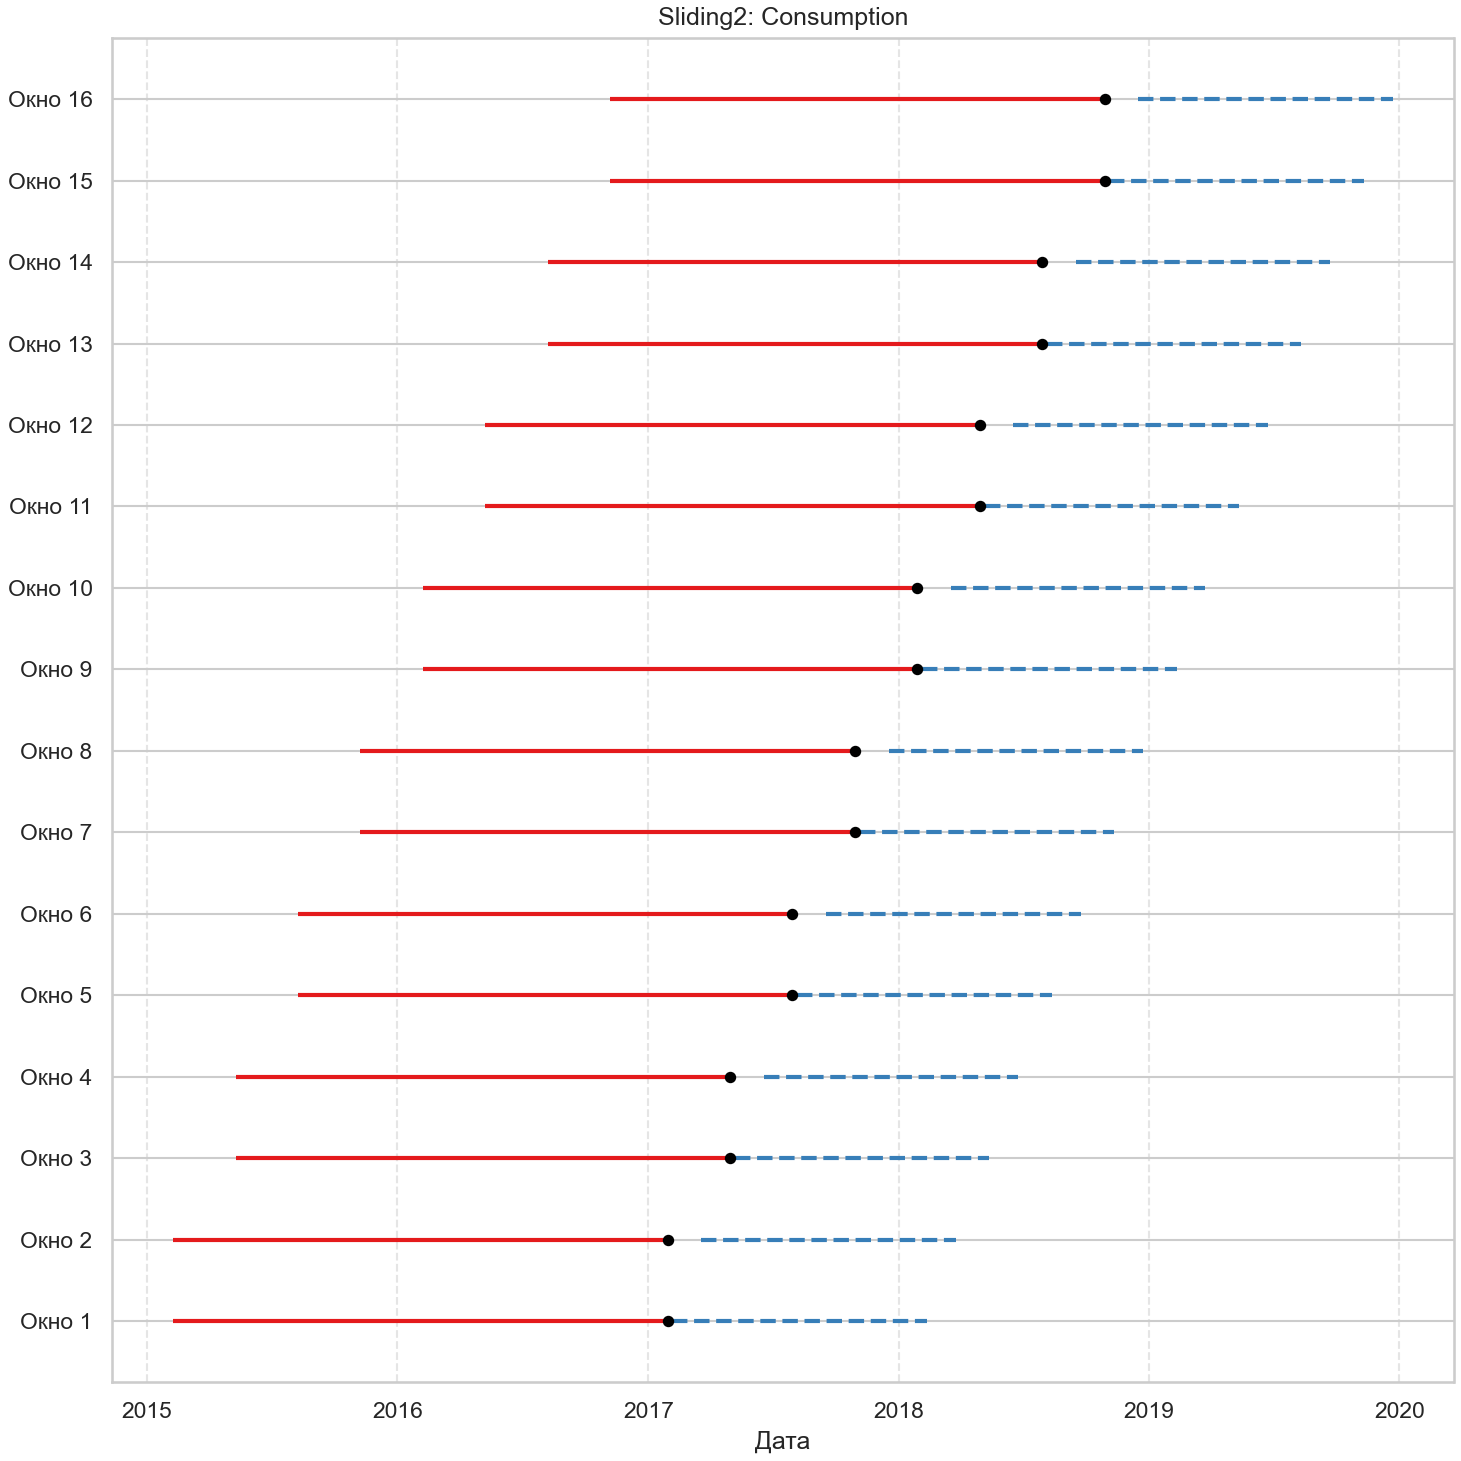

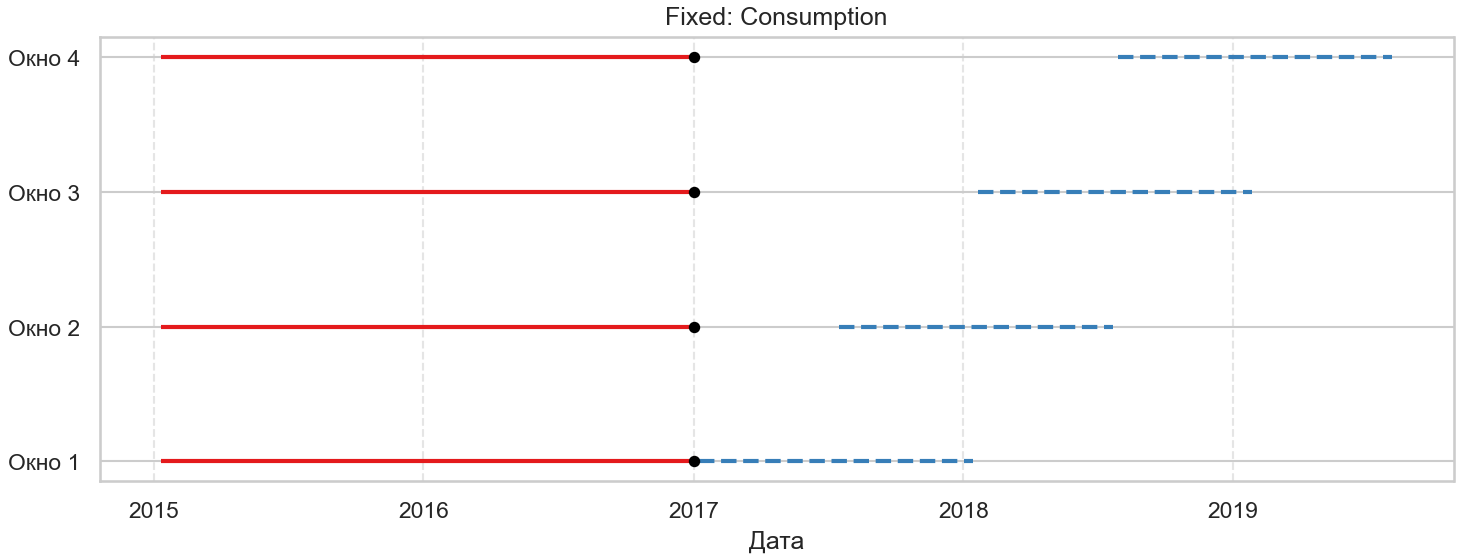

In [212]:
# Expanding
splits_exp = make_cv_splits(panel_df, h=FH//2, step_size=FH//2, strategy='expanding')
plot_cv_splits(panel_df, splits_exp, 'Consumption', 'Expanding')

# Sliding
splits_slid = make_cv_splits(panel_df, h=FH//2, step_size=FH//4, train_window=2*SEASON, strategy='sliding')
plot_cv_splits(panel_df, splits_slid, 'Consumption', 'Sliding')

# Sliding2
splits_slid2 = make_cv_splits(panel_df, h=FH//2, step_size=FH//8, train_window=2*SEASON, n_windows_per_train = 2, test_step = FH//16,  strategy='sliding')
plot_cv_splits(panel_df, splits_slid2, 'Consumption', 'Sliding2')

# Fixed (backtesting)
splits_fixed = make_cv_splits(panel_df,  h=FH//2, step_size=FH//4, train_window=2*SEASON, strategy='backtest')
plot_cv_splits(panel_df, splits_fixed, 'Consumption', 'Fixed')

In [213]:
from utilsforecast.evaluation import evaluate

In [214]:
def cv_evaluation_with_forecasts(
    df, 
    splits, 
    models, 
    model_names,
    metrics,
    refit=True,
    freq=FREQ
):
    all_evals = []
    all_forecasts = []  # ← НОВОЕ
    sf_cache = {}
    
    grouped = splits.groupby(['unique_id', 'train_start', 'train_end'])
    
    for (uid, train_start, train_end), group in grouped:
        test_rows = []
        test_info = []  # чтобы знать, откуда какие даты
        for _, row in group.iterrows():
            mask = (
                (df['unique_id'] == uid) &
                (df['ds'] >= row['test_start']) &
                (df['ds'] <= row['test_end'])
            )
            subset = df[mask]
            test_rows.append(subset)
            test_info.append(row)
        
        if not test_rows:
            continue
            
        test = pd.concat(test_rows).sort_values('ds').reset_index(drop=True)
        train = df[
            (df['unique_id'] == uid) &
            (df['ds'] >= train_start) &
            (df['ds'] <= train_end)
        ].copy()
        
        if len(train) == 0 or len(test) == 0:
            continue
        
        pred_cols = {'ds': test['ds'].values, 'unique_id': uid}
        for model, name in zip(models, model_names):
            cache_key = (name, uid, train_start, train_end)
            if refit or cache_key not in sf_cache:
                sf = StatsForecast(models=[model], freq=freq)
                sf.fit(train)
                if not refit:
                    sf_cache[cache_key] = sf
            else:
                sf = sf_cache[cache_key]
            
            h = len(test)
            pred = sf.predict(h=h)
            pred_cols[name] = pred[name].values[:h]
        
        # Сохраняем прогнозы
        forecast_df = pd.DataFrame(pred_cols)
        forecast_df['train_start'] = train_start
        forecast_df['train_end'] = train_end
        all_forecasts.append(forecast_df)
        
        # Оценка
        eval_df = test[['unique_id', 'ds', 'y']].copy()
        for name in model_names:
            eval_df[name] = pred_cols[name]
        
        eval_result = evaluate(df=eval_df, metrics=metrics, train_df=train)
        eval_result['train_start'] = train_start
        eval_result['train_end'] = train_end
        eval_result['test_start'] = test['ds'].min()
        eval_result['test_end'] = test['ds'].max()
        all_evals.append(eval_result)
    
    return pd.concat(all_evals, ignore_index=True), pd.concat(all_forecasts, ignore_index=True)

In [247]:
results = cv_evaluation_with_forecasts(
    df=panel_df,
    splits=splits_slid2,
    models=models,
    model_names=model_names,
    metrics=metrics,
    refit=True
)

# Сводка
summary = results.groupby(['metric','unique_id'])[model_names].agg(['mean', 'std'])
summary.round(4)

KeyError: 'SeasESOpt'